# 20. Reinforcement Learning for Portfolio Allocation

In this project we move from **forecasting assets** to **learning a portfolio policy**. The earlier ML work predicted future returns or regimes, then converted those forecasts into weights with hand-built rules. Here we let an agent choose the weights directly, observe what happens to the portfolio, and update the policy from the realized reward.

Main parts in this notebook:

- build a portfolio RL environment from weekly cross-asset decisions, previous weights, costs, volatility, drawdown, and market states,
- define a continuous action space that turns neural-network outputs into valid long-only portfolio weights,
- design a reward based on differential Sharpe with penalties for turnover, drawdown, volatility, concentration, excess cash, and redundant equal-weight behavior,
- teach the RL path from MDPs and Bellman equations to Q-learning, DQN, policy gradients, actor-critic, PPO, recurrent PPO, and SAC,
- train PPO, recurrent PPO, and SAC policies and compare them against the rule-based and ML portfolio models from earlier projects,
- repeat the workflow on sector ETFs through the library implementation.

The repeated material is intentionally kept short. Mean-variance and portfolio backtesting were already covered in [Project 2](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/02_portfolio_optimization_MV_models.html), Black-Litterman and learned confidence in [Project 6](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/06_portfolio_black_littreman.html), robust/tail portfolio models in [Project 10](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/10_portfolio_tail_parity_robust.html), macro financial conditions in [Project 12](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/12_financial_conditions_index.html), regime classification in [Project 16](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/16_regime_switching_portfolio.html), and neural forecasting plus Kelly sizing in [Project 19](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/19_forecasting_kelly_allocation.html). We use those pieces as inputs here. The new subject is **reinforcement learning as sequential portfolio control**.

For the RL theory, the main backbone follows the standard MDP/value-function/policy-gradient framing from Sutton and Barto's reinforcement learning text, plus the specific modern algorithms behind DQN, PPO, GAE, and SAC: [Sutton & Barto](https://web.stanford.edu/class/psych209/Readings/SuttonBartoIPRLBook2ndEd.pdf), [DQN](https://www.nature.com/articles/nature14236), [GAE](https://arxiv.org/abs/1506.02438), [PPO](https://arxiv.org/abs/1707.06347), and [SAC](https://arxiv.org/abs/1801.01290). We don't turn the notebook into a literature review, but those are the concepts the implementation is built on.

A good way to read this project is to treat it as the final step in the portfolio-learning chain. In the earlier ML notebooks, we mostly asked models to **predict something**: a regime label, a return rank, a volatility state, or a forward alpha. In this project, we ask a more difficult question: after seeing all those signals, **what should the portfolio actually do now?**

That change sounds small, but it changes the learning problem completely. A forecast model is usually trained with a fixed target. The target could be next-month return, next-month rank, or whether the next period is risk-on. The model predicts the target and we evaluate prediction error. A portfolio policy has a different job. It has to pick an action that changes wealth through time. The quality of that action depends on future return, turnover, drawdown, volatility, concentration, cash use, and the next opportunity set. This is why RL is a natural final project: it lets us write the portfolio decision as a repeated control problem instead of one isolated prediction problem.

We should still be careful with this. Finance is a difficult RL domain because the market doesn’t give us millions of independent training episodes. The agent sees one noisy historical path, and every apparent edge can be a sample artifact. So the goal here isn’t to claim that RL automatically beats everything. The goal is to build a serious, transparent RL allocation framework and understand exactly what the policies learn, what they fail to learn, and how they compare with the more interpretable rule-based models from the previous projects.


Because this is the final project, the markdown also has to do more teaching than a normal research note. The reader should understand the path from the simplest RL objects to the implemented models. So the explanations don't jump straight from “agent” to PPO or SAC. They build the bridge: state, action, reward, MDP, value, Q-value, advantage, policy gradient, actor-critic, PPO, recurrent PPO, and SAC. The portfolio details are then layered on top of that RL course path.

This is also why the markdown spends less space on repeated data and baseline explanations. The repeated pieces are only there to make the RL setup grounded. The main intellectual work is understanding how a neural policy learns sequential allocation under realistic portfolio frictions.


So this markdown treats RL as a decision framework first and a neural-network technique second. That order is important for understanding the project.
 Clearly.


## 1) Reused Inputs and the Portfolio-Control Setup

We start by importing the project dependencies, setting the random seeds, choosing the compute device, and defining the cross-asset universe. This first cell is mostly setup, so the important part is the **shape of the decision problem** rather than the imports.

The tradable risky assets are:

- **Equities:** SPY, QQQ, IWM, EFA, EEM
- **Real assets / inflation-sensitive assets:** VNQ, DBC, GLD
- **Rates and credit:** IEF, TLT, LQD, HYG
- **Cash-like defensive asset:** SHY

The signal-only assets AGG and UUP still help describe the market state, but they aren't part of the risky action vector. The agent receives features from these markets, then decides how much risk to take and how to distribute it across the portfolio.

The main data sources are repeated from earlier notebooks, so we only need the reproducibility links:

- Cross-asset ETF prices and volume: [data/core_cross_asset_etfs](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/core_cross_asset_etfs)
- US macro factors used inside the FCI feature block: [data/us_macro_factors](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/us_macro_factors)
- Chicago Fed NFCI data: [data/nfci](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/nfci)
- VIX data used as volatility-state information: [data/vix_data](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/vix_data)


### Imports and plotting settings


In [1]:
from __future__ import annotations

import json
import math
import os
import random
import time
import warnings
from pathlib import Path

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler

from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.dataio import load_macro_factors, load_nfci, load_yfinance_panel, prices_to_returns_panel
from quantfinlab.ml.features import (
    assemble_forecasting_table,
    build_asset_feature_block,
    build_cross_asset_feature_block,
    build_fci_feature_block,
    clean_feature_columns,
    regime_probability_features,
    trim_feature_table_by_availability,
)
from quantfinlab.ml.evaluation import walkforward_tabular_predictions
from quantfinlab.ml.sequence_models import TcnForecast, torch_predictions, train_torch_model
from quantfinlab.plotting.curves import set_plot_style
from quantfinlab.plotting.portfolio import (
    active_return_curve,
    concentration_path,
    forecast_policy_sensitivity,
    plot_rolling_sharpe,
    plot_strategy_drawdowns,
    plot_strategy_nav,
    policy_exposure_path,
    policy_weight_area,
    regime_exposure_boxplot,
    turnover_cost_curve,
)
from quantfinlab.portfolio import black_litterman as bl
from quantfinlab.portfolio import covariance, expected_returns, optimizers, views as bl_views
from quantfinlab.portfolio.cvar import mean_cvar_weight_frame
from quantfinlab.portfolio.selection import build_strategy_summary
from quantfinlab.portfolio.sizing import forecast_gated_maxsharpe_weight_frame, forecast_kelly_weight_frame
from quantfinlab.portfolio.universe import make_rebalance_dates
from quantfinlab.reports.risk_report import risk_report

warnings.filterwarnings("ignore")
set_plot_style()

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

repo_root = Path.cwd()
if not (repo_root / "data" / "core_cross_asset_etfs.csv").exists():
    repo_root = repo_root.parent
data_path = repo_root / "data" / "core_cross_asset_etfs.csv"
model_dir = repo_root / "models" / "project20_main_strong"
model_dir.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rf_annual = 0.04
rf_daily = (1.0 + rf_annual) ** (1.0 / 252.0) - 1.0
annualization = 252.0
cost_bps = 10.0
freq = "W-FRI"

assets = ["SPY", "QQQ", "IWM", "EFA", "EEM", "VNQ", "DBC", "GLD", "IEF", "TLT", "LQD", "HYG"]
cash_ticker = "SHY"
benchmark_ticker = "SPY"
signal_only_assets = ["AGG", "UUP"]
all_tickers = list(dict.fromkeys(assets + [cash_ticker, benchmark_ticker] + signal_only_assets))

tcn_epochs = 180
ppo_epochs_main = 180
rppo_epochs_main = 220
sac_epochs_main = 180

print({"device": str(device)})


{'device': 'cuda'}


The first printed output reports the compute device. Here the run used `cuda`, so the neural-network training was done on GPU. That matters because PPO, recurrent PPO, and SAC all repeatedly collect rollouts and update neural networks. A CPU version would still work, but the training loop would be slower.

The portfolio universe also makes the RL task meaningful. If the universe only contained highly correlated equity ETFs, the action space would mostly be sector rotation. Here the agent can rotate between broad equity, growth, small caps, international equity, emerging markets, real estate, commodities, gold, duration, credit, high yield, and cash. That means one action can represent several economic choices at the same time:

- **risk exposure:** high risky allocation versus more SHY,
- **growth/cyclical tilt:** QQQ and SPY versus IWM, EEM, HYG, and DBC,
- **inflation hedge:** GLD and DBC versus duration,
- **rate sensitivity:** TLT and IEF versus SHY,
- **credit beta:** HYG and LQD versus Treasury exposure,
- **international risk:** EFA and EEM versus US assets.

The RL policy therefore isn't just choosing tickers. It is choosing a macro allocation shape. This is why the state contains both asset-level signals and global context. A high forecast for HYG means something different when NFCI is loose, VIX is falling, breadth is strong, and SPY drawdown is shallow. The same HYG forecast is more dangerous when financial conditions are tightening and equity breadth is breaking.

The weekly decision frequency is also a design choice. Daily RL allocation would create too much noise and transaction cost. Monthly allocation may be too slow to react when the state changes sharply. Weekly decisions are a middle ground: the agent can adapt more often than the monthly optimizer, but the holding period is long enough that each action has a real portfolio consequence.


In [2]:
panels = load_yfinance_panel(
    data_path,
    fields=("close", "volume"),
    tickers=all_tickers,
    source="yfinance_export",
    start="2007-01-01",
)
close_all = panels["close"].sort_index().ffill(limit=3)
volume_all = panels["volume"].sort_index().ffill(limit=3).reindex(close_all.index)

first_valid = close_all[assets + [cash_ticker]].dropna(how="any").index.min()
close = close_all.loc[first_valid:, [c for c in all_tickers if c in close_all.columns]].ffill(limit=3)
volume = volume_all.reindex(index=close.index, columns=close.columns).ffill(limit=3)
r_d = prices_to_returns_panel(close, kind="simple").replace([np.inf, -np.inf], np.nan).fillna(0.0)

coverage = pd.DataFrame({
    "first_valid": close[assets + [cash_ticker]].apply(pd.Series.first_valid_index),
    "last_valid": close[assets + [cash_ticker]].apply(pd.Series.last_valid_index),
    "observations": close[assets + [cash_ticker]].notna().sum(),
    "coverage": close[assets + [cash_ticker]].notna().mean(),
})
display(coverage)
print(close.index.min().date(), "to", close.index.max().date(), close.shape)


,first_valid,last_valid,observations,coverage
SPY,2007-04-11,2026-06-17,4828,1.0
QQQ,2007-04-11,2026-06-17,4828,1.0
IWM,2007-04-11,2026-06-17,4828,1.0
EFA,2007-04-11,2026-06-17,4828,1.0
EEM,2007-04-11,2026-06-17,4828,1.0
VNQ,2007-04-11,2026-06-17,4828,1.0
DBC,2007-04-11,2026-06-17,4828,1.0
GLD,2007-04-11,2026-06-17,4828,1.0
IEF,2007-04-11,2026-06-17,4828,1.0
TLT,2007-04-11,2026-06-17,4828,1.0


2007-04-11 to 2026-06-17 (4828, 15)


In [3]:
eligible_index = pd.DatetimeIndex(close.index)[252:]
decision_dates = pd.DatetimeIndex(
    pd.Series(eligible_index, index=eligible_index).resample(freq).last().dropna()
).intersection(close.index)
monthly_dates = make_rebalance_dates(close.index, freq="ME", min_history_days=252)

daily_summary = pd.DataFrame({
    "daily_mean": r_d[assets].mean(),
    "daily_vol": r_d[assets].std(ddof=1),
    "ann_vol": r_d[assets].std(ddof=1) * np.sqrt(252.0),
    "ann_return": r_d[assets].mean() * 252.0,
})
display(daily_summary.round(4))
print("weekly decisions:", len(decision_dates), decision_dates.min().date(), decision_dates.max().date())
print("monthly optimizer dates:", len(monthly_dates), monthly_dates.min().date(), monthly_dates.max().date())


,daily_mean,daily_vol,ann_vol,ann_return
SPY,0.0005,0.0124,0.1973,0.1233
QQQ,0.0007,0.0140,0.2230,0.1788
IWM,0.0004,0.0156,0.2480,0.1114
EFA,0.0003,0.0137,0.2175,0.0690
EEM,0.0003,0.0176,0.2802,0.0881
VNQ,0.0004,0.0187,0.2968,0.0954
DBC,0.0001,0.0121,0.1925,0.0340
GLD,0.0004,0.0114,0.1809,0.1081
IEF,0.0001,0.0044,0.0697,0.0345
TLT,0.0002,0.0096,0.1516,0.0419


weekly decisions: 950 2008-04-11 2026-06-17
monthly optimizer dates: 219 2008-04-30 2026-06-17


The loaded cross-asset panel runs from **2007-04-11 to 2026-06-17** with 4,828 daily observations after alignment. All 13 investable assets in the main environment have full coverage over this aligned period. That is important for RL because missing data would break the state-action-transition sequence. A supervised forecasting model can sometimes drop a row or impute a missing feature; an RL environment needs every step to have a valid next state, action, reward, and next-period return.

The asset summary is also useful. QQQ has the strongest annualized return in the full panel, around **17.9%**, with annualized volatility around **22.3%**. SPY is lower return but also slightly lower volatility. IWM, EEM, and VNQ carry larger volatility. GLD has a strong standalone return with lower volatility than most equity ETFs. DBC has the weakest return in this window, which reminds us that commodities can be useful in specific regimes without being attractive as a permanent high-weight allocation.

We rebalance the RL policy weekly, using Friday decisions. The output reports **950 weekly decision points**, starting in April 2008 and ending in June 2026. Monthly optimizer dates are also created because the earlier portfolio models, like forecast-gated MaxSharpe and Kelly, use monthly timing. RL doesn't have to follow the monthly optimizer schedule; it can learn at a more frequent weekly control horizon while still being compared against slower rule-based strategies.


### 1.1 Forecasts, regimes, and portfolio priors as inputs

The next long cell builds the forecasting and rule-based inputs that the RL state will later consume. We don't need to re-teach the forecasting models from [Project 19](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/19_forecasting_kelly_allocation.html) or the regime classifier from [Project 16](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/16_regime_switching_portfolio.html). The important point is how we reuse them.

The project builds a forecast table with:

- **forward 21-day alpha targets**, measured relative to the cross-sectional median,
- **volatility-scaled return labels**, so assets with different risk levels can be compared more fairly,
- **tree-based forecasts** from a RandomForest-style model,
- **TCN rank forecasts** from the sequence model developed earlier,
- **confidence and rank features**, so the RL policy can see not only the direction of a forecast but also how strong and stable it appears,
- **regime probabilities**, FCI variables, VIX features, and cross-asset conditions.


In [4]:
macro_path = repo_root / "data" / "us_macro_factors.csv"
nfci_path = repo_root / "data" / "nfci.csv"
macro_factors = load_macro_factors(macro_path, start="1990-01-01") if macro_path.exists() else pd.DataFrame()
nfci = load_nfci(nfci_path) if nfci_path.exists() else pd.DataFrame()

vix_path = repo_root / "data" / "vix_data.csv"
if vix_path.exists():
    vix_raw = pd.read_csv(vix_path)
    vix_raw["Date"] = pd.to_datetime(vix_raw["Date"], errors="coerce")
    vix_level = pd.to_numeric(vix_raw.dropna(subset=["Date"]).set_index("Date")["VIX"], errors="coerce").sort_index()
    vix_level = vix_level[~vix_level.index.duplicated(keep="last")].reindex(vix_level.index.union(close.index)).ffill().reindex(close.index)
    vix_z_20 = ((vix_level - vix_level.rolling(20, min_periods=10).mean()) / vix_level.rolling(20, min_periods=10).std(ddof=1)).clip(-4.0, 4.0)
    vix_ma_ratio_63 = (vix_level / vix_level.rolling(63, min_periods=21).mean().replace(0.0, np.nan)).clip(0.25, 4.0)
    vix_pct_252 = vix_level.rolling(252, min_periods=63).rank(pct=True)
    vix_x = pd.DataFrame({"vix_z_20": vix_z_20, "vix_ma_ratio_63": vix_ma_ratio_63, "vix_pct_252": vix_pct_252}).replace([np.inf, -np.inf], np.nan).fillna(0.0)
else:
    vix_x = pd.DataFrame(index=close.index)

def build_main_forecast_features(
    close,
    volume,
    returns,
    assets,
    rebalance_dates,
    *,
    cache_dir,
    force=False,
):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / "main_forecast_features_project19_v3.pkl"
    model_path = cache_dir / "tcnrank_project19_v3.pt"
    if cache_path.exists() and not force:
        cached = pd.read_pickle(cache_path)
        required = {
            "date",
            "asset",
            "sigma_21",
            "z_rf",
            "z_rf_active",
            "z_rf_rank",
            "z_tcn",
            "z_tcn_rank",
            "tcn_rank",
            "tcn_confidence",
        }
        if required.issubset(cached.columns):
            return cached

    horizon = 21
    train_end = pd.Timestamp("2018-12-31")
    validation_start = pd.Timestamp("2017-01-01")
    train_label_cutoff = train_end - pd.tseries.offsets.BDay(horizon)
    validation_end = train_label_cutoff

    r_log = np.log(close[assets] / close[assets].shift(1))
    fwd = np.log(close[assets].shift(-horizon) / close[assets])
    sigma_21 = r_log.rolling(63, min_periods=63).std(ddof=1) * np.sqrt(horizon)
    z_21 = (fwd - horizon * np.log1p(rf_daily)).div(sigma_21.replace(0.0, np.nan)).clip(-4.0, 4.0)
    y_alpha = z_21.sub(z_21.median(axis=1), axis=0).clip(-4.0, 4.0)
    target = (
        pd.concat({"sigma_21": sigma_21, "z_21": z_21, "y_alpha": y_alpha}, axis=1)
        .stack(level=1)
        .rename_axis(["date", "asset"])
        .reset_index()
        .dropna()
    )
    counts = target.groupby("date")["asset"].nunique()
    target = target[target["date"].isin(counts[counts.eq(len(assets))].index)].copy()
    last_label_date = pd.Timestamp(target["date"].max())
    model_rebalance_dates = pd.DatetimeIndex([d for d in rebalance_dates if d <= last_label_date])

    asset_features = build_asset_feature_block(close, volume, returns, assets=assets, rf_daily=rf_daily)
    cross_features = build_cross_asset_feature_block(close, returns, assets=assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker)
    fci_features = build_fci_feature_block(macro_factors, nfci, index=close.index)
    regime_features = regime_probability_features(
        close,
        returns,
        assets=assets,
        cash_ticker=cash_ticker,
        benchmark_ticker=benchmark_ticker,
        model="LogisticRegression",
        horizon=21,
        rebalance_dates=model_rebalance_dates,
        output="features",
        n_jobs=4,
    )
    regime_features = regime_features.reindex(close.index.union(regime_features.index)).sort_index().ffill().reindex(close.index)
    data = assemble_forecasting_table(target, asset_features, cross_features, fci_features, regime_features)
    data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=["y_alpha", "z_21", "sigma_21"])
    data = data[data["asset"].isin(assets)].copy()
    full_dates = data.groupby("date")["asset"].nunique()
    data = data[data["date"].isin(full_dates[full_dates.eq(len(assets))].index)].copy()
    data = data.sort_values(["date", "asset"]).reset_index(drop=True)
    feature_cols = [c for c in data.columns if c not in {"date", "asset", "sigma_21", "z_21", "y_alpha"}]
    stage1 = clean_feature_columns(data, feature_cols, max_missing=0.30, max_abs_corr=0.985)
    data, first_model_date, availability = trim_feature_table_by_availability(
        data,
        stage1,
        target_cols=["y_alpha", "sigma_21"],
        min_feature_coverage=0.75,
        min_asset_count=len(assets),
        min_target_complete=1.0,
    )
    stage1 = clean_feature_columns(data, feature_cols, max_missing=0.30, max_abs_corr=0.985)
    for col in stage1:
        data[col] = data.groupby("asset", sort=False)[col].transform(lambda s: s.fillna(s.expanding().median().shift(1)))
    train_medians = data.loc[pd.to_datetime(data["date"]) <= train_label_cutoff, stage1].median()
    data[stage1] = data[stage1].fillna(train_medians).fillna(0.0)

    train_data = data[pd.to_datetime(data["date"]) <= train_label_cutoff].copy()
    rf_screen = RandomForestRegressor(
        n_estimators=800,
        max_depth=6,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=seed,
        n_jobs=-1,
    )
    rf_screen.fit(train_data[stage1], train_data["y_alpha"])
    rf_importance = pd.Series(rf_screen.feature_importances_, index=stage1).sort_values(ascending=False)

    enet_scaler = StandardScaler()
    x_train_screen = enet_scaler.fit_transform(train_data[stage1])
    enet_screen = ElasticNet(alpha=0.003, l1_ratio=0.25, max_iter=12000, random_state=seed)
    enet_screen.fit(x_train_screen, train_data["y_alpha"])
    enet_coef = pd.Series(np.abs(enet_screen.coef_), index=stage1).sort_values(ascending=False)

    valid_feature_screen = data[pd.to_datetime(data["date"]).between(validation_start, validation_end)].copy()
    feature_rows = []
    for col in stage1:
        daily_ic, daily_spread = [], []
        for _, group in valid_feature_screen[["date", "asset", "y_alpha", col]].dropna().groupby("date"):
            if len(group) < 4 or group[col].nunique() < 2:
                continue
            daily_ic.append(group[col].corr(group["y_alpha"], method="spearman"))
            n = max(1, int(np.ceil(len(group) * 0.25)))
            ordered = group.sort_values(col)
            daily_spread.append(ordered.tail(n)["y_alpha"].mean() - ordered.head(n)["y_alpha"].mean())
        feature_rows.append({
            "feature": col,
            "valid_rank_ic": float(pd.Series(daily_ic).mean()) if daily_ic else np.nan,
            "valid_bucket_spread": float(pd.Series(daily_spread).mean()) if daily_spread else np.nan,
        })
    feature_rank_screen = pd.DataFrame(feature_rows).set_index("feature")
    feature_rank_screen["valid_score"] = (
        0.55 * feature_rank_screen["valid_rank_ic"].fillna(0.0)
        + 0.45 * feature_rank_screen["valid_bucket_spread"].fillna(0.0)
    )
    screen_rank = pd.concat(
        [
            rf_importance.rank(ascending=False).rename("rf_rank"),
            enet_coef.rank(ascending=False).rename("enet_rank"),
            feature_rank_screen["valid_score"].rank(ascending=False).rename("valid_rank"),
        ],
        axis=1,
    )
    screen_rank["mean_rank"] = screen_rank.mean(axis=1)
    core_features = screen_rank.sort_values("mean_rank").head(40).index.tolist()
    forecast_feature_keywords = ["rank_", "xs_z_", "group_rel_", "corr_", "resid_", "trend_consistency", "autocorr", "skew", "vol_of_vol", "downside_asym"]
    cs_features = [
        f for f in feature_rank_screen["valid_score"].sort_values(ascending=False).index
        if any(k in f for k in forecast_feature_keywords)
    ]
    selected_features = list(dict.fromkeys(core_features + cs_features[:25]))[:60]
    selected_features_tree = selected_features[:46] if selected_features else stage1[:46]
    nn_feature_keywords = [
        "rank_", "xs_z_", "group_rel_", "r_", "skip_r", "vol_", "sharpe_", "drawdown_",
        "trend_consistency", "autocorr", "skew", "vol_of_vol", "downside_asym", "corr_", "resid_",
        "p_risk", "p_neutral", "p_defensive", "regime_confidence", "fci", "stress",
    ]
    macro_penalty_keywords = ["inflation", "growth", "policy", "NFCI", "ANFCI", "leverage"]
    ranked_for_nn = feature_rank_screen["valid_score"].sort_values(ascending=False).index.tolist()
    selected_features_nn = [
        f for f in ranked_for_nn
        if f in selected_features and any(k in f for k in nn_feature_keywords)
    ]
    selected_features_nn += [f for f in selected_features if f not in selected_features_nn and not any(k in f for k in macro_penalty_keywords)]
    selected_features_nn = list(dict.fromkeys(selected_features_nn))[:28] if selected_features_nn else selected_features_tree[:28]
    project19_tcn_features = [
        "corr_spy_63",
        "rank_corr_spy_63",
        "vol_126",
        "trend_21_63_x_stress",
        "vol_of_vol_63",
        "rank_vol_of_vol_63",
        "sharpe_63",
        "rank_vol_63",
        "vol_63",
        "xs_z_vol_63",
        "rank_vol_63_x_p_defensive",
        "rank_r_63",
        "rel_r_63_avg",
        "xs_z_r_63",
        "rel_r_63_avg_x_fci",
        "rank_r_63_x_p_risk_on",
        "mom_63_vol63_x_p_risk_on",
        "down_vol_63",
        "rank_r_126",
        "rel_r_126_avg",
        "xs_z_r_126",
        "rank_sharpe_126",
        "xs_z_sharpe_126",
        "sharpe_126",
        "skip_r_21_252",
        "rank_skip_r_21_252",
        "xs_z_skip_r_21_252",
        "group_rel_vol_63",
    ]
    if all(f in stage1 for f in project19_tcn_features):
        selected_features_nn = project19_tcn_features

    asset_code = {asset: i for i, asset in enumerate(assets)}
    data["asset_id"] = data["asset"].map(asset_code).astype(int)

    dates = pd.to_datetime(data["date"])
    forecast_dates = pd.DatetimeIndex(pd.to_datetime(data.loc[dates >= validation_start, "date"].drop_duplicates())).sort_values()
    refit_dates = pd.DatetimeIndex(pd.Series(forecast_dates, index=forecast_dates).groupby(forecast_dates.to_period("Q")).first().to_list())
    pred_rf = walkforward_tabular_predictions(
        data[selected_features_tree],
        data["y_alpha"],
        dates,
        data["asset"],
        refit_dates=refit_dates,
        prediction_dates=forecast_dates,
        estimators={
            "z_rf": RandomForestRegressor(
                n_estimators=800,
                max_depth=6,
                min_samples_leaf=10,
                max_features="sqrt",
                random_state=seed,
                n_jobs=2,
            )
        },
        train_window=252 * 8,
        horizon=horizon,
        n_jobs=4,
        inner_threads=2,
        min_train=500,
    )

    nn_scaler = StandardScaler()
    train_mask_static = dates <= train_label_cutoff
    x_train_nn = data.loc[train_mask_static, selected_features_nn].copy()
    x_all_nn_z = pd.DataFrame(
        nn_scaler.fit(x_train_nn).transform(data[selected_features_nn]),
        index=data.index,
        columns=selected_features_nn,
    )
    seq_data = data[["date", "asset", "y_alpha", "z_21", "sigma_21", "asset_id"]].join(x_all_nn_z[selected_features_nn]).copy()
    seq_data = seq_data.sort_values(["asset", "date"])

    model = TcnForecast(
        n_features=len(selected_features_nn),
        n_assets=len(assets),
        embedding_dim=4,
        channels=(48, 48, 48),
        kernel_size=3,
        output_size=1,
        dropout=0.16,
    )
    if model_path.exists() and not force:
        try:
            model.load_state_dict(torch.load(model_path, map_location=device))
        except Exception as exc:
            print(f"Retraining TCNRank because checkpoint is incompatible: {exc}")
            model_path.unlink(missing_ok=True)
    else:
        model, hist = train_torch_model(
            model,
            data=seq_data,
            features=selected_features_nn,
            target="y_alpha",
            asset_col="asset_id",
            date_col="date",
            lookback=63,
            valid_start=validation_start,
            valid_end=validation_end,
            epochs=tcn_epochs,
            batch_size=256,
            lr=1e-3,
            weight_decay=1e-4,
            patience=35,
            loss_name="huber",
            early_stop_metric="composite",
            device=device,
        )
        cache_dir.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), model_path)
        hist.to_csv(cache_dir / "tcnrank_project19_v3_training_history.csv", index=False)
    if not model_path.exists():
        model, hist = train_torch_model(
            model,
            data=seq_data,
            features=selected_features_nn,
            target="y_alpha",
            asset_col="asset_id",
            date_col="date",
            lookback=63,
            valid_start=validation_start,
            valid_end=validation_end,
            epochs=tcn_epochs,
            batch_size=256,
            lr=1e-3,
            weight_decay=1e-4,
            patience=35,
            loss_name="huber",
            early_stop_metric="composite",
            device=device,
        )
        cache_dir.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), model_path)
        hist.to_csv(cache_dir / "tcnrank_project19_v3_training_history.csv", index=False)

    pred = torch_predictions(
        model,
        data=seq_data,
        features=selected_features_nn,
        asset_col="asset_id",
        date_col="date",
        lookback=63,
        batch_size=512,
        device=device,
    )
    pred_tcn = data.loc[pred.index, ["date", "asset"]].copy()
    pred_tcn["z_tcn"] = pd.Series(pred, index=pred.index).to_numpy(dtype=float)

    out = data[["date", "asset", "sigma_21", "z_21", "y_alpha"]].copy()
    out = out.merge(pred_rf, on=["date", "asset"], how="left")
    out = out.merge(pred_tcn, on=["date", "asset"], how="left")
    out["tcn_alpha"] = out["z_tcn"]
    out["z_tcn_rank"] = out.groupby("date")["z_tcn"].rank(pct=True) - 0.5
    out["tcn_rank"] = out["z_tcn_rank"]
    out["z_rf_rank"] = out.groupby("date")["z_rf"].rank(pct=True) - 0.5
    rf_alpha_h = out["z_rf"] * out["sigma_21"]
    rf_alpha_active_h = rf_alpha_h - rf_alpha_h.groupby(out["date"]).transform("median")
    out["z_rf_active"] = rf_alpha_active_h.div(out["sigma_21"].replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    rf_scale = out.groupby("date")["z_rf"].transform(lambda s: s.abs().median())
    out["rf_confidence"] = out["z_rf"].abs().div(rf_scale.replace(0.0, np.nan)).clip(0.0, 3.0).fillna(0.0) / 3.0
    scale = out.groupby("date")["tcn_rank"].transform(lambda s: s.abs().median())
    out["tcn_confidence"] = out["tcn_rank"].abs().div(scale.replace(0.0, np.nan)).clip(0.0, 3.0).fillna(0.0) / 3.0
    out = out.dropna(subset=["z_tcn"]).sort_values(["date", "asset"]).reset_index(drop=True)
    out.to_pickle(cache_path)
    display(pd.Series({
        "first_model_date": first_model_date,
        "daily_forecast_rows": len(out),
        "tree_features": len(selected_features_tree),
        "nn_features": len(selected_features_nn),
        "train_label_cutoff": train_label_cutoff,
        "validation_start": validation_start,
        "validation_end": validation_end,
    }).to_frame("value"))
    return out

forecast_x = build_main_forecast_features(close, volume, r_d, assets, monthly_dates, cache_dir=model_dir / "forecasts")

rf_rank = forecast_x.groupby("date")["z_rf"].rank(pct=True) - 0.5
forecast_x["z_rf_rank"] = rf_rank
forecast_x["z_blend_rank"] = np.where(forecast_x["z_rf"].notna(), 0.5 * (forecast_x["z_tcn_rank"] + rf_rank), forecast_x["z_tcn_rank"])
forecast_x["_bvs"] = forecast_x["z_blend_rank"] / forecast_x["sigma_21"].replace(0.0, np.nan)
forecast_x["z_blend_volscaled"] = (forecast_x.groupby("date")["_bvs"].rank(pct=True) - 0.5).fillna(0.0)
forecast_x = forecast_x.drop(columns=["_bvs"])

forecast_dates_available = set(pd.to_datetime(forecast_x["date"].dropna().unique()))
benchmark_dates = pd.DatetimeIndex([d for d in monthly_dates if d in forecast_dates_available])
validation_weight_dates = pd.DatetimeIndex([
    d for d in benchmark_dates
    if pd.Timestamp("2017-01-01") <= d <= pd.Timestamp("2018-12-31") - pd.tseries.offsets.BDay(21)
])
lambda_rows = []
for lam in [0.00, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00, 1.50]:
    W_lam = forecast_gated_maxsharpe_weight_frame(
        forecast_x,
        alpha_col="z_blend_rank",
        returns=r_d[assets + [cash_ticker]],
        rebalance_dates=validation_weight_dates,
        sigma_col="sigma_21",
        alpha_is_z=True,
        prior_model="momentum",
        lambda_alpha=lam,
        assets=assets + [cash_ticker],
        cash_asset=cash_ticker,
        max_weight=0.35,
        turnover_penalty_bps=cost_bps,
        rf_daily=rf_daily,
        annualization=annualization,
        horizon=21,
    )
    if W_lam.empty:
        continue
    bt_lam = run_many_weights_backtests(
        {f"lambda={lam:.2f}": W_lam},
        returns=r_d.loc[:pd.Timestamp("2018-12-31"), assets + [cash_ticker]],
        cost_bps=cost_bps,
        rf_daily=rf_daily,
    )
    summary_lam = build_strategy_summary(bt_lam, rf_daily=rf_daily, annualization=annualization)
    lambda_rows.append({"lambda_alpha": lam, "Sharpe": float(summary_lam.iloc[0]["Sharpe"]) if len(summary_lam) else np.nan})
lambda_table = pd.DataFrame(lambda_rows)
lambda_alpha_tcn = float(lambda_table.sort_values("Sharpe", ascending=False).iloc[0]["lambda_alpha"]) if not lambda_table.empty and lambda_table["Sharpe"].notna().any() else 1.00
display(lambda_table.round(4))
print("selected TCNRank lambda_alpha:", lambda_alpha_tcn)

w_eq = pd.DataFrame(1.0 / len(assets), index=benchmark_dates, columns=assets)
w_forecast_gated_ms = forecast_gated_maxsharpe_weight_frame(
    forecast_x,
    alpha_col="z_blend_rank",
    returns=r_d[assets + [cash_ticker]],
    rebalance_dates=benchmark_dates,
    sigma_col="sigma_21",
    alpha_is_z=True,
    prior_model="momentum",
    lambda_alpha=lambda_alpha_tcn,
    assets=assets + [cash_ticker],
    cash_asset=cash_ticker,
    max_weight=0.35,
    turnover_penalty_bps=cost_bps,
    rf_daily=rf_daily,
    annualization=annualization,
    horizon=21,
)
w_rf_kelly = forecast_kelly_weight_frame(
    forecast_x,
    mu_col="z_rf_active",
    returns=r_d[assets + [cash_ticker]],
    rebalance_dates=benchmark_dates,
    sigma_col="sigma_21",
    mu_is_z=True,
    assets=assets,
    cash_asset=cash_ticker,
    kelly_fraction=0.60,
    max_weight=0.35,
    smooth=0.00,
    target_vol=None,
)
w_regime = regime_probability_features(
    close,
    r_d,
    assets=assets,
    cash_ticker=cash_ticker,
    benchmark_ticker=benchmark_ticker,
    model="LogisticRegression",
    horizon=21,
    rebalance_dates=benchmark_dates,
    output="weights",
    max_weight=0.35,
    n_jobs=4,
)

official_benchmark_weights = {
    "Equal Weight": w_eq,
    "Forecast-Gated MaxSharpe": w_forecast_gated_ms,
    "RandomForest Kelly": w_rf_kelly,
    "ML Regime-Aware": w_regime,
}
display(pd.Series({k: v.shape for k, v in official_benchmark_weights.items()}, name="weight_shape").to_frame())


,value
first_model_date,2007-07-11 00:00:00
daily_forecast_rows,56184
tree_features,46
nn_features,28
train_label_cutoff,2018-11-30 00:00:00
validation_start,2017-01-01 00:00:00
validation_end,2018-11-30 00:00:00


,lambda_alpha,Sharpe
0,0.00,0.0662
1,0.05,0.1012
2,0.10,0.1094
3,0.20,0.1632
4,0.30,0.1505
5,0.50,0.1620
6,0.75,0.1992
7,1.00,0.2590
8,1.50,0.3139


selected TCNRank lambda_alpha: 1.5


,weight_shape
Equal Weight,"(217, 12)"
Forecast-Gated MaxSharpe,"(217, 13)"
RandomForest Kelly,"(217, 13)"
ML Regime-Aware,"(201, 12)"


The validation grid for `lambda_alpha` is used to choose how aggressively the forecast-gated optimizer should use the forecast signal. In the output, the best validation Sharpe is reached at **lambda_alpha = 1.5**, which is the most forecast-sensitive value in the grid. That doesn't mean the forecast is always strong. It means that, over the validation period used in this notebook, the forecast-gated MaxSharpe model benefited from allowing a larger forecast tilt.

The displayed weight shapes show that we now have four baseline weight frames ready:

- Equal Weight: 217 monthly rows and 12 risky assets,
- Forecast-Gated MaxSharpe: 217 rows and 13 columns including SHY,
- RandomForest Kelly: 217 rows and 13 columns including SHY,
- ML Regime-Aware: 201 rows and 12 assets.

These aren't the new RL models. They are the **reference policies**. We use them in two ways: first as benchmarks for performance, and second as state information so the RL policy can see what the earlier models would have done.

The forecast construction also gives us a useful example of how a supervised model becomes an RL feature. A forecast on its own is just a number:

$$
\hat{\alpha}_{i,t} = E[r_{i,t+1:t+h} - \text{median}(r_{\cdot,t+1:t+h}) \mid X_t]
$$

Here $\hat{\alpha}_{i,t}$ is the expected relative alpha for asset $i$ over the next horizon. It tells us whether the model thinks the asset should beat the cross-sectional median. In a supervised notebook, we might rank assets by this value and buy the top names. In the RL notebook, we don't force that rule. We pass the forecast into the state and let the policy learn how much to trust it.

This distinction matters. A forecast can be directionally useful but still too noisy to size directly. A high forecast for EEM might deserve a small tilt in a volatile environment and a larger tilt in a low-volatility, dollar-weak environment. The RL policy can learn these interactions because it sees the forecast together with volatility, regime, previous portfolio, and cost information.

The output showing tree features and neural-network features gives us the feature scale of the problem. We aren't giving the RL agent raw prices only. We are giving it a research stack built from:

| Feature source | What it contributes to the RL state |
|---|---|
| Price/return features | momentum, reversal, trend, volatility, drawdown |
| Cross-sectional features | rank, relative strength, group-relative behavior |
| Forecast features | TCN rank, forecast alpha, confidence, blended rank |
| Macro/FCI features | growth, inflation, financial conditions, stress state |
| Regime features | probability of risk-on, neutral, or defensive market states |
| Prior weight features | what earlier portfolio models would allocate |
| Portfolio memory | previous weights, turnover context, cash level |

This is one of the best parts of the project. RL doesn't replace the earlier work; it sits on top of it. The earlier models create structured information, and the policy learns how to turn that information into sequential allocation decisions.

### 1.2 Forecast features as policy context

The forecast features deserve one more clarification because they are easy to misuse in an RL setting. A forecast feature shouldn't be treated as an order. If a model ranks QQQ highly, the policy doesn't have to buy QQQ heavily. The policy sees that rank together with everything else. The forecast is one input to the decision, not the decision itself.

A clean way to think about this is:

$$
\text{forecast model}: X_t \mapsto \hat{\alpha}_{i,t}
$$

$$
\text{RL policy}: (X_t, \hat{\alpha}_{i,t}, \text{regime}_t, w_{t-1}) \mapsto w_t
$$

The first mapping predicts. The second mapping allocates. The second one has a harder job because it must consider cost, risk, and path-dependence. That is why a weaker raw forecast can still be useful if the policy learns when to trust it. It is also why a strong raw forecast can be harmful if the policy sizes it too aggressively.

The notebook gives the RL policy access to several prior portfolio models. This is a useful design because previous model outputs contain compressed information. A forecast-gated optimizer weight tells the agent how a disciplined optimizer reacts to the forecast. A Kelly weight tells the agent how growth-optimal sizing reacts. A regime-aware allocation tells the agent how the macro classifier changes exposure. The RL policy can learn to follow, fade, smooth, or ignore those priors.

This is closer to how a human portfolio team might work. A portfolio manager doesn't look only at one forecast. They look at signals, risk reports, prior allocations, costs, and current exposures, then decide what change is actually worth making.


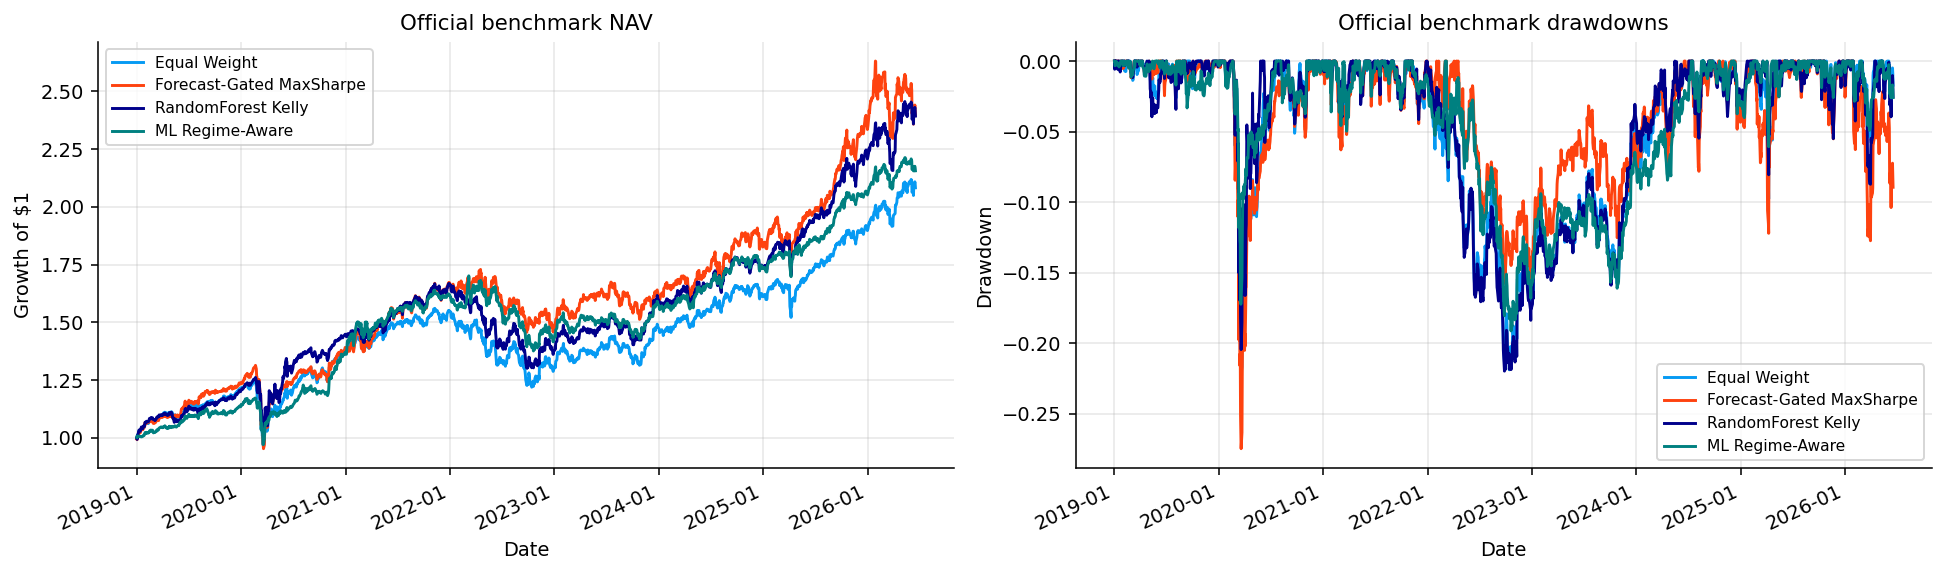

In [5]:
benchmark_nav_backtests = run_many_weights_backtests(official_benchmark_weights, returns=r_d.loc[pd.Timestamp("2019-01-01"):, assets + [cash_ticker]], cost_bps=cost_bps, rf_daily=rf_daily, w_min=0.0, w_max=1.0, long_only=True, normalize=True, weight_timing="next_close")
benchmark_nav = pd.DataFrame({name: res.net_values for name, res in benchmark_nav_backtests.items()}).dropna(how="all")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
plot_strategy_nav(benchmark_nav, ax=axes[0], title="Official benchmark NAV")
plot_strategy_drawdowns(benchmark_nav, ax=axes[1], title="Official benchmark drawdowns")
plt.tight_layout()
plt.show()


The benchmark NAV plot confirms that the rule-based baselines have very different behavior. Forecast-Gated MaxSharpe and RandomForest Kelly are more active and more concentrated than equal weight, so they have larger deviations through time. Equal weight is smoother but less informed. The regime-aware strategy tends to change more around stress and recovery periods because it is responding to market-state probabilities.

This matters for RL because we aren't training the agent in an empty world. The agent receives signals from a full research stack: forecasts, regimes, macro conditions, VIX, and previous portfolio state. The hard part is deciding whether those signals should translate into more risky exposure, more cash, higher concentration, lower turnover, or a different cross-asset allocation.


## 2) The Agent-Environment Loop

Reinforcement learning starts with an interaction loop. At each decision time, the agent observes a state, chooses an action, receives a reward, and moves to the next state.

$$
S_t \longrightarrow A_t \longrightarrow R_{t+1}, S_{t+1}
$$

In this portfolio setting:

- $S_t$ is the market and portfolio state at the weekly decision date,
- $A_t$ is the raw action produced by the policy network,
- $w_t$ is the valid portfolio weight vector after the raw action is mapped into constraints,
- $R_{t+1}$ is the reward earned over the next holding interval,
- $S_{t+1}$ is the updated market and portfolio state at the next decision date.


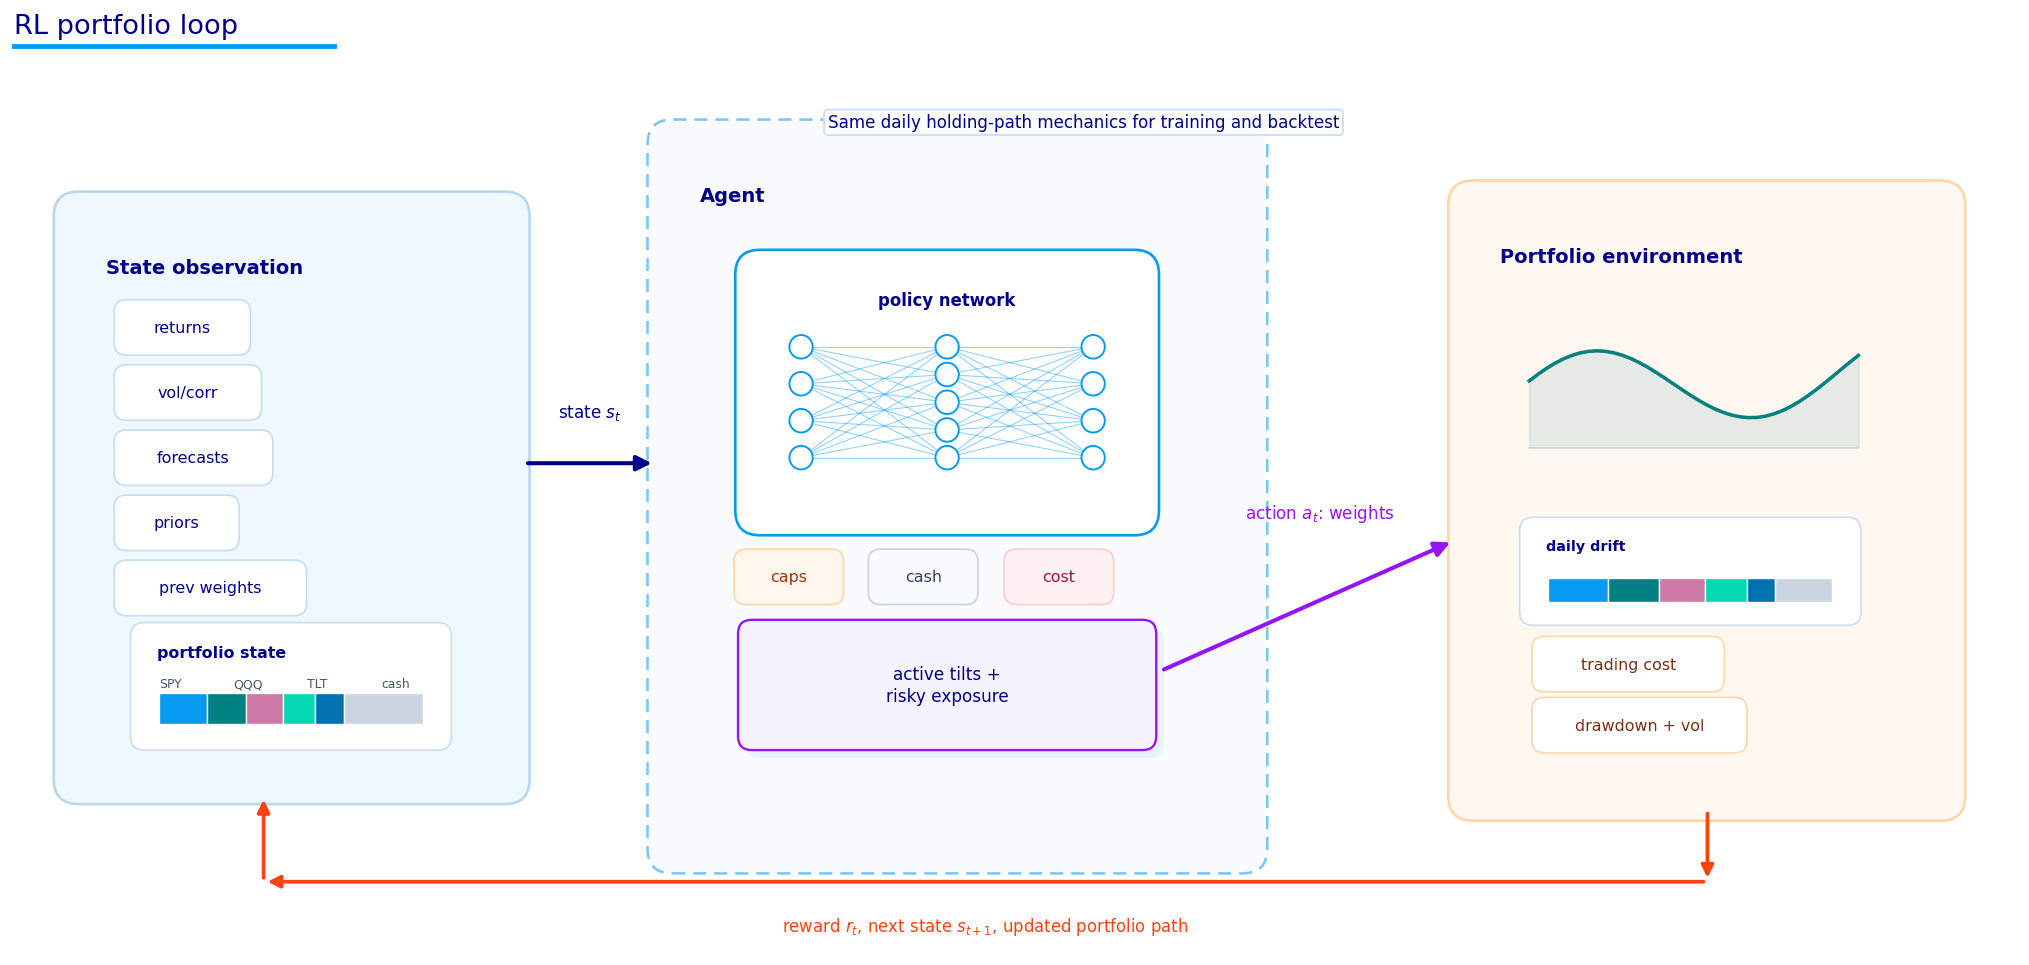

In [6]:
from quantfinlab.plotting.diagrams import agent_environment_loop_diagram
fig, ax = agent_environment_loop_diagram()
plt.show()


The first diagram shows this loop directly. The key financial difference from a normal supervised model is that the action changes the future portfolio path. A forecast model can be wrong and still leave the portfolio construction rule to handle the error. An RL agent owns the entire decision: if it chooses a high-turnover, high-concentration, high-risk allocation right before a drawdown, the reward should punish that decision.

A simple example makes the loop concrete. Suppose the state says credit is strong, equity breadth is high, volatility is low, and the previous portfolio is underweight risky assets. The policy may choose a high risky exposure and tilt toward SPY, QQQ, and HYG. The environment then applies that allocation over the next week, subtracts turnover costs, updates drawdown and realized volatility, and gives the agent a reward. If the decision raised return without creating too much risk, the reward improves. If it increased losses, turnover, drawdown, or concentration, the reward gets worse.

### 2.1 Supervised prediction and reinforcement learning in this project

Supervised learning and reinforcement learning look similar from far away because both train neural networks. The training signal is very different.

In supervised forecasting, we usually have pairs $(x_t, y_t)$ and minimize a prediction loss:

$$
\mathcal{L}(\theta) = \frac{1}{T}\sum_{t=1}^{T} \ell(f_\theta(x_t), y_t)
$$

The model sees the input $x_t$, predicts $y_t$, and gets judged against the realized label. If the label is next-month return rank, the training target is fixed before the model acts. The model doesn't change the market path by making a prediction.

In reinforcement learning, the training object is a **policy**:

$$
\pi_\theta(a_t \mid s_t)
$$

This means the model doesn't only predict a label. It chooses an action $a_t$ from state $s_t$. In this notebook, the action becomes the portfolio weights. The policy is judged by the reward sequence generated after its actions:

$$
J(\theta) = E_{\pi_\theta}\left[\sum_{t=0}^{T-1} \gamma^t R_{t+1}\right]
$$

The expectation is written under $\pi_\theta$ because the policy itself influences the path of portfolio weights, costs, drawdowns, and rewards. In a market backtest, asset returns are historical and fixed, but the portfolio path isn't fixed. The policy decides how much of each return stream it actually experiences.

This gives us the central RL difficulty: **credit assignment**. If a policy loses money in week 30, which earlier choices caused the problem? Was it the current allocation? A previous high-risk allocation that created drawdown pressure? A turnover decision that reduced wealth? A concentration choice that made the portfolio fragile? RL algorithms exist because this credit-assignment problem is hard.

In this notebook we use three modern continuous-control policy families:

- **PPO:** a stable on-policy actor-critic method that updates cautiously.
- **Recurrent PPO:** the same basic PPO idea, but with memory through an LSTM.
- **SAC:** an off-policy actor-critic method that adds entropy to encourage exploration and robust stochastic policies.

The rest of the notebook builds the machinery needed to understand these three models from the ground up.


The important habit while reading the rest of the notebook is to always connect the algorithmic object back to portfolio behavior. A value function is about future reward. A policy is about allocation. Entropy is about exploration. A critic is about judging whether an allocation was better than expected. Keeping that mapping clear makes the RL math much easier to follow.


The agent-environment diagram should be read from left to right. The agent never sees the future return before it acts. It only sees the current state and the previous portfolio context. The environment receives the action, converts it into realized portfolio behavior, and returns the next reward.

This is also why RL can easily overfit in finance. The sample is one historical market path, not millions of independent games. If the agent memorizes that one path, it may look good during training and fail out of sample. That is why this project uses a clear train/validation/test split, heavy constraints, risk penalties, and comparisons against simple baselines.

### 2.2 Exploration, exploitation, and portfolio risk

The exploration/exploitation tradeoff is one of the first RL ideas that feels very different in finance. Exploration means trying actions that may not look best right now so the agent can learn whether they work. Exploitation means using the action that currently looks best.

In a game environment, exploration might mean trying a weird move to discover a hidden reward. In a live portfolio, exploration has real cost. Trying a high-HYG/high-IWM/high-EEM allocation in a stress environment can lose money. So we need exploration during training, but we also need strict constraints and risk-aware rewards so the agent doesn't learn reckless behavior.

The policies in this notebook explore through stochastic actions. The actor outputs a Normal distribution over raw actions:

$$
a_t \sim \mathcal{N}(\mu_t, \sigma_t^2)
$$

The mean $\mu_t$ is the policy's preferred action. The standard deviation $\sigma_t$ controls how much it explores around that action. A high $\sigma_t$ means the policy samples many different allocations. A low $\sigma_t$ means the policy becomes more deterministic.

PPO uses entropy regularization to avoid collapsing too early. SAC goes further and makes entropy part of the main objective. This is useful because portfolio reward is noisy. A policy may look good after one lucky training path, but a more stochastic policy can avoid becoming too committed to one historical pattern.

There is also a financial version of exploration that appears through the action constraints. Since the policy can never go below 55% risky exposure or above 35% in one risky asset, its exploration is bounded. The agent can explore different allocation shapes, but it can't create absurd leverage or all-in positions. This is a strong design choice. It makes the training problem safer and the resulting policies more realistic.


### 2.3 Markov decision process notation

A fully observed reinforcement-learning problem is usually written as a **Markov decision process**:

$$
\mathcal{M} = (\mathcal{S}, \mathcal{A}, P, r, \gamma)
$$

Each component has a specific role:

- $\mathcal{S}$ is the set of possible states. In our case, a state contains asset features, global market features, and portfolio features.
- $\mathcal{A}$ is the action space. Here the action becomes a portfolio allocation.
- $P(s' \mid s,a)$ is the transition rule. It describes the probability of moving to next state $s'$ after taking action $a$ in state $s$.
- $r(s,a,s')$ is the reward function. Here it is built from portfolio return, differential Sharpe, costs, volatility, drawdown, and concentration penalties.
- $\gamma$ is the discount factor. It controls how much the agent cares about future rewards relative to immediate rewards.

The Markov part means that the current state is supposed to contain enough information to model the next step:

$$
P(S_{t+1} \mid S_t, A_t, S_{t-1}, A_{t-1}, \ldots) = P(S_{t+1} \mid S_t, A_t)
$$

This formula says that once we know the current state and action, the older history shouldn't add extra information. In markets this assumption is only approximate. If the state vector includes momentum, volatility, drawdown, forecast features, regimes, previous weights, and recent portfolio behavior, we are trying to compress the useful part of the history into $S_t$.

A useful way to understand the MDP components in this project is to map each symbol to something in the portfolio code.

| MDP object | Portfolio meaning | Concrete example in this notebook |
|---|---|---|
| $S_t$ | observed state | asset tensor, global tensor, prior weights, previous weights |
| $A_t$ | raw policy action | risky scores plus exposure score |
| $w_t$ | valid portfolio weights | constrained long-only weights after action mapping |
| $R_{t+1}$ | reward | DSR-based reward minus penalties |
| $P$ | transition law | historical next state after the decision date |
| $\gamma$ | future-reward weight | SAC uses $\gamma=0.97$ |

The transition law is the least controllable object. In a game simulator we can sample many possible futures. In finance, the notebook has one realized historical path. That is why the policy must be conservative. It can't assume it has seen every possible crisis, every possible rate shock, or every possible liquidity event.

The discount factor $\gamma$ deserves a clear interpretation. If $\gamma=0$, the agent only cares about immediate reward. If $\gamma$ is close to 1, it cares about longer-term consequences. With weekly decisions and $\gamma=0.97$, a reward one week ahead receives full weight, a reward ten weeks ahead receives about:

$$
0.97^{10} \approx 0.74
$$

So the agent still cares about what happens several months later. This is important because drawdown and turnover are path-dependent. A policy that grabs a tiny short-term reward by taking unstable risk can damage future reward through drawdown penalties and a worse wealth path.

The Markov assumption is an approximation, but the state design tries to make it less unrealistic. We add rolling windows, forecast ranks, regime probabilities, previous weights, volatility, drawdown, and macro indicators so the current observation carries information about recent history. The recurrent policy later goes one step further by learning an internal memory state.


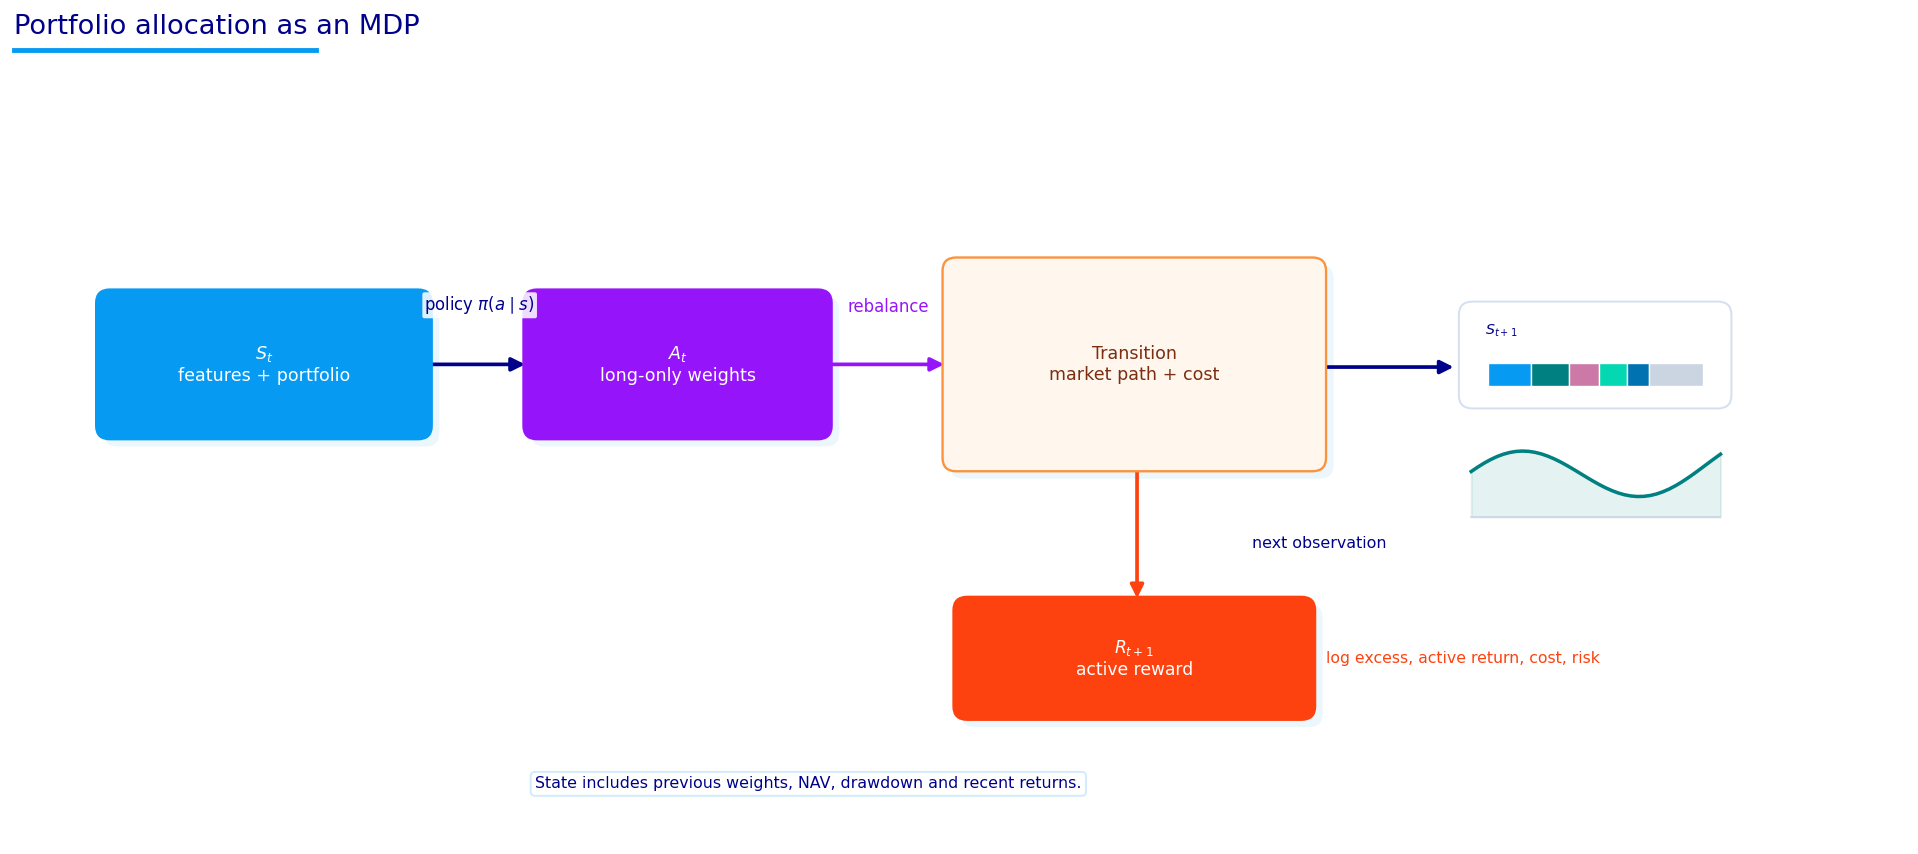

In [7]:
from quantfinlab.plotting.diagrams import mdp_diagram
fig, ax = mdp_diagram()
plt.show()


The MDP diagram shows how state, action, reward, and transition connect. In a textbook gridworld, the state might be the square where the agent stands, the action might be up/down/left/right, and the reward might be +1 for reaching the goal. In this project, the state is a high-dimensional financial vector, the action is a constrained weight vector, and the reward is a risk-adjusted portfolio outcome.

That difference changes the modeling challenge. The transition law $P$ isn't known. We don't know the true probability distribution of future market states. So we use **model-free RL**: the agent learns from sampled historical transitions rather than estimating a full economic transition model.


### 2.4 Partial observability in finance

The POMDP diagram is important because finance is rarely fully observable. We don't see the true economic state. We observe noisy proxies:

- prices and returns,
- volatility and drawdown,
- macro variables,
- FCI and NFCI features,
- VIX states,
- regime probabilities,
- forecast signals from the previous ML project,
- previous portfolio weights and turnover.

The hidden state might be something like true growth, liquidity, inflation risk, policy reaction function, investor leverage, or market fragility. We don't observe those directly. We observe indicators that may be correlated with them.

A partially observed problem can be written as:

$$
O_t \sim Z(\cdot \mid S_t)
$$

Here $S_t$ is the latent state and $O_t$ is the observation. The policy doesn't receive $S_t$ directly; it receives $O_t$. In the code, the state vector is really an observation vector. We still call it `state` because it is the input to the policy, but conceptually it is a compressed observation of the market.

This is one reason recurrent policies can help. If the current observation doesn't contain the full state, a recurrent network can use previous observations to build an internal memory:

$$
h_t = f_\theta(h_{t-1}, O_t)
$$

The hidden memory $h_t$ can carry information about how the market got here, not only where it is now.

Partial observability is especially important for portfolio allocation because many of the variables that drive markets are latent. We never directly observe "risk appetite" or "liquidity preference" as clean numeric series. We observe proxies. A positive HYG-LQD signal might suggest credit risk appetite. A negative NFCI value might suggest loose financial conditions. A falling VIX might suggest less demand for crash insurance. None of these is perfect.

This means the policy shouldn't treat one feature as truth. It has to combine imperfect signals. For example:

- high equity breadth and falling VIX point toward risk-on,
- rising dollar and weak EEM point against emerging markets,
- positive commodity momentum and weak duration point toward an inflation-sensitive environment,
- high realized correlation means diversification is weakening.

A non-recurrent policy receives this compressed state and acts immediately. A recurrent policy receives a sequence of states and can learn persistence. If financial conditions have been tightening for eight weeks, the recurrent state can carry that information even if the current observation alone looks neutral.

The hidden state in a recurrent policy is not an economic label. It is a learned vector. But if training works well, the vector can behave like a memory of recent market conditions:

$$
h_t = \text{LSTM}_\theta(h_{t-1}, o_t)
$$

Here $o_t$ is the current observation, and $h_t$ is the internal memory after processing it. The policy then chooses an action using $h_t$ along with the current input. This is why recurrent PPO is a natural second model in the project.


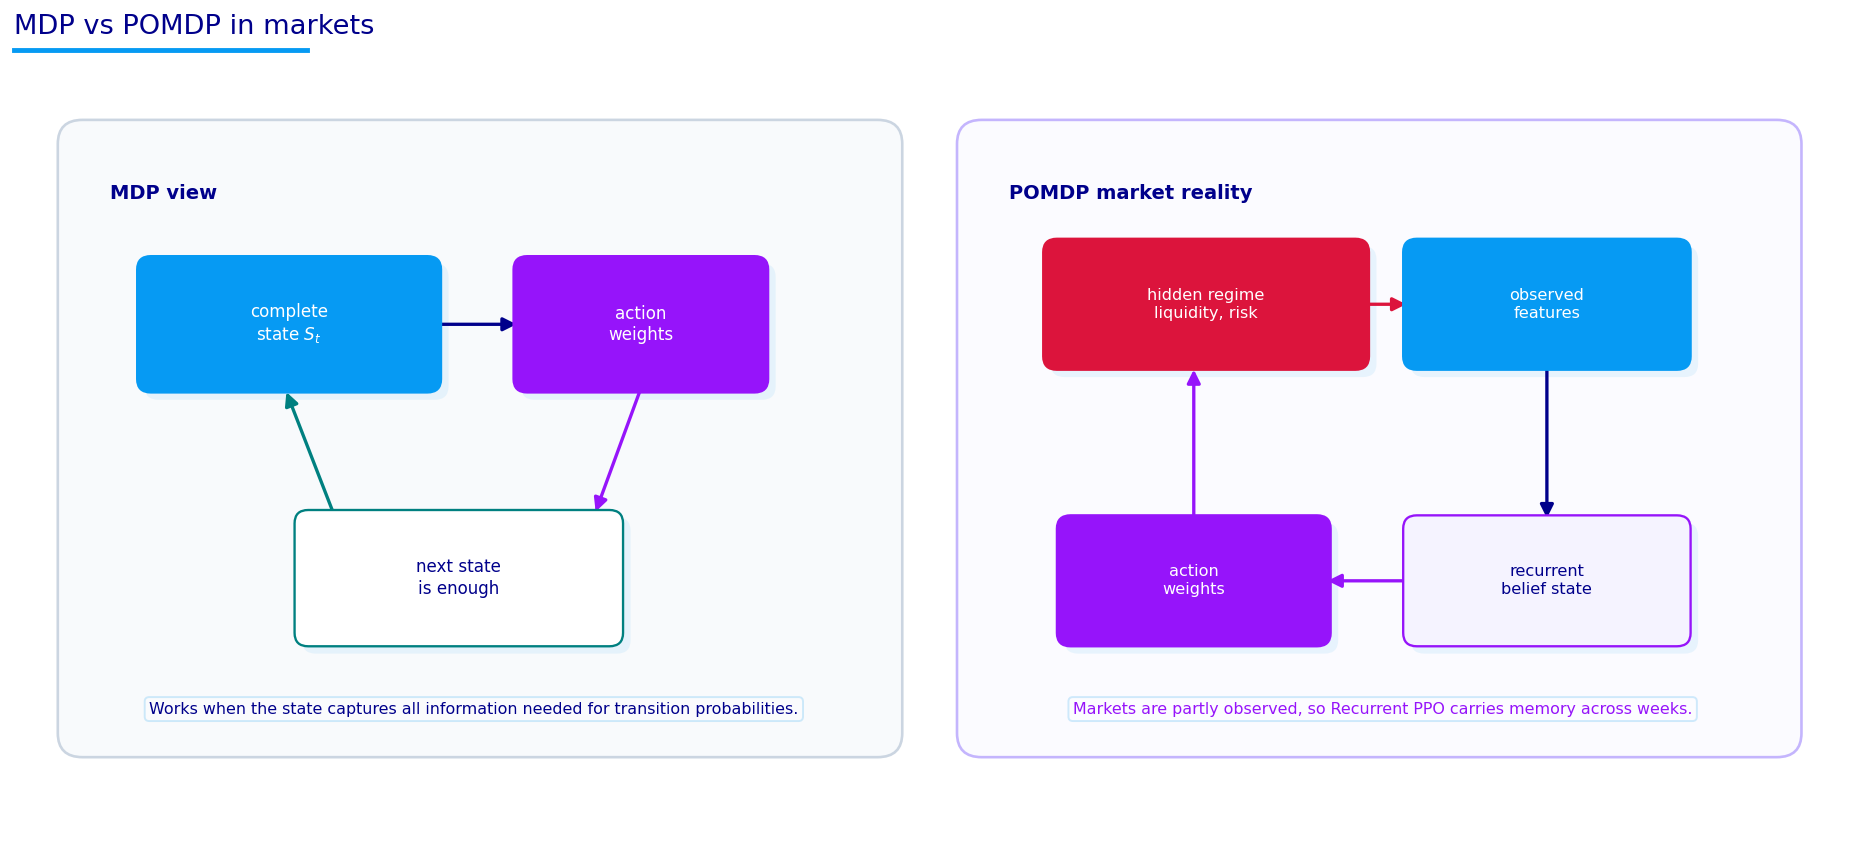

In [8]:
from quantfinlab.plotting.diagrams import mdp_pomdp_diagram
fig, ax = mdp_pomdp_diagram()
plt.show()


## 3) Building the State Tensors

The RL state is split into three parts:

1. **Asset state:** a tensor with one row per asset and one column per asset-specific feature.
2. **Global state:** a vector of market-wide context variables.
3. **Portfolio state:** previous weights and recent portfolio behavior.

The asset-state tensor has shape:

$$
X^{asset}_t \in \mathbb{R}^{N \times F_a}
$$

where $N$ is the number of risky assets and $F_a$ is the number of asset features. In the main implementation, the output later shows:

$$
X^{asset} \in \mathbb{R}^{949 \times 12 \times 50}
$$

This means we have 949 weekly decision points, 12 risky assets, and 50 asset-level features per asset. Every weekly decision is a small cross-sectional dataset: one row for SPY, one row for QQQ, one row for IWM, and so on.

The global-state tensor has shape:

$$
X^{global}_t \in \mathbb{R}^{F_g}
$$

and the output shows:

$$
X^{global} \in \mathbb{R}^{949 \times 31}
$$

So each decision also has 31 market-wide features. These are not asset-specific; they describe the whole environment.

The next-return matrix has shape:

$$
R^{next} \in \mathbb{R}^{949 \times 13}
$$

The 13 columns are the 12 risky assets plus SHY. This is what the environment uses to compute the realized portfolio return after the policy chooses weights.

The asset tensor structure is one of the cleanest ways to make the policy respect the cross-sectional nature of the problem. Instead of flattening everything into one long vector and asking the model to learn that SPY, QQQ, HYG, and GLD are different assets, we represent the input as a matrix:

$$
X^{asset}_t =
\begin{bmatrix}
\text{features of SPY at } t \\
\text{features of QQQ at } t \\
\vdots \\
\text{features of HYG at } t
\end{bmatrix}
$$

Each row is an asset. Each column is a feature type. This lets the network apply similar transformations across assets while still comparing assets to each other. That is useful for portfolio allocation because many decisions are relative: QQQ versus SPY, HYG versus LQD, EEM versus EFA, GLD versus DBC, and so on.

The global state has a different role:

$$
g_t \in \mathbb{R}^{F_g}
$$

It describes the market environment shared by all assets. A global feature like VIX, NFCI, breadth, or regime probability doesn't belong to one asset row. It affects the interpretation of every asset feature. A strong QQQ forecast is more attractive in a loose, low-volatility environment than in a tightening, high-correlation environment.

The portfolio state adds information about the agent's current position:

$$
p_t = [w_{t-1}, \text{cash}_{t-1}, \text{drawdown}_{t-1}, \text{recent vol}_{t-1}, \ldots]
$$

This matters because the same action has different cost depending on previous weights. If the policy already owns 25% SPY, staying at 25% has almost no turnover cost. Moving from 0% SPY to 25% SPY creates large turnover. RL has to learn this path dependence.


In [9]:
asset_x = build_asset_feature_block(close, volume, r_d, assets=assets, rf_daily=rf_daily)
asset_x = asset_x.merge(
    forecast_x[["date", "asset", "tcn_alpha", "tcn_rank", "tcn_confidence", "z_blend_rank", "z_blend_volscaled"]],
    on=["date", "asset"],
    how="left",
)
asset_feature_cols = [
    c for c in asset_x.columns
    if c not in {"date", "asset"} and pd.api.types.is_numeric_dtype(asset_x[c])
]
asset_coverage_by_date = asset_x.groupby("date")[asset_feature_cols].apply(lambda frame: frame.notna().mean().mean())
asset_count_by_date = asset_x.groupby("date")["asset"].nunique()
complete_asset_dates = asset_coverage_by_date.index[
    asset_coverage_by_date.ge(1.0) & asset_count_by_date.ge(len(assets))
]
state_ready_start = pd.Timestamp(complete_asset_dates.min()) if len(complete_asset_dates) else pd.Timestamp(asset_x["date"].min())
asset_train_mask = pd.to_datetime(asset_x["date"]) <= pd.Timestamp("2018-12-31")
asset_feature_fill_values = asset_x.loc[asset_train_mask, asset_feature_cols].median().replace([np.inf, -np.inf], np.nan).fillna(0.0)
asset_feature_fill_by_asset = (
    asset_x.loc[asset_train_mask, ["asset"] + asset_feature_cols]
    .groupby("asset", sort=False)
    .median(numeric_only=True)
    .replace([np.inf, -np.inf], np.nan)
)
display(pd.Series({
    "raw_first_date": pd.Timestamp(asset_x["date"].min()),
    "first_complete_asset_feature_date": state_ready_start,
    "raw_rows": len(asset_x),
    "feature_count": len(asset_feature_cols),
}).to_frame("value"))
display(asset_coverage_by_date.loc[:state_ready_start].tail(5).rename("raw_feature_coverage").to_frame().round(4))
display(asset_x.loc[pd.to_datetime(asset_x["date"]).ge(state_ready_start)].head())
print(asset_x.shape)


,value
raw_first_date,2007-04-11 00:00:00
first_complete_asset_feature_date,2008-04-10 00:00:00
raw_rows,57936
feature_count,49


,raw_feature_coverage
date,
2008-04-04,0.9592
2008-04-07,0.9592
2008-04-08,0.9592
2008-04-09,0.9592
2008-04-10,1.0000


,date,asset,r_1,r_5,r_21,r_63,r_126,skip_r_21_252,vol_21,vol_63,...,group_rel_vol_63,xs_z_trend_consistency,group_rel_trend_consistency,xs_z_resid_mom_63_spy,group_rel_resid_mom_63_spy,tcn_alpha,tcn_rank,tcn_confidence,z_blend_rank,z_blend_volscaled
252,2008-04-10,SPY,0.001398,-0.007443,0.030870,-0.026192,-0.121812,-0.066009,0.251724,0.228073,...,-0.032764,-1.193166,0.000000,-0.568644,-0.002489,-0.196916,-0.416667,0.555556,-0.416667,-0.416667
253,2008-04-11,SPY,-0.019409,-0.025641,0.020404,-0.051311,-0.137423,-0.078836,0.259511,0.230787,...,-0.033817,-1.044185,0.000000,-0.556735,0.001084,-0.176688,-0.416667,0.555556,-0.416667,-0.416667
254,2008-04-14,SPY,-0.003374,-0.029425,0.014722,-0.046821,-0.136187,-0.080996,0.259927,0.230371,...,-0.032315,-0.925820,0.000000,-0.590181,-0.005900,-0.165932,-0.250000,0.333333,-0.250000,-0.333333
255,2008-04-15,SPY,0.002332,-0.026166,0.033097,-0.052239,-0.138935,-0.103748,0.253072,0.229774,...,-0.031800,-1.042572,0.000000,-0.537243,-0.004245,-0.154985,-0.250000,0.333333,-0.250000,-0.333333
256,2008-04-16,SPY,0.027094,0.007509,0.071921,-0.004650,-0.108074,-0.115158,0.263838,0.232279,...,-0.031974,-0.768350,-0.083333,-0.590328,-0.003910,-0.232554,-0.416667,0.555556,-0.416667,-0.416667


(57936, 51)


In [10]:
context_x = build_cross_asset_feature_block(close, r_d, assets=assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker)
fci_x = build_fci_feature_block(macro_factors, nfci, index=close.index)
regime_x = regime_probability_features(
    close,
    r_d,
    assets=assets,
    cash_ticker=cash_ticker,
    benchmark_ticker=benchmark_ticker,
    model="LogisticRegression",
    horizon=21,
    rebalance_dates=decision_dates,
    output="features",
    n_jobs=4,
)
global_x = pd.concat([context_x, fci_x, regime_x, vix_x], axis=1)
global_x = global_x.loc[:, ~global_x.columns.duplicated()].sort_index()
display(global_x.tail())
print(global_x.shape)


,breadth_21,breadth_63,dispersion_21,dispersion_63,rolling_avg_corr_63,rolling_avg_corr_126,spy_r_63,qqq_spy_63,hyg_lqd_63,hyg_lqd_change_63,...,policy_pressure,inflation_pressure,growth_pressure,nfci_level,nfci_change_21,nfci_change_63,p_risk_on,p_neutral,p_defensive,regime_confidence
date,,,,,,,,,,,,,,,,,,,,,
2026-06-11,0.750000,0.750000,0.044214,0.104814,0.509609,0.429081,0.110673,0.091524,0.006216,-0.000880,...,-0.05705,0.399197,-0.05581,-0.524,-0.03,-0.021,NaN,NaN,NaN,NaN
2026-06-12,0.750000,0.750000,0.043520,0.108026,0.507497,0.427247,0.123036,0.093446,0.005049,-0.005024,...,-0.05705,0.399197,-0.05581,-0.524,-0.03,-0.021,0.410533,0.313813,0.275653,0.410533
2026-06-15,0.833333,0.666667,0.042308,0.108733,0.501126,0.424766,0.131327,0.109451,0.008167,0.000994,...,-0.05705,0.399197,-0.05581,-0.524,-0.03,-0.021,NaN,NaN,NaN,NaN
2026-06-16,0.833333,0.666667,0.046855,0.100326,0.495992,0.420540,0.121632,0.089653,0.007885,0.005948,...,-0.05705,0.399197,-0.05581,-0.524,-0.03,-0.021,NaN,NaN,NaN,NaN
2026-06-17,0.833333,0.750000,0.050512,0.105326,0.493515,0.423489,0.123299,0.092739,0.007081,0.004213,...,-0.05705,0.399197,-0.05581,-0.524,-0.03,-0.021,0.350381,0.360302,0.289317,0.360302


(4828, 31)


The feature output confirms that the raw asset feature block becomes complete on **2008-04-10**. We start the RL decision sequence after that point. The raw feature table has **57,936 rows**, which equals daily observations multiplied by assets, and **49 raw features** before the later merged forecast features bring the asset-state dimension to 50.

The sample rows show a typical asset-state record for SPY: recent returns over 1, 5, 21, 63, and 126 days, skip-momentum, rolling volatility, group-relative features, trend consistency, residual momentum versus SPY, and TCN forecast features like `tcn_alpha`, `tcn_rank`, and `tcn_confidence`. These features are exactly the sort of variables that a portfolio allocator might use manually: recent strength, risk level, relative ranking, and forecast confidence.

The context-feature table at the end of the sample shows a recent risk-on environment: breadth around 0.75 to 0.83, SPY positive over 63 days, QQQ outperforming SPY, HYG slightly outperforming LQD, and NFCI negative, which means financial conditions are easier than average. The regime probabilities are available on some dates after the model updates. They don't decide the RL action by themselves, but they are part of the state.


In [11]:
def align_weight_frame(weights, target_dates, columns, fallback_equal=False):
    dates = pd.DatetimeIndex(target_dates).sort_values().unique()
    W = pd.DataFrame(weights).copy()
    if W.empty:
        base = pd.DataFrame(0.0, index=dates, columns=columns)
        if fallback_equal:
            base[assets] = 1.0 / len(assets)
        return base
    W.index = pd.to_datetime(W.index)
    W = W.sort_index().reindex(columns=columns)
    W = W.reindex(W.index.union(dates)).sort_index().ffill().reindex(dates).fillna(0.0)
    zero = W.sum(axis=1).abs() <= 1e-12
    if bool(zero.any()) and fallback_equal:
        W.loc[zero, assets] = 1.0 / len(assets)
    row_sum = W.sum(axis=1).replace(0.0, np.nan)
    return W.div(row_sum, axis=0).fillna(0.0)

def period_daily_windows(returns, decision_dates, columns):
    R = returns.reindex(columns=columns).fillna(0.0)
    idx = pd.DatetimeIndex(R.index)
    rows, windows = [], []
    for i, dt in enumerate(decision_dates):
        start = idx.searchsorted(pd.Timestamp(dt), side="right")
        if start >= len(idx):
            continue
        end = idx.searchsorted(pd.Timestamp(decision_dates[i + 1]), side="right") if i + 1 < len(decision_dates) else min(start + 5, len(idx))
        if end <= start:
            continue
        window = R.iloc[start:end].replace([np.inf, -np.inf], np.nan).fillna(0.0)
        rows.append(((1.0 + window).prod() - 1.0).rename(pd.Timestamp(dt)))
        windows.append(window)
    return pd.DataFrame(rows).reindex(columns=columns).fillna(0.0), windows

state_dates = pd.DatetimeIndex([d for d in decision_dates if pd.Timestamp(d) >= state_ready_start])
state_columns = assets + [cash_ticker]
returns_next, daily_windows = period_daily_windows(r_d, state_dates, state_columns)
state_dates = returns_next.index
daily_windows_np = [w.reindex(columns=state_columns).fillna(0.0).to_numpy(dtype=float) for w in daily_windows]


In [12]:
feature_cols = [
    c for c in asset_x.columns
    if c not in {"date", "asset"} and pd.api.types.is_numeric_dtype(asset_x[c])
]

asset_blocks = []
asset_feature_names = []
for col in feature_cols:
    piv = asset_x.pivot_table(index="date", columns="asset", values=col, aggfunc="last")
    piv = piv.reindex(piv.index.union(state_dates)).sort_index().ffill().reindex(state_dates)
    piv = piv.reindex(columns=assets)
    fill_by_asset = asset_feature_fill_by_asset[col].reindex(assets) if col in asset_feature_fill_by_asset.columns else pd.Series(np.nan, index=assets)
    fill_by_asset = fill_by_asset.fillna(float(asset_feature_fill_values.get(col, 0.0)))
    asset_blocks.append(piv.fillna(fill_by_asset).fillna(0.0))
    asset_feature_names.append(col)
asset_blocks.append(pd.DataFrame(0.0, index=state_dates, columns=assets))
asset_feature_names.append("previous_weight")

asset_state = np.stack([b.to_numpy(dtype=np.float32) for b in asset_blocks], axis=2)
global_state_frame = global_x.reindex(global_x.index.union(state_dates)).sort_index().ffill().reindex(state_dates)
global_state_frame = global_state_frame.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0)
global_state = global_state_frame.to_numpy(dtype=np.float32)
shape_table = pd.DataFrame({
    "shape": [
        asset_state.shape,
        global_state.shape,
        returns_next.shape,
    ]
}, index=["asset_state", "global_state", "returns_next"])
display(shape_table)


,shape
asset_state,"(949, 12, 50)"
global_state,"(949, 31)"
returns_next,"(949, 13)"


The output confirms the final state shapes:

$$
X^{asset}: (949, 12, 50), \qquad X^{global}: (949, 31), \qquad r^{next}: (949, 13)
$$

So at each of 949 weekly decision points, the policy sees 12 risky assets, 50 asset-level features, 31 global features, and next-period returns for 13 investable columns including SHY. These shapes are the practical version of the theoretical state/action/reward setup.


### 3.1 The leakage check

The state construction must avoid target leakage. We don't want future labels like `z_21` or `y_alpha` to sneak into the RL state. Those labels were used in [Project 19](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/19_forecasting_kelly_allocation.html) for forecasting, but here the RL policy should only see forecasts and features available at the decision time.


In [13]:
diagnostics = pd.DataFrame({
    "missing_share": [
        float(np.isnan(asset_state).mean()),
        float(np.isnan(global_state).mean()),
        float(returns_next.isna().mean().mean()),
    ],
    "max_abs": [
        float(np.nanmax(np.abs(asset_state))),
        float(np.nanmax(np.abs(global_state))),
        float(np.nanmax(np.abs(returns_next.to_numpy()))),
    ],
}, index=["asset_state", "global_state", "returns_next"])
display(diagnostics.round(4))
print(state_dates.min().date(), state_dates.max().date(), len(state_dates))


,missing_share,max_abs
asset_state,0.0,7.3231
global_state,0.0,3.2942
returns_next,0.0,0.2830


2008-04-11 2026-06-12 949


The output reports:

- asset state shape: **(949, 12, 50)**,
- global state shape: **(949, 31)**,
- next returns shape: **(949, 13)**,
- missing share: **0.0** for all state blocks,
- max absolute values that are finite and controlled after feature cleaning.

This is a small output, but it is one of the most important engineering checks. If leakage enters the state, the RL policy can appear to learn a brilliant allocation rule while really reading the answer key. The diagnostic says the state table is complete and clean for the main environment.

Leakage control is more important in this project than in a simple regression because RL can exploit tiny mistakes brutally. If a future-return label accidentally enters the state, the agent doesn't need to understand finance; it can learn a direct shortcut. That would produce a beautiful backtest and a useless policy.

The leakage check verifies that the state doesn't include target columns such as next-period realized return, future alpha, or future rank. The output shows missing share equal to zero and bounded feature magnitudes. This means two things:

1. The state tensors are complete, so the environment won't be forced to handle missing rows during training.
2. The standardized features don't contain extreme numerical explosions that would destabilize neural-network training.

The maximum absolute feature values are also useful. Asset features reach about 7.32 in standardized units, while global features reach about 3.29. That is large but still manageable. If the model saw values in the hundreds or thousands, gradient updates could become unstable, especially in PPO and SAC where policy log-probabilities and value losses interact.

For a finance ML notebook, this small diagnostic is one of the most important quality checks. It protects the credibility of everything that follows.


## 4) Continuous Actions as Portfolio Weights

In many RL examples the action space is discrete. An Atari agent chooses a joystick action. A gridworld agent chooses up, down, left, or right. A portfolio agent has a different problem: it needs to choose a **vector of weights**.

The raw action vector has length $N+1$:

$$
z_t = \begin{bmatrix} z_{1,t} & z_{2,t} & \cdots & z_{N,t} & e_t \end{bmatrix}
$$

The first $N$ elements are risky-asset logits. The last element controls total risky exposure. The code maps this raw action into valid weights through two transformations.

First, the exposure logit becomes a risky-exposure level using a sigmoid:

$$
E_t = E_{min} + (E_{max} - E_{min}) \cdot \sigma(e_t)
$$

where $E_{min}=0.55$ and $E_{max}=1.00$. The sigmoid $\sigma(e_t)$ maps any real number into $(0,1)$, so the model can output unconstrained neural-network values while the final exposure remains bounded. If $e_t=0$, then $\sigma(0)=0.5$ and the exposure becomes halfway between 55% and 100%:

$$
E_t = 0.55 + 0.45 \times 0.5 = 0.775
$$

Second, the risky logits become cross-sectional risky weights through a softmax:

$$
\tilde{w}_{i,t} = \frac{\exp(z_{i,t})}{\sum_{j=1}^{N} \exp(z_{j,t})}
$$

The risky sleeve before caps is then:

$$
w^{risky}_{i,t} = E_t \cdot \tilde{w}_{i,t}
$$

This is a good action design because the neural network doesn't have to learn the fully invested constraint from scratch. The transformation guarantees nonnegative weights and a controlled risky exposure. After that, the code caps each risky asset at 35% and redistributes any excess weight to assets with remaining room. Cash is the leftover:

$$
w^{cash}_t = 1 - \sum_{i=1}^{N} w^{risky}_{i,t}
$$

So the final action is always a valid long-only portfolio.

### 4.1 From raw neural-network output to valid weights

The policy network doesn't directly output final portfolio weights. It outputs an unconstrained action vector. That raw action must be translated into weights that obey the portfolio rules.

Let the raw action be:

$$
a_t = [z_{1,t}, z_{2,t}, \ldots, z_{N,t}, e_t]
$$

The first $N$ entries are risky-asset scores. The last entry $e_t$ controls total risky exposure. The risky scores are passed through a softmax:

$$
\tilde{w}_{i,t} = \frac{\exp(z_{i,t})}{\sum_{j=1}^{N}\exp(z_{j,t})}
$$

This creates a long-only allocation across risky assets. Every $\tilde{w}_{i,t}$ is positive, and the risky weights sum to 1. The exposure score is passed through a sigmoid and scaled into a range:

$$
E_t = E_{min} + (E_{max}-E_{min})\sigma(e_t)
$$

where $E_{min}=0.55$ and $E_{max}=1.00$. This means the policy is always at least 55% invested in risky assets and can go up to 100%. SHY receives the leftover cash-like weight:

$$
w_{SHY,t} = 1 - E_t
$$

Then the risky weights become:

$$
w_{i,t} = E_t \tilde{w}_{i,t}
$$

A cap is applied so no single risky asset can dominate the portfolio:

$$
w_{i,t} \le 0.35
$$

If an asset hits the cap, the excess weight is redistributed across the uncapped assets. This keeps the policy from solving the problem by putting everything into one high-forecast asset.


In [14]:
def action_to_weights(raw_action, min_exposure=0.55, max_exposure=1.00, max_weight=0.35, active_scale=0.35):
    if torch.is_tensor(raw_action):
        logits = raw_action[..., :-1]
        exposure = min_exposure + (max_exposure - min_exposure) * torch.sigmoid(raw_action[..., -1])
        risky = torch.softmax(logits, dim=-1) * exposure.unsqueeze(-1)
        for _ in range(12):
            capped = risky.clamp(max=max_weight)
            excess = (risky - capped).clamp_min(0.0).sum(dim=-1, keepdim=True)
            room = (max_weight - capped).clamp_min(0.0)
            risky = capped + excess * room / room.sum(dim=-1, keepdim=True).clamp_min(1e-8)
            if not bool((risky > max_weight + 1e-7).any()):
                break
        cash = 1.0 - risky.sum(dim=-1, keepdim=True).clamp(0.0, 1.0)
        return torch.cat([risky, cash], dim=-1)
    raw = np.asarray(raw_action, dtype=float)
    logits = raw[..., :-1]
    exposure = min_exposure + (max_exposure - min_exposure) / (1.0 + np.exp(-raw[..., -1]))
    shifted = logits - np.max(logits, axis=-1, keepdims=True)
    soft = np.exp(shifted) / np.exp(shifted).sum(axis=-1, keepdims=True)
    risky = soft * np.expand_dims(exposure, axis=-1)
    for _ in range(20):
        capped = np.minimum(risky, max_weight)
        excess = np.maximum(risky - capped, 0.0).sum(axis=-1, keepdims=True)
        room = np.maximum(max_weight - capped, 0.0)
        risky = capped + excess * room / np.maximum(room.sum(axis=-1, keepdims=True), 1e-12)
        if not np.any(risky > max_weight + 1e-10):
            break
    cash = 1.0 - risky.sum(axis=-1, keepdims=True)
    return np.concatenate([risky, cash], axis=-1)

display(pd.Series(action_to_weights(np.zeros(len(assets) + 1)), index=state_columns).round(4).to_frame("weight"))


,weight
SPY,0.0646
QQQ,0.0646
IWM,0.0646
EFA,0.0646
EEM,0.0646
VNQ,0.0646
DBC,0.0646
GLD,0.0646
IEF,0.0646
TLT,0.0646


A small example helps. If the network gives equal scores to all 12 risky assets and chooses the neutral exposure, the output shows about **6.46%** in each risky asset and **22.5%** in SHY. The policy starts from a diversified risky sleeve plus defensive cash-like ballast. Training then teaches it how to move away from that neutral shape.

This mapping is one of the most important implementation choices in the notebook. Instead of asking RL to learn portfolio constraints from penalties, we build the constraints into the action transformation. That makes training easier and keeps every sampled action investable.

### 4.2 The geometry of the action space

Portfolio weights live on a simplex:

$$
\Delta^{N} = \left\{w\in\mathbb{R}^{N+1}: w_i\ge 0,\; \sum_i w_i=1\right\}
$$

The simplex constraint is strict. A policy can't output weights that sum to 1.08 or -3% in an asset unless shorting/leverage is allowed. This project is long-only and fully invested, so every final action must land inside the simplex.

The raw action lives in unconstrained Euclidean space:

$$
a_t\in\mathbb{R}^{N+1}
$$

The action mapping is therefore a projection-like transformation from unconstrained scores to feasible portfolio weights. The softmax handles relative risky weights, the sigmoid handles total risky exposure, and the cap redistribution handles maximum position size.

This separation is cleaner than asking the neural network to learn feasibility by itself. If the policy output final weights directly, we would need penalties for invalid weights or a complicated constrained distribution. Here every sampled action is valid after transformation. That lets the RL algorithm focus on learning which valid portfolio shapes produce better reward.

The max-weight cap is also important for exploration. Without it, an early lucky sequence could teach the policy that one asset deserves extreme allocation. The cap forces the model to express conviction through a diversified sleeve. For example, if SAC likes risk, it can overweight SPY, IWM, QQQ, and HYG, but it can't put 80% in one ticker.

This is a practical finance choice, not only a machine-learning choice. Real allocators usually care about concentration, liquidity, and mandate limits. Building those into the environment makes the learned policy more credible.


The neutral action output helps verify the transformation. When the raw action is all zeros, the model doesn't choose an equal 1/13 allocation. It chooses about **6.46%** in each risky asset and **22.50%** in SHY.

That comes directly from the exposure formula. A zero exposure logit gives 77.5% risky exposure. Split equally over 12 risky assets, that is:

$$
\frac{0.775}{12} \approx 0.0646
$$

and the remaining 22.5% goes to cash-like SHY. This is a very useful sanity check because it tells us the default policy is neither all-cash nor fully risky. It begins from a balanced point and then learns to tilt.


## 5) Transaction Costs, Returns, and Portfolio Path Updates

The environment has to translate a weekly weight decision into a realized portfolio path. The realized return over the holding interval is computed from the asset returns and the chosen weights. If the action changes the portfolio from $w_{t-1}$ to $w_t$, the turnover is approximately:

$$
\text{turnover}_t = \frac{1}{2}\sum_i |w_{i,t} - w_{i,t-1}^{end}|
$$

The factor $1/2$ avoids double-counting buys and sells. If we sell 10% of one asset and buy 10% of another, the absolute changes sum to 20%, but the traded portfolio notional is 10%.

The transaction cost is:

$$
\text{cost}_t = \text{turnover}_t \times \frac{\text{cost bps}}{10{,}000}
$$


In [15]:
def portfolio_turnover(w_new, w_prev):
    new = np.asarray(w_new, dtype=float)
    prev = np.asarray(w_prev, dtype=float)
    if prev.sum() > 1e-12:
        prev = prev / prev.sum()
    return 0.5 * float(np.abs(new - prev).sum())

def portfolio_step_return(w_new, r_next, w_prev=None, cost_bps=10.0):
    turnover = portfolio_turnover(w_new, w_prev) if w_prev is not None else 0.0
    cost = float(cost_bps) / 10000.0 * turnover
    gross = float(np.dot(np.asarray(w_new), np.asarray(r_next)))
    return gross - cost, turnover, cost

def portfolio_step_path_return(w_new, daily_window, w_prev=None, cost_bps=10.0):
    w = np.asarray(w_new, dtype=float).reshape(-1)
    if w.sum() > 1e-12:
        w = w / w.sum()
    prev = np.zeros_like(w) if w_prev is None else np.asarray(w_prev, dtype=float).reshape(-1)
    if prev.sum() > 1e-12:
        prev = prev / prev.sum()
    turnover = 0.5 * float(np.abs(w - prev).sum())
    cost = float(cost_bps) / 10000.0 * turnover
    net = max(1.0 - cost, 1e-12)
    drift_w = w.copy()
    daily_net_returns, nav_path = [], []
    prev_net = 1.0
    R = daily_window if isinstance(daily_window, np.ndarray) else pd.DataFrame(daily_window).reindex(columns=state_columns).fillna(0.0).to_numpy(dtype=float)
    for i, row in enumerate(R):
        port_ret = float(np.dot(drift_w, row))
        net *= 1.0 + port_ret
        daily_net_returns.append(net / prev_net - 1.0 if i == 0 else port_ret)
        nav_path.append(net)
        grossed = drift_w * (1.0 + row)
        gross_sum = float(grossed.sum())
        drift_w = grossed / gross_sum if gross_sum > 0 and np.isfinite(gross_sum) else np.zeros_like(drift_w)
        prev_net = net
    return float(net - 1.0), turnover, cost, drift_w, np.asarray(daily_net_returns, dtype=float), np.asarray(nav_path, dtype=float)

print(portfolio_step_path_return(np.r_[np.repeat(1/len(assets), len(assets)), 0.0], daily_windows[0], np.zeros(len(state_columns)), cost_bps)[:3])


(0.019561765404170206, 0.5, 0.0005)


With 10 bps cost, turnover of 0.50 costs 0.0005, or 5 basis points of portfolio value. The printed check returns exactly `(0.01956, 0.5, 0.0005)`, meaning the test portfolio produced about 1.96% gross net step return with 50% turnover and 5 bps cost.

This is important because RL can otherwise learn unrealistic churning. A policy that changes weights aggressively every week may look good before costs and much weaker after costs. The environment makes turnover part of both the realized return and the reward penalty.

The transaction-cost formula is simple but important:

$$
\text{turnover}_t = \frac{1}{2}\sum_i |w_{i,t} - w^{pre}_{i,t}|
$$

Here $w^{pre}_{i,t}$ is the portfolio weight just before rebalancing, after market moves have changed the previous weights. The factor $1/2$ appears because buying one asset and selling another creates two absolute weight changes for one dollar of portfolio rotation. If we sell 10% of SPY and buy 10% of GLD, the absolute changes sum to 20%, but the actual portfolio turnover is 10%.

The trading cost is:

$$
\text{cost}_t = \text{turnover}_t \times \frac{\text{cost bps}}{10000}
$$

With 10 bps cost, a turnover of 0.50 costs 0.0005, or 5 basis points of portfolio value. The sanity output `(0.01956, 0.5, 0.0005)` confirms exactly this logic: the example action produces a portfolio path return around 1.96%, turnover of 50%, and cost of 0.05%.

This cost term is a major reason RL policies shouldn't chase every small forecast wiggle. A forecast must be strong enough to overcome the cost of changing weights. If the policy learns to trade too much, the reward should punish it through the cost penalty and through lower net portfolio returns.


## 6) Reward Design with Differential Sharpe

Reward design is where portfolio RL becomes finance-specific. If we reward only next-period return, the agent can learn to maximize upside by taking too much risk. If we reward only low volatility, it may hide in cash. The reward has to push the agent toward a usable investment policy.

The primary reward in this project is based on the **differential Sharpe ratio** (DSR). The idea is to approximate how a new return observation changes the running Sharpe ratio. We maintain exponentially updated moments:

$$
A_t = A_{t-1} + \eta(r_t - A_{t-1})
$$

$$
B_t = B_{t-1} + \eta(r_t^2 - B_{t-1})
$$

Here $A_t$ is a running mean estimate, $B_t$ is a running second-moment estimate, and $\eta$ controls how quickly the estimates update. The variance estimate is:

$$
\sigma_t^2 \approx B_t - A_t^2
$$

A normal Sharpe ratio is roughly:

$$
SR_t = \frac{A_t}{\sqrt{B_t - A_t^2}}
$$

The differential Sharpe asks how the current return changes this running ratio. The code computes:

$$
DSR_t = \frac{B_{t-1}\Delta A_t - \frac{1}{2}A_{t-1}\Delta B_t}{(B_{t-1} - A_{t-1}^2)^{3/2}}
$$

where:

$$
\Delta A_t = r_t - A_{t-1}, \qquad \Delta B_t = r_t^2 - B_{t-1}
$$

The numerator has two parts. The first part rewards returns above the current average. The second part penalizes returns that increase the second moment too much. So a positive return with modest volatility can have a positive DSR, while a large noisy return can be less attractive than its raw return suggests.

The reward doesn't stop there. The full reward is:

$$
R_t = 4 \cdot DSR_t - P^{dd}_t - P^{vol}_t - P^{cost}_t - P^{conc}_t - P^{cash}_t - P^{corr}_t
$$

Each penalty targets a specific portfolio failure mode:

- $P^{dd}_t$ penalizes drawdowns below the -12% floor,
- $P^{vol}_t$ penalizes realized volatility above the 18% target,
- $P^{cost}_t$ penalizes turnover cost,
- $P^{conc}_t$ penalizes excessive concentration using HHI,
- $P^{cash}_t$ penalizes cash above 20%,
- $P^{corr}_t$ penalizes policies that are too correlated with equal weight.

This reward is deliberately opinionated. We are not asking the agent to maximize raw wealth at all costs. We are training it to be a cost-aware, drawdown-aware, volatility-aware portfolio allocator.

### 6.1 Differential Sharpe from running moments

The reward is based on **differential Sharpe ratio** (DSR), which is useful when an agent receives rewards step by step. A normal Sharpe ratio is computed after a full return series:

$$
SR = \frac{\bar{r}}{\sqrt{\overline{r^2} - \bar{r}^2}}
$$

This is not directly convenient as a per-step reward because the Sharpe ratio depends on the whole history. DSR turns the idea into an incremental signal. We maintain running estimates of the first and second moments:

$$
A_t = A_{t-1} + \eta(r_t - A_{t-1})
$$

$$
B_t = B_{t-1} + \eta(r_t^2 - B_{t-1})
$$

Here:

- $A_t$ is the running mean return estimate,
- $B_t$ is the running second-moment estimate,
- $\eta$ is the update speed,
- $B_t - A_t^2$ is the running variance estimate.

The DSR approximation used in the environment measures how the new return changes the Sharpe estimate:

$$
DSR_t = \frac{B_{t-1}(r_t-A_{t-1}) - \frac{1}{2}A_{t-1}(r_t^2-B_{t-1})}{(B_{t-1}-A_{t-1}^2)^{3/2}}
$$

This formula looks dense, so let's unpack it. The term $r_t-A_{t-1}$ asks whether today's return is above the current running mean. That improves the numerator. The term $r_t^2-B_{t-1}$ asks whether today's squared return is above the current running second moment. That increases estimated volatility, which can hurt Sharpe. So DSR rewards returns that improve mean more than they increase variance.

This is a good fit for allocation. A high-return week with huge volatility doesn't automatically receive a huge reward. A moderate positive return with controlled volatility can be more valuable. That matches the financial objective of building a stable risk-adjusted portfolio rather than maximizing raw return.

### 6.2 Reward components as portfolio behavior constraints

The full reward combines DSR with penalties:

$$
R_t = 4\cdot DSR_t - \lambda_{cost}C_t - \lambda_{vol}V_t - \lambda_{dd}D_t - \lambda_{conc}H_t - \lambda_{cash}K_t - \lambda_{corr}M_t
$$

Each penalty is connected to a real portfolio failure mode:

- $C_t$ penalizes turnover cost.
- $V_t$ penalizes realized volatility above the target.
- $D_t$ penalizes drawdown beyond the floor.
- $H_t$ penalizes concentration through HHI.
- $K_t$ penalizes excessive cash above the cap.
- $M_t$ penalizes portfolios that remain too close to equal-weight behavior when correlation is high.

The concentration penalty uses the Herfindahl-Hirschman index:

$$
HHI_t = \sum_i w_{i,t}^2
$$

If the portfolio is equally spread across 12 risky assets, HHI is low. If the portfolio puts 35% into one asset and large weights into only a few others, HHI rises. The effective number of assets is:

$$
N_{eff,t} = \frac{1}{HHI_t}
$$

This is easier to interpret. An HHI of 0.10 means the portfolio behaves roughly like 10 equally weighted assets. An HHI of 0.25 means it behaves like only 4 equally weighted assets.


In [16]:
class DifferentialSharpe:
    def __init__(self, eta=0.01):
        self.eta = float(eta)
        self.A = 0.0
        self.B = 0.0
        self.initialized = False

    def update(self, r):
        r = float(r)
        if not self.initialized:
            self.A, self.B, self.initialized = r, r * r, True
            return 0.0
        delta_a = r - self.A
        delta_b = r * r - self.B
        denom = max((self.B - self.A * self.A) ** 1.5, 1e-8)
        dsr = (self.B * delta_a - 0.5 * self.A * delta_b) / denom
        self.A += self.eta * delta_a
        self.B += self.eta * delta_b
        return float(np.clip(dsr, -10.0, 10.0))

def reward_components(portfolio_return, dsr_value, turnover, cost, weights, realized_vol, drawdown, settings, decorr=0.0):
    primary = settings["dsr_scale"] * dsr_value
    dd_excess = max(0.0, settings["drawdown_floor"] - drawdown)
    dd_pen = settings["lambda_drawdown"] * 100.0 * dd_excess ** 2
    vol_excess = max(0.0, realized_vol - settings["target_vol"])
    vol_pen = settings["lambda_vol"] * 100.0 * vol_excess ** 2
    cost_pen = settings["lambda_cost"] * settings["cost_bps"] * turnover
    hhi = float(np.square(np.clip(weights[:-1], 0.0, 1.0)).sum())
    conc_pen = settings["lambda_conc"] * max(0.0, hhi - settings["hhi_target"])
    cash = float(weights[-1])
    cash_pen = settings["lambda_cash"] * max(0.0, cash - settings["cash_cap"])
    decorr_pen = settings["lambda_decorr"] * 100.0 * decorr ** 2
    reward = primary - dd_pen - vol_pen - cost_pen - conc_pen - cash_pen - decorr_pen
    return {
        "reward": float(reward),
        "dsr": float(dsr_value),
        "primary_reward": float(primary),
        "portfolio_return": float(portfolio_return),
        "turnover": float(turnover),
        "cost": float(cost),
        "drawdown": float(drawdown),
        "drawdown_penalty": float(dd_pen),
        "vol_excess": float(vol_excess),
        "vol_penalty": float(vol_pen),
        "cost_penalty": float(cost_pen),
        "concentration_penalty": float(conc_pen),
        "cash": float(cash),
        "cash_penalty": float(cash_pen),
        "decorr_penalty": float(decorr_pen),
        "hhi": float(hhi),
    }

reward_settings = {
    "rf_daily": rf_daily,
    "cost_bps": cost_bps,
    "reward_mode": "dsr",
    "dsr_scale": 4.0,
    "dsr_eta": 0.01,
    "target_vol": 0.18,
    "drawdown_floor": -0.12,
    "lambda_cost": 0.10,
    "lambda_vol": 0.25,
    "lambda_drawdown": 1.5,
    "lambda_conc": 0.10,
    "hhi_target": 0.30,
    "cash_cap": 0.20,
    "lambda_cash": 0.5,
    "decorr_cap": 0.88,
    "lambda_decorr": 0.5,
    "min_exposure": 0.55,
    "max_exposure": 1.00,
    "max_weight": 0.35,
    "sac_gamma": 0.97,
}
display(pd.Series(reward_settings).to_frame("value"))


,value
rf_daily,0.000156
cost_bps,10.0
reward_mode,dsr
dsr_scale,4.0
dsr_eta,0.01
target_vol,0.18
drawdown_floor,-0.12
lambda_cost,0.1
lambda_vol,0.25
lambda_drawdown,1.5


In [17]:
def portfolio_state_vector(w_prev, previous_turnover=0.0, current_drawdown=0.0, rolling_portfolio_vol=0.0, recent_portfolio_return=0.0):
    w_prev = np.asarray(w_prev, dtype=np.float32)
    return np.r_[w_prev[:-1], w_prev[:-1].sum(), previous_turnover, current_drawdown, rolling_portfolio_vol, recent_portfolio_return].astype(np.float32)

def environment_step(t, raw_action, w_prev, nav, peak, daily_returns_hist, ew_daily_hist, dsr_state, settings):
    weights = action_to_weights(raw_action, settings["min_exposure"], settings["max_exposure"], settings["max_weight"])
    port_ret, turnover, cost, w_end, daily_net, nav_path = portfolio_step_path_return(weights, daily_windows_np[t], w_prev, settings["cost_bps"])
    equal_daily = daily_windows_np[t][:, :len(assets)].mean(axis=1)
    nav_path_abs = nav * nav_path
    nav_next = float(nav_path_abs[-1]) if len(nav_path_abs) else nav * (1.0 + port_ret)
    peak_next = max(peak, float(np.nanmax(nav_path_abs)) if len(nav_path_abs) else nav_next)
    realized_vol = np.std([*daily_returns_hist[-63:], *daily_net], ddof=1) * np.sqrt(252.0) if len(daily_returns_hist) + len(daily_net) > 20 else 0.0
    dsr_value = 0.0
    for daily_r in daily_net:
        dsr_value = dsr_state.update(float(daily_r))
    decorr = 0.0
    hist_p = [*daily_returns_hist[-63:], *daily_net]
    hist_e = [*ew_daily_hist[-63:], *equal_daily]
    if len(hist_p) > 20 and len(hist_p) == len(hist_e):
        sp, se = np.std(hist_p), np.std(hist_e)
        if sp > 1e-9 and se > 1e-9:
            decorr = max(0.0, float(np.corrcoef(hist_p, hist_e)[0, 1]) - settings["decorr_cap"])
    comps = reward_components(port_ret, dsr_value, turnover, cost, weights, realized_vol, nav_next / peak_next - 1.0, settings, decorr=decorr)
    return weights, port_ret, turnover, cost, w_end, nav_next, peak_next, comps, daily_net, equal_daily


In [18]:
def inputs_for_step(t, w_prev, nav, peak, returns_hist, previous_turnover, daily_returns_hist=None):
    ax = asset_state[t].copy()
    if "previous_weight" in asset_feature_names:
        ax[:, asset_feature_names.index("previous_weight")] = w_prev[:-1]
    daily_returns_hist = [] if daily_returns_hist is None else daily_returns_hist
    rolling_vol = np.std(daily_returns_hist[-63:], ddof=1) * np.sqrt(252.0) if len(daily_returns_hist) > 20 else (np.std(returns_hist[-13:], ddof=1) * np.sqrt(52.0) if len(returns_hist) > 2 else 0.0)
    px = portfolio_state_vector(
        w_prev,
        previous_turnover=previous_turnover,
        current_drawdown=nav / peak - 1.0,
        rolling_portfolio_vol=rolling_vol,
        recent_portfolio_return=returns_hist[-1] if returns_hist else 0.0,
    )
    return ax.astype(np.float32), global_state[t].astype(np.float32), px.astype(np.float32)

def evaluate_weight_frame(weights, settings=reward_settings):
    W = align_weight_frame(weights, state_dates, state_columns, fallback_equal=True).reindex(columns=state_columns).fillna(0.0)
    w_prev = np.zeros(len(state_columns), dtype=float)
    nav = peak = 1.0
    returns_hist, daily_returns_hist, rows = [], [], []
    dsr_state = DifferentialSharpe(settings["dsr_eta"])
    for t, dt in enumerate(state_dates):
        w = W.iloc[t].values
        port_ret, turnover, cost, w_end, daily_net, _ = portfolio_step_path_return(w, daily_windows_np[t], w_prev, settings["cost_bps"])
        nav_next = nav * (1.0 + port_ret)
        peak_next = max(peak, nav_next)
        realized_vol = np.std([*daily_returns_hist[-63:], *daily_net], ddof=1) * np.sqrt(252.0) if len(daily_returns_hist) + len(daily_net) > 20 else 0.0
        dsr_value = 0.0
        for daily_r in daily_net:
            dsr_value = dsr_state.update(float(daily_r))
        comp = reward_components(port_ret, dsr_value, turnover, cost, w, realized_vol, nav_next / peak_next - 1.0, settings)
        rows.append({"date": dt, "return": port_ret, "nav": nav_next, "turnover": turnover, **comp})
        returns_hist.append(port_ret)
        daily_returns_hist.extend([float(x) for x in daily_net])
        w_prev, nav, peak = w_end, nav_next, peak_next
    return pd.DataFrame(rows).set_index("date")


In [19]:
env_sanity = evaluate_weight_frame(w_forecast_gated_ms)
sanity_weights = align_weight_frame(w_forecast_gated_ms, state_dates, state_columns, fallback_equal=True)
sanity_returns = r_d.loc[daily_windows[0].index[0]:daily_windows[-1].index[-1], state_columns]
bt_sanity = run_many_weights_backtests(
    {"Forecast-Gated MaxSharpe": sanity_weights},
    returns=sanity_returns,
    cost_bps=cost_bps,
    rf_daily=rf_daily,
    w_min=0.0,
    w_max=1.0,
    long_only=True,
    normalize=True,
    weight_timing="next_close",
)["Forecast-Gated MaxSharpe"]
env_total_return = float((1.0 + env_sanity["return"]).prod() - 1.0)
daily_total_return = float(bt_sanity.net_values.iloc[-1] - 1.0)
sanity_check = pd.Series({
    "env_path_total_return": env_total_return,
    "daily_backtest_total_return": daily_total_return,
    "absolute_total_return_gap": abs(env_total_return - daily_total_return),
    "env_reward_sum": env_sanity["reward"].sum(),
    "env_avg_turnover": env_sanity["turnover"].mean(),
})
display(sanity_check.round(4).to_frame("value"))
assert abs(env_total_return - daily_total_return) < 1e-6, "Environment daily path does not match run_weights_backtest."


,value
env_path_total_return,6.2521
daily_backtest_total_return,6.2521
absolute_total_return_gap,0.0000
env_reward_sum,-28.0743
env_avg_turnover,0.0832


The reward-settings table shows the exact values used in the environment. The daily risk-free rate is about **0.000156**, corresponding to a 4% annual risk-free assumption. The reward mode is DSR, scaled by 4.0. The drawdown floor is **-12%**, target volatility is **18%**, maximum risky exposure is 100%, minimum risky exposure is 55%, and maximum single risky asset weight is **35%**.

The cash penalty matters because the action map allows cash through SHY. Without a cash penalty, a risk-aware reward might encourage the agent to hold too much SHY and avoid learning meaningful allocation. With a cash cap of 20% and a penalty above that, the policy can still de-risk, but it has to pay a reward cost for excessive defensiveness.

The environment sanity check is excellent: the path total return from the environment and the daily backtest total return both equal **6.2521**, with an absolute gap of **0.0000**. That tells us the RL environment is aligned with the later backtest engine. If this check failed, the agent could train on one reward accounting system and be evaluated on another, which would make the results unreliable.


In [20]:
reward_tables = {}
for name, weights in official_benchmark_weights.items():
    tbl = evaluate_weight_frame(weights)
    reward_tables[name] = tbl.mean(numeric_only=True)
reward_decomposition = pd.DataFrame(reward_tables).T
display(reward_decomposition[["reward", "dsr", "primary_reward", "turnover", "vol_penalty", "drawdown_penalty", "concentration_penalty", "cash_penalty"]].round(4))


,reward,dsr,primary_reward,turnover,vol_penalty,drawdown_penalty,concentration_penalty,cash_penalty
Equal Weight,0.0002,0.0516,0.2062,0.0072,0.0393,0.1595,0.0000,0.0000
Forecast-Gated MaxSharpe,-0.0296,0.0195,0.0780,0.0832,0.0145,0.0086,0.0013,0.0000
RandomForest Kelly,-0.0948,0.0442,0.1769,0.0507,0.0128,0.0153,0.0000,0.1928
ML Regime-Aware,-0.0405,0.0482,0.1927,0.0509,0.0327,0.1496,0.0000,0.0000


The reward table for the baselines is very helpful. Equal weight has tiny turnover and no concentration penalty, but it suffers from larger drawdown and volatility penalties. Forecast-Gated MaxSharpe has lower drawdown penalty but more turnover and some concentration. RandomForest Kelly has a large cash penalty, which means it often becomes too defensive relative to the reward design. ML Regime-Aware has strong DSR but still takes drawdown penalty.

This reward decomposition is the teacher signal for the RL models. The agent learns from these tradeoffs. It isn't being told "buy SPY" or "avoid TLT." It is being told what kind of portfolio path is valuable.

### 6.3 Reward shaping without hiding the real objective

Reward shaping can make RL easier to train, but it can also create strange behavior if the shaped reward is misaligned with portfolio goals. The reward here tries to keep the main objective close to risk-adjusted wealth growth while adding penalties that represent real implementation constraints.

A pure return reward would be:

$$
R_t = r^{portfolio}_t
$$

That would push the agent toward high-risk assets because the sample contains long bull-market periods. A pure Sharpe-style reward is better, but it can still ignore costs, concentration, and drawdown path. The DSR reward plus penalties gives a more complete training signal.

Think of each penalty as a guardrail:

| Guardrail | What it prevents |
|---|---|
| Cost penalty | constant reshuffling for tiny forecast changes |
| Volatility penalty | high-return but unstable portfolios |
| Drawdown penalty | accepting deep losses for short-term reward |
| Concentration penalty | hiding all risk in one or two assets |
| Cash penalty | solving the problem by staying defensive forever |
| Decorrelation penalty | pretending to be active while staying close to equal-weight under high correlation |

The cash penalty is easy to misunderstand, so it's worth being clear. SHY is a valid defensive asset, and the agent is allowed to hold it. But if the reward didn't penalize excess cash at all, a defensive policy could avoid volatility and drawdown by hiding in SHY too often. That might produce stable rewards but wouldn't be a useful allocation model. The cash penalty says: use cash when it helps, but don't let it become the default answer.

The decorrelation penalty also has a specific purpose. If the policy behaves almost exactly like equal weight while paying turnover costs, it isn't adding value. During high-correlation periods, many assets move together, so diversification can be weaker than the number of tickers suggests. The decorrelation term encourages the policy to make meaningful allocation choices instead of producing a noisy version of equal weight.

The reward design doesn't guarantee success. It encodes what we care about. If the reward is too strict, the policy becomes too defensive. If it is too loose, the policy becomes too aggressive. The later results show this tension clearly: recurrent PPO is defensive, SAC is aggressive, and the best rule-based models still win on out-of-sample risk-adjusted performance.

### 6.4 Reward scale and learning stability

The scale of the reward matters because policy-gradient updates are sensitive to advantage magnitude. If rewards are extremely small, the policy barely receives a learning signal. If rewards are extremely large or unstable, the gradients become noisy and the policy may chase outliers.

This is why the DSR term is multiplied by 4. The raw DSR value is a small incremental statistic, so scaling it makes the reward visible to the optimizer. The penalties are then calibrated to live on a comparable scale. This doesn't change the economic direction of the reward; it changes how strongly the agent feels that direction during training.

A simple way to think about reward scale is:

$$
\text{learning signal} = \text{return quality} - \text{implementation damage}
$$

Return quality comes from DSR. Implementation damage comes from costs, drawdown, volatility, concentration, cash, and correlation penalties. If the implementation penalties dominate too much, the agent becomes defensive and static. If they are too weak, the agent becomes aggressive and unstable. The reward settings table is therefore not just a configuration table. It is the investor preference encoded into the RL environment.

The baseline reward decomposition is useful because it tells us whether the reward is sane before training. Equal weight receives almost no turnover or concentration penalty but suffers drawdown and volatility penalties. Forecast-Gated MaxSharpe pays more turnover but controls drawdown better. RandomForest Kelly gets punished for cash usage. These patterns make sense, so the reward is at least directionally aligned with real portfolio behavior.


The baseline reward decomposition is useful before any neural policy appears.

Equal weight has reward close to zero. It has very low turnover and no cash penalty, but it receives larger volatility and drawdown penalties. Forecast-Gated MaxSharpe has lower drawdown and volatility penalties, but higher turnover. RandomForest Kelly has a strong primary reward but pays a large cash penalty because it spends too much time in the defensive asset. ML Regime-Aware has a good primary reward but also drawdown and volatility penalties.

This table shows the reward is not just ranking strategies by CAGR. It is judging behavior. A strategy can earn high returns and still receive a weak reward if it relies on cash too much, trades too aggressively, or creates drawdown risk. That is exactly the kind of reward shaping we need before training PPO or SAC.


In [21]:
train_period = ("2008-01-01", "2016-12-31")
valid_period = ("2017-01-01", "2018-12-31")
test_period = ("2019-01-01", "2026-12-31")

def period_indices(period):
    start, end = map(pd.Timestamp, period)
    return np.where((state_dates >= start) & (state_dates <= end))[0]

train_idx = period_indices(train_period)
valid_idx = period_indices(valid_period)
test_idx = period_indices(test_period)
display(pd.Series({"train": len(train_idx), "validation": len(valid_idx), "test": len(test_idx)}).to_frame("weeks"))


,weeks
train,456
validation,104
test,389


The train/validation/test split is:

- **train:** 456 weekly steps from 2008 to 2016,
- **validation:** 104 weekly steps from 2017 to 2018,
- **test:** 389 weekly steps from 2019 onward.

This split is stricter than random cross-validation. RL training has to respect time ordering. The policy learns on earlier market environments, gets selected on the validation period, and is evaluated on the later test period. The sample is still small for deep RL. A few hundred weekly steps is tiny compared with robotics or game environments. This is one of the biggest practical limitations of financial RL, and it is the reason the notebook uses constraints, priors, and compact policies instead of an unconstrained huge agent.


## 7) Value Functions, Bellman Equations, and Q-Learning

Before policy gradients, PPO, and SAC, we need the value-function foundation. The **return** from time $t$ is the discounted sum of future rewards:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots
$$

The discount factor $\gamma \in [0,1]$ controls the future horizon. If $\gamma$ is close to 1, the agent cares about long-term reward. If it is small, the agent becomes short-term. In this notebook, SAC uses $\gamma=0.97$, so rewards several weeks ahead still matter.

A policy $\pi$ maps states to actions. If the policy is stochastic, $\pi(a\mid s)$ is the probability density of choosing action $a$ in state $s$. The value function is:

$$
V^\pi(s) = \mathbb{E}_\pi[G_t \mid S_t=s]
$$

This means: if we start in state $s$ and follow policy $\pi$, what is the expected total future reward? The action-value function is:

$$
Q^\pi(s,a) = \mathbb{E}_\pi[G_t \mid S_t=s, A_t=a]
$$

This means: if we start in state $s$, take action $a$ now, and then follow policy $\pi$, what is the expected total future reward?

The difference between them gives the advantage:

$$
A^\pi(s,a) = Q^\pi(s,a) - V^\pi(s)
$$

The advantage tells us whether action $a$ was better or worse than the policy's typical action in state $s$. In portfolio terms, if the current policy usually holds 70% risky exposure in a risk-on state, and one sampled action increases exposure to 90%, the advantage measures whether that more aggressive decision improved future reward relative to the baseline behavior.

### 7.1 Return, value, and the meaning of delayed reward

The return in RL is the discounted sum of future rewards:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots
$$

Each term is a future reward. The discount factor $\gamma$ controls how quickly those future rewards fade. In this project, rewards are weekly, so $\gamma=0.97$ still gives meaningful weight to the next several months.

The **state-value function** is the expected return from a state under policy $\pi$:

$$
V^\pi(s) = E_\pi[G_t \mid S_t=s]
$$

This is the value of being in state $s$ if we keep following policy $\pi$. In portfolio language, a state with strong breadth, low volatility, loose financial conditions, and positive forecasts should generally have higher value than a state with high volatility, negative breadth, and rising drawdown risk, but the value also depends on the policy's ability to act.

The **action-value function** is:

$$
Q^\pi(s,a) = E_\pi[G_t \mid S_t=s, A_t=a]
$$

This is the value of taking action $a$ now and then following policy $\pi$ afterward. For portfolio allocation, $Q(s,a)$ answers: if we choose these weights today, and then continue with our policy, what future reward should we expect?

The advantage function compares an action to the average action from the same state:

$$
A^\pi(s,a) = Q^\pi(s,a) - V^\pi(s)
$$

If $A^\pi(s,a)>0$, the action was better than the policy's typical action in that state. If it is negative, the action was worse. Advantage is the object PPO uses to decide which sampled actions should become more likely and which should become less likely.

A portfolio example makes this clearer. Suppose the state is a high-breadth, low-volatility, positive-forecast environment. A high-risky-exposure action may have positive advantage if it earns return without large penalties. In a high-volatility, high-drawdown state, the same high-exposure action may have negative advantage. The action isn't good or bad by itself; it is judged relative to the state.

### 7.2 Monte Carlo targets and temporal-difference targets

There are two broad ways to estimate value. A Monte Carlo target waits until the end of a trajectory and uses realized future rewards:

$$
\hat{V}^{MC}(s_t)=G_t
$$

This is unbiased if the trajectory is sampled from the policy, but it can be very noisy. In finance, one realized path can contain unusual crises, rebounds, and rate shocks. A Monte Carlo return from one path may say more about that specific period than about the true value of the state.

A temporal-difference target bootstraps from the critic:

$$
\hat{V}^{TD}(s_t)=R_{t+1}+\gamma V_\phi(s_{t+1})
$$

This is lower variance, but it depends on the critic being accurate. If the critic is wrong, the target is biased.

GAE blends these ideas. It doesn't rely only on one-step TD, and it doesn't wait for a full Monte Carlo return. It sums a decaying sequence of TD errors. This is a practical compromise, which is why PPO implementations often use it.

For portfolio RL, this compromise is valuable because rewards are noisy and path-dependent. A weekly return may be positive because the whole market went up, not because the action was smart. A drawdown penalty may appear several weeks after the risky allocation that caused the vulnerability. Multi-step advantage estimation helps the algorithm connect these delayed effects without relying entirely on long-horizon returns.

### 7.3 Discrete actions and continuous actions

Q-learning and DQN become easier when the action set is finite. For example, a discrete allocation agent might choose from:

$$
\mathcal{A}=\{\text{defensive},\text{balanced},\text{growth},\text{inflation hedge}\}
$$

Then the model only needs to learn the value of each action in each state. That can work, but it restricts the portfolio. We would have to predefine all possible allocation templates.

This notebook uses continuous control. The action lives in a real-valued space:

$$
a_t\in\mathbb{R}^{N+1}
$$

The model can choose smooth changes in exposure and relative weights. This is more flexible and closer to real portfolio management, but it makes learning harder. The agent has to learn both direction and sizing. Policy-gradient and actor-critic methods are designed for this kind of continuous decision.

The key transition in the RL course flow is therefore:

1. Bellman equations explain what optimal sequential value means.
2. Q-learning shows how value can be learned from temporal differences.
3. DQN shows how neural networks approximate value functions.
4. Policy gradients show how to optimize continuous stochastic policies directly.
5. Actor-critic combines policy learning with value estimation.
6. PPO and SAC are modern, stable versions of actor-critic learning.

### 7.4 The full model bridge from DQN to modern actor-critic

It helps to see the algorithm family as one continuous path instead of disconnected model names.

**Step 1: value learning.** We start with $V(s)$ and $Q(s,a)$. These functions answer how good a state or state-action pair is. The learning signal is Bellman consistency: today's value should match today's reward plus discounted next value.

**Step 2: Q-learning.** If actions are discrete, we can learn $Q(s,a)$ and choose the action with the highest value:

$$
a^*(s)=\arg\max_a Q(s,a)
$$

This is intuitive but works poorly when the action is a high-dimensional continuous portfolio vector.

**Step 3: DQN.** We replace the Q-table with a neural network. The model can generalize across states, so it can handle complex observations. But it still usually assumes a discrete action set. For portfolio allocation, we would need to discretize weights into templates, and that would remove much of the flexibility.

**Step 4: policy gradients.** Instead of scoring every action, we directly learn a policy distribution. This fits continuous control:

$$
\pi_\theta(a\mid s) \quad \text{instead of} \quad \arg\max_a Q(s,a)
$$

Now the model can sample any raw action vector and map it to a valid portfolio.

**Step 5: actor-critic.** Policy gradients can be noisy, so we add a critic. The critic estimates value and produces advantages. This makes learning more stable.

**Step 6: PPO.** We keep actor-critic, but make policy updates conservative through clipping. PPO is popular because it is stable, simple enough to implement, and works across many continuous-control problems.

**Step 7: recurrent PPO.** We add memory for partial observability. This is useful when the current state doesn't fully reveal the market regime.

**Step 8: SAC.** We move to off-policy actor-critic with twin Q-functions, replay buffer, and entropy maximization. This is more sample-efficient and often stronger in continuous-control tasks.

That is the complete path this notebook wants the reader to understand. We don't use every model in the code, but each idea explains the next one. Q-learning explains value. DQN explains neural value approximation. Policy gradient explains continuous action learning. Actor-critic explains how value and policy work together. PPO and SAC are the implemented modern versions.


### 7.5 Bellman recursion

The Bellman equation is the recursive identity behind RL. For a fixed policy:

$$
V^\pi(s) = \mathbb{E}_{a\sim\pi,\,s'\sim P}\left[r(s,a,s') + \gamma V^\pi(s')\right]
$$

The formula is simple but powerful. The value of being in state $s$ equals the immediate reward plus the discounted value of the next state. The expectation appears because both the action and the next state can be random.

For action values:

$$
Q^\pi(s,a) = \mathbb{E}_{s'\sim P}\left[r(s,a,s') + \gamma \mathbb{E}_{a'\sim\pi}[Q^\pi(s',a')]\right]
$$

This says that the value of choosing action $a$ now equals the immediate reward plus the future action-value under the policy.

For the optimal policy, the Bellman optimality equation replaces the next-policy expectation with a max:

$$
Q^*(s,a) = \mathbb{E}_{s'\sim P}\left[r(s,a,s') + \gamma \max_{a'} Q^*(s',a')\right]
$$

The max means that after this action, we assume the agent will choose the best possible future action. This is the basis of Q-learning.

In a tiny discrete problem, we can store $Q(s,a)$ in a table. In portfolio allocation, the state is continuous and high-dimensional, and the action is also continuous. A table is impossible. That is why we use neural networks.

The Bellman equation is the recursive structure behind value learning:

$$
V^\pi(s) = E_{a\sim\pi, s'\sim P}\left[r(s,a,s') + \gamma V^\pi(s')\right]
$$

This equation says: the value of the current state equals the immediate reward plus the discounted value of the next state. The expectation appears because the policy may be stochastic and the next state may be uncertain.

For action values, the Bellman equation is:

$$
Q^\pi(s,a) = E_{s'\sim P}\left[r(s,a,s') + \gamma E_{a'\sim\pi}[Q^\pi(s',a')]\right]
$$

This is the same idea with the current action fixed. We take action $a$, receive reward, move to $s'$, and then average over future actions from the policy.

In finance, this recursion is the mathematical reason RL can account for path effects. A one-week reward may look good, but if it leaves the next state in a bad position, the future value term should reduce the action's attractiveness. For example, a policy could increase return by going almost fully into high beta assets. If this creates a deeper drawdown and worse future reward, the Bellman recursion should eventually learn that the action's total value is lower than its one-week return suggests.

The Bellman idea also explains why value estimation is noisy. The value target includes future values, and those values are estimated by another neural network. That creates bootstrapping error. PPO controls this partly through conservative on-policy updates. SAC controls it with twin critics and target networks.


### 7.6 Temporal difference learning and Q-learning

Temporal-difference learning updates a value estimate using a one-step target. The TD error is:

$$
\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)
$$

If $\delta_t$ is positive, the outcome was better than expected. If it is negative, the state was overvalued. A value model can update in the direction of that error.

For Q-learning, the update is:

$$
Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha\left[R_{t+1} + \gamma \max_a Q(S_{t+1},a) - Q(S_t,A_t)\right]
$$

Here $\alpha$ is the learning rate. The term in brackets is the Q-learning TD error. The target uses the best next action according to the current Q estimate.

DQN replaces the table with a neural network:

$$
Q_\theta(s,a) \approx Q^*(s,a)
$$

and minimizes a squared Bellman error:

$$
L(\theta) = \mathbb{E}\left[\left(Q_\theta(s,a) - y\right)^2\right]
$$

with target:

$$
y = r + \gamma \max_{a'} Q_{\theta^-}(s',a')
$$

The network $Q_{\theta^-}$ is a target network, a slower-moving copy that stabilizes training.

DQN is a bridge concept here. We don't use DQN as the final model because a portfolio action is continuous and constrained. The action isn't one of a few buttons. It is a full vector of allocation weights. Continuous-action problems are usually easier to handle with policy-gradient or actor-critic methods, which is why the implementation focuses on PPO and SAC.

Q-learning is the classic bridge from Bellman equations to practical RL. In tabular Q-learning, we update an estimate of $Q(s,a)$ using:

$$
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha\left[r_{t+1} + \gamma \max_{a'}Q(s_{t+1},a') - Q(s_t,a_t)\right]
$$

The bracketed term is the temporal-difference error:

$$
\delta_t = r_{t+1} + \gamma \max_{a'}Q(s_{t+1},a') - Q(s_t,a_t)
$$

The target is $r_{t+1} + \gamma \max_{a'}Q(s_{t+1},a')$. It says: take the reward we just saw, then assume we choose the best action next time. If the target is higher than the current estimate, raise $Q(s_t,a_t)$. If it is lower, reduce it.

Deep Q-Networks replace the table with a neural network:

$$
Q_\phi(s,a) \approx Q^*(s,a)
$$

DQN is important historically and conceptually, but it is less natural for this notebook's action space. DQN works best when the action set is discrete: buy, sell, hold; move left/right; choose one of a finite number of options. Portfolio weights are continuous. We could discretize the allocation space, but with 12 risky assets plus cash, the number of possible weight combinations explodes.

That is why the notebook uses policy-gradient and actor-critic methods. Instead of scoring every possible discrete action, the actor directly outputs a continuous action distribution. This fits portfolio allocation much better.

Still, Q-learning is useful to understand because SAC uses a critic that estimates $Q(s,a)$. The difference is that SAC learns a continuous-action $Q$ function and an actor that samples actions likely to have high $Q$ value while maintaining entropy.


## 8) Policy Gradients and Actor-Critic Learning

A policy-gradient method directly parameterizes the policy:

$$
\pi_\theta(a\mid s)
$$

The objective is expected discounted reward:

$$
J(\theta) = \mathbb{E}_{\tau\sim\pi_\theta}\left[\sum_{t=0}^{T} \gamma^t R_{t+1}\right]
$$

where $\tau$ is a trajectory: states, actions, and rewards generated by the policy. The policy-gradient theorem gives a way to adjust $\theta$:

$$
\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta}\left[\nabla_\theta \log \pi_\theta(A_t\mid S_t)\, A^\pi(S_t,A_t)\right]
$$

Every term has a clear meaning:

- $\nabla_\theta \log \pi_\theta(A_t\mid S_t)$ tells us how the policy parameters affected the probability of the action we took,
- $A^\pi(S_t,A_t)$ tells us whether that action was better or worse than expected,
- multiplying them increases the probability of good actions and decreases the probability of bad actions.

In this notebook, the policy outputs a Gaussian distribution over raw action vectors. So the policy can sample slightly different actions during training. That exploration is necessary. If the model always chose its current mean action, it would never learn whether nearby actions are better.

An actor-critic method combines two networks or two heads:

- the **actor** proposes actions through $\pi_\theta(a\mid s)$,
- the **critic** estimates value, usually $V_\phi(s)$ or $Q_\phi(s,a)$.

The critic reduces variance. Instead of treating every positive return as good and every negative return as bad, we ask whether the action beat the expectation for that state. That expectation comes from the value function.

### 8.1 Policy gradients from the objective

Policy-gradient methods optimize the policy directly. The objective is:

$$
J(\theta) = E_{\tau\sim\pi_\theta}\left[\sum_{t=0}^{T-1}\gamma^t R_{t+1}\right]
$$

Here $\tau$ means a trajectory: states, actions, and rewards generated by policy $\pi_\theta$. The policy-gradient theorem gives a practical gradient direction:

$$
\nabla_\theta J(\theta) = E\left[\nabla_\theta \log \pi_\theta(a_t\mid s_t) A^\pi(s_t,a_t)\right]
$$

This formula has two parts:

- $\nabla_\theta \log \pi_\theta(a_t\mid s_t)$ tells us how to change the policy parameters to make the sampled action more or less likely.
- $A^\pi(s_t,a_t)$ tells us whether the action was better or worse than expected.

If the advantage is positive, the update increases the probability of that action in similar states. If the advantage is negative, the update decreases it.

In continuous portfolio control, the policy outputs a Normal distribution over raw actions:

$$
a_t \sim \mathcal{N}(\mu_\theta(s_t), \sigma_\theta(s_t)^2)
$$

The action is then mapped into weights. The policy doesn't output fixed weights deterministically during training; it samples. That sampling is exploration. Without exploration, the policy would keep repeating the same allocation and never learn whether nearby allocations are better.

The actor-critic diagram shows the two-network idea:

- the **actor** produces actions,
- the **critic** estimates value,
- the advantage connects the two.

The critic reduces variance. Instead of comparing every reward to zero, we compare it to what the critic expected from that state. This makes policy-gradient learning much more stable.

### 8.2 Log probabilities and continuous actions

The term $\log \pi_\theta(a_t\mid s_t)$ is central to policy gradients. Since the policy is stochastic, it assigns a probability density to the action it sampled. The log-probability tells us how likely that exact raw action was under the current policy.

For a Normal policy with diagonal standard deviation:

$$
\pi_\theta(a\mid s)=\prod_{j=1}^{d}\frac{1}{\sqrt{2\pi}\sigma_j}\exp\left(-\frac{(a_j-\mu_j)^2}{2\sigma_j^2}\right)
$$

Taking logs gives:

$$
\log\pi_\theta(a\mid s)=\sum_{j=1}^{d}\left[-\log(\sigma_j)-\frac{1}{2}\log(2\pi)-\frac{(a_j-\mu_j)^2}{2\sigma_j^2}\right]
$$

This formula says an action has high log-probability if it is close to the policy mean and the policy standard deviation is not too small. During training, the gradient of this log-probability tells the network how to shift its mean and standard deviation.

The raw action distribution is defined before the action-to-weight transformation. That is simpler because the raw action is unconstrained. After sampling, we map the raw action into a valid portfolio. The policy gradient is still computed using the raw action's log-probability. This is common in continuous-control implementations: the network explores in an unconstrained action space, and the environment transforms the action into a legal control.

The portfolio interpretation is direct. If a sampled raw action leads to a better-than-expected reward, PPO increases the chance of similar raw actions in similar states. If the action leads to worse reward, PPO decreases it. Over many rollouts, this should shape the policy distribution toward useful allocation choices.

### 8.3 Actor-critic learning in portfolio language

Actor-critic can be described without losing the finance intuition:

- The actor is the portfolio decision maker.
- The critic is the evaluator of market states and actions.
- The advantage is the critic's correction signal.

At time $t$, the actor samples an allocation. The environment returns a reward and a next state. The critic estimates whether that outcome was better than expected. If the action produced a positive advantage, the actor is nudged toward similar actions. If it produced a negative advantage, the actor is nudged away.

The critic is not a performance report. It is a learned function approximator. That means it can be wrong. If the critic overestimates the value of risky actions in a fragile regime, the actor can learn a bad policy. PPO reduces the damage by clipping updates. SAC reduces overestimation through twin critics and entropy. These algorithmic details matter because financial rewards are noisy and nonstationary.

The actor also doesn't directly know the Sharpe ratio. It receives the shaped reward. So if the reward over-penalizes volatility, the actor may become too defensive. If the reward under-penalizes drawdown, the actor may become too aggressive. The reward design and the actor-critic update are connected. A good algorithm can't save a badly aligned reward.

This is why the notebook reports reward components, policy diagnostics, stress windows, and risk reports. We need to see not only that the RL loss went down, but also what kind of portfolio behavior emerged.


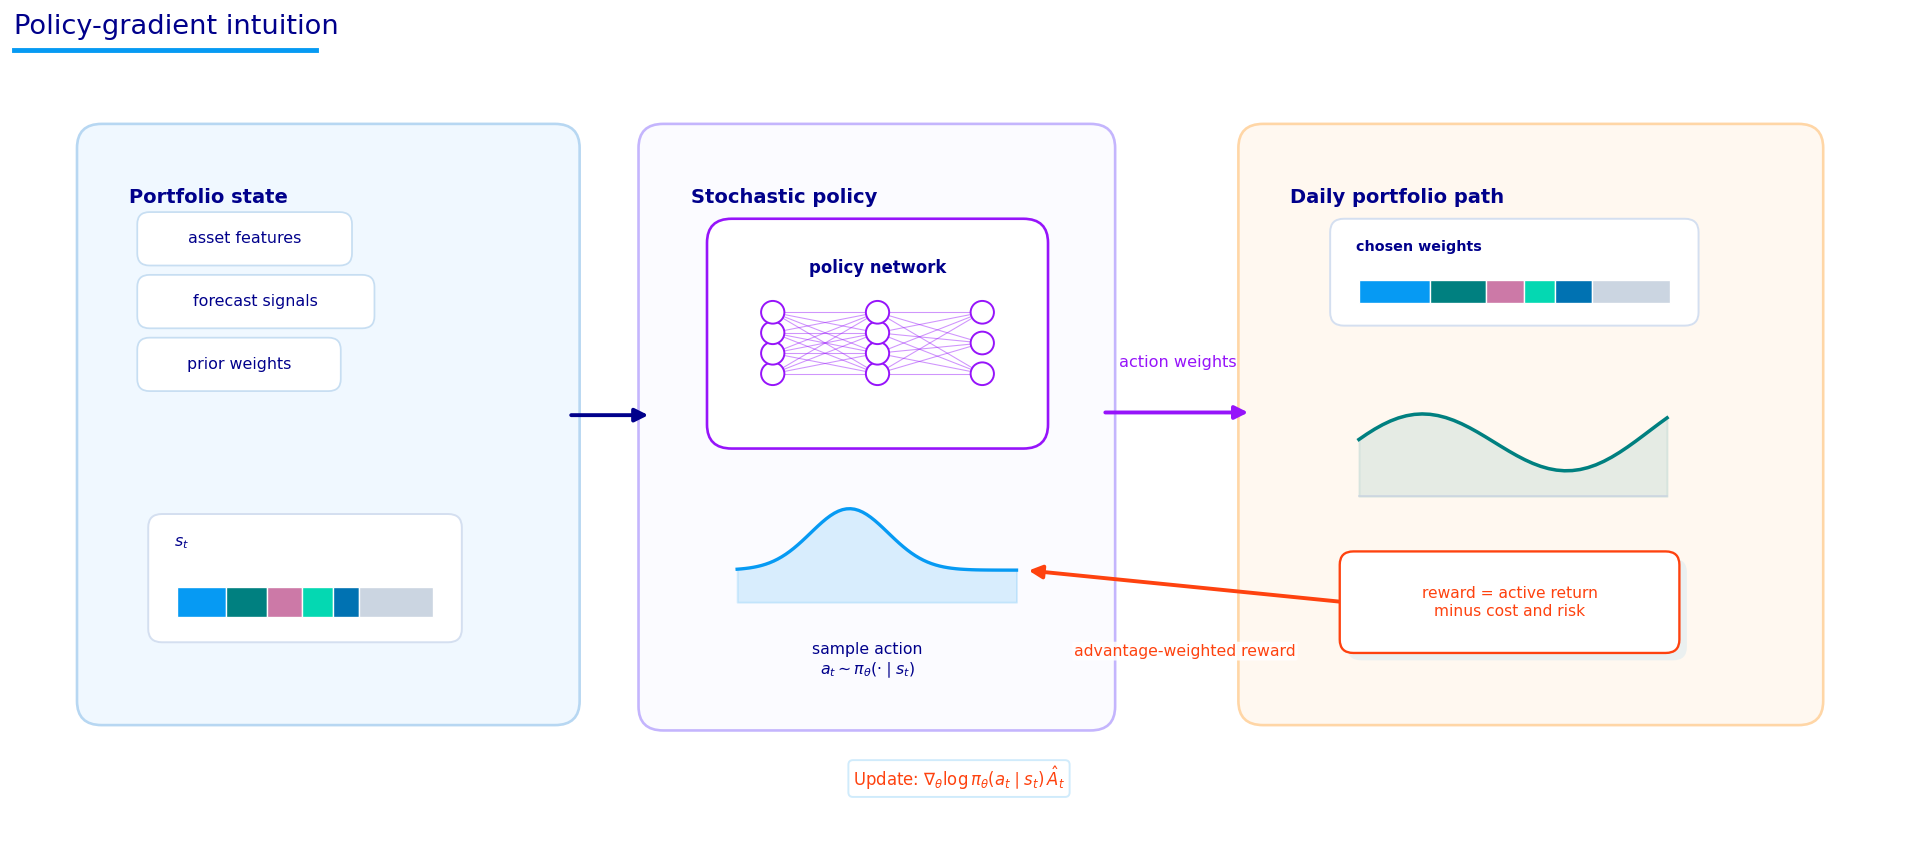

In [22]:
from quantfinlab.plotting.diagrams import policy_gradient_diagram
fig, ax = policy_gradient_diagram()
plt.show()


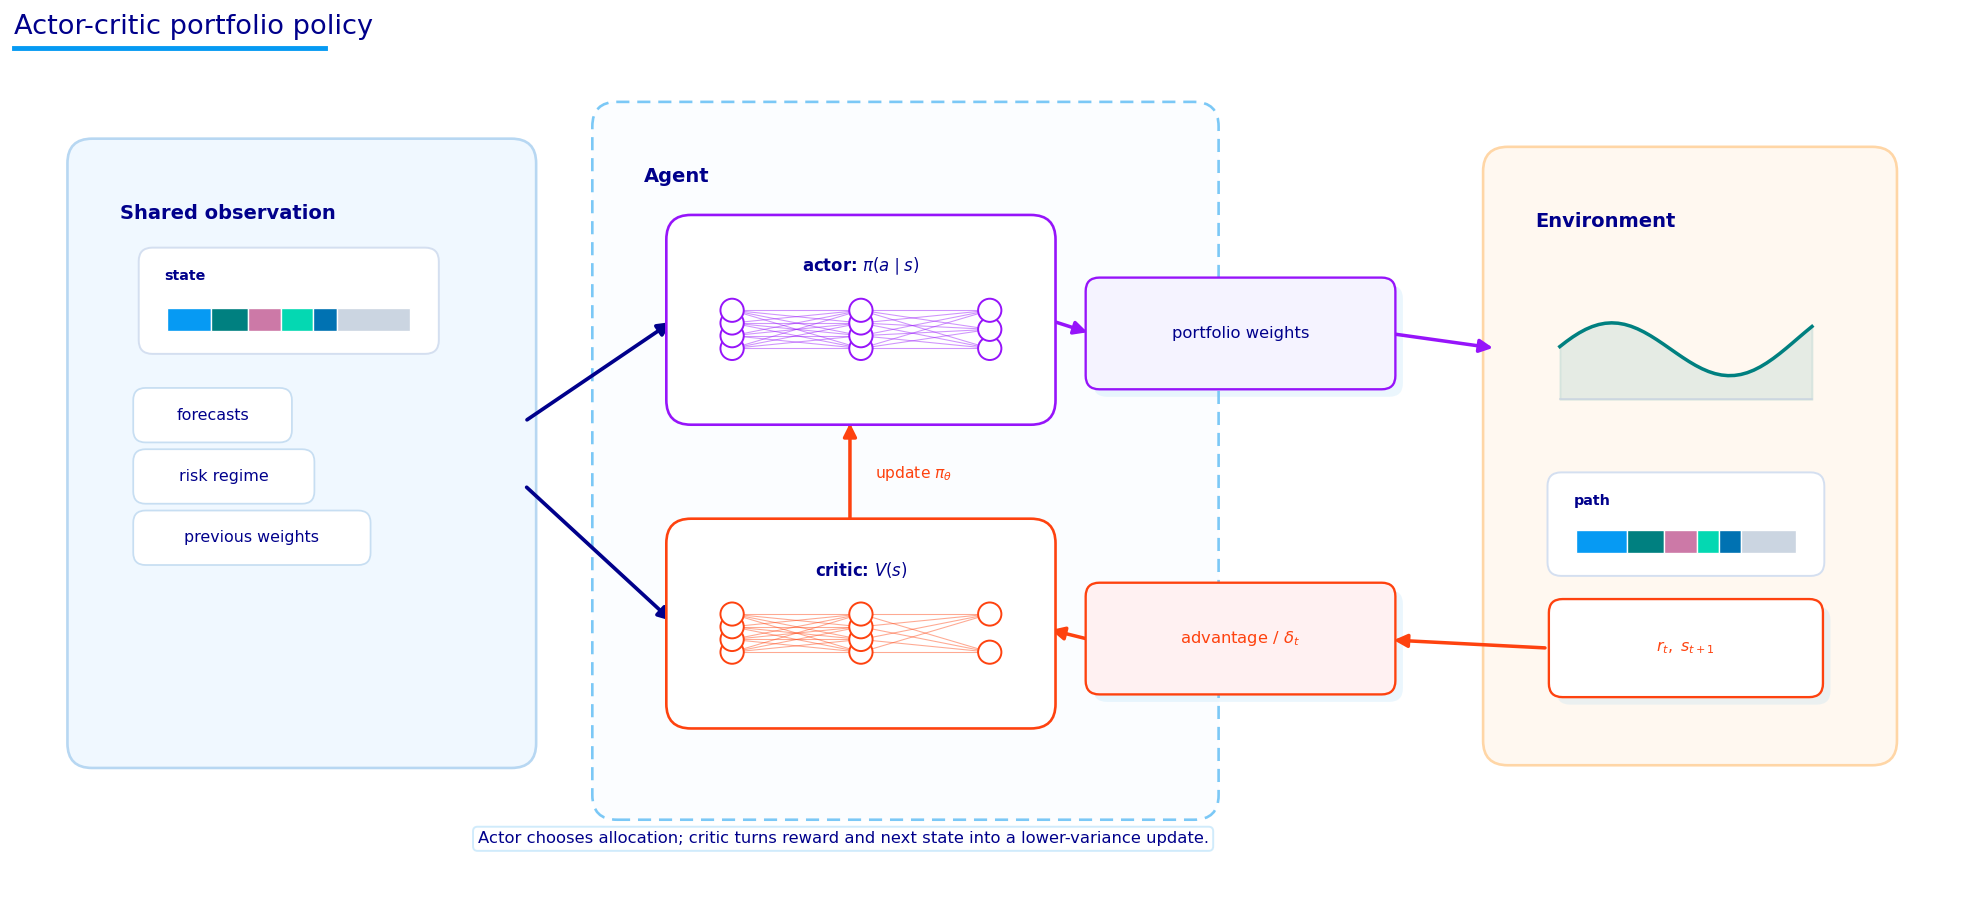

In [23]:
from quantfinlab.plotting.diagrams import actor_critic_diagram
fig, ax = actor_critic_diagram()
plt.show()


The policy-gradient diagram shows this idea visually. The policy samples an action, the environment returns reward, and the advantage estimate tells the policy whether that action should become more or less likely. The actor-critic diagram adds the critic: the actor still chooses the action, but the critic learns a value estimate and gives the actor a lower-variance learning signal.

For portfolio allocation, this division is natural. The actor asks, “what weights should I hold?” The critic asks, “given the current market state and portfolio condition, how valuable is this situation?” If the actor makes a risky allocation in a fragile state and the next reward is poor, the critic helps convert that poor outcome into a parameter update.


### 8.4 Generalized advantage estimation

PPO and recurrent PPO use **generalized advantage estimation**. The one-step TD residual is:

$$
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)
$$

This residual says how surprising the reward plus next-state value was relative to the current value. GAE combines many TD residuals:

$$
\hat{A}^{GAE}_t = \sum_{l=0}^{\infty} (\gamma\lambda)^l \delta_{t+l}
$$

The parameter $\lambda$ controls the bias-variance tradeoff. If $\lambda$ is close to 0, the advantage depends mostly on one-step TD errors. This is lower variance but more biased. If $\lambda$ is close to 1, it uses longer reward information. This is less biased but noisier.

The code uses $\gamma=0.97$ and $\lambda=0.90$. That means the advantage estimate has memory, but it doesn't let very distant rewards dominate. In weekly portfolio data, this is reasonable: the agent should care about multi-week consequences, but not treat rewards one year later as clean feedback about today's action.

GAE smooths the advantage estimate across multiple temporal-difference errors. The one-step TD error is:

$$
\delta_t = R_{t+1} + \gamma V(s_{t+1}) - V(s_t)
$$

If $\delta_t$ is positive, the outcome was better than the critic expected. If it is negative, it was worse. GAE combines these errors over time:

$$
\hat{A}^{GAE}_t = \delta_t + (\gamma\lambda)\delta_{t+1} + (\gamma\lambda)^2\delta_{t+2} + \cdots
$$

The parameter $\lambda$ controls the bias-variance tradeoff. If $\lambda=0$, the advantage is mostly one-step and low-variance but biased toward the critic's current estimate. If $\lambda=1$, it uses longer returns and becomes less biased but noisier. The notebook uses $\lambda=0.90$, which gives the policy several weeks of reward information without making the advantage estimate too noisy.

This is valuable in finance because a good allocation decision may not reveal itself in one week. A move into cash before a drawdown may look unexciting at first, then become valuable later. A move into high beta may look good for a week and then hurt the portfolio two weeks later. GAE helps the policy connect actions with multi-step consequences.


## 9) PPO: Stable On-Policy Policy Optimization

PPO updates the policy using data collected from the current policy. The core problem is that policy gradients can be unstable. If one update changes the policy too much, the data collected under the old policy no longer represents the new policy well.

PPO solves this with a probability ratio:

$$
r_t(\theta) = \frac{\pi_\theta(a_t\mid s_t)}{\pi_{\theta_{old}}(a_t\mid s_t)}
$$

If $r_t(\theta)=1$, the new policy gives the sampled action the same probability as the old policy. If it is larger than 1, the new policy increased the probability of that action. If it is smaller than 1, the new policy decreased it.

The clipped PPO objective is:

$$
L^{CLIP}(\theta) = \mathbb{E}\left[\min\left(r_t(\theta)\hat{A}_t, \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t\right)\right]
$$

The clipping range in the code is 0.8 to 1.2, so $\epsilon=0.2$. This means the policy update is discouraged from changing the probability of sampled actions by more than about 20% in one update.

The full PPO loss also includes a value loss and an entropy bonus:

$$
L(\theta) = L_{policy} + c_v L_{value} - c_e H(\pi_\theta)
$$

The value loss trains the critic. The entropy term keeps the policy from collapsing too early. In portfolio terms, entropy means the raw action distribution stays exploratory during training, instead of immediately committing to one rigid allocation pattern.

### 9.1 PPO objective and clipping behavior

PPO updates the policy using a probability ratio:

$$
r_t(\theta) = \frac{\pi_\theta(a_t\mid s_t)}{\pi_{\theta_{old}}(a_t\mid s_t)}
$$

This ratio says how much more likely the new policy makes the old sampled action. If $r_t=1$, the new policy assigns the same probability as before. If $r_t=1.3$, the new policy makes that action 30% more likely. If $r_t=0.7$, it makes the action 30% less likely.

The clipped PPO objective is:

$$
L^{CLIP}(\theta)=E\left[\min\left(r_t(\theta)\hat{A}_t, \text{clip}(r_t(\theta),1-\epsilon,1+\epsilon)\hat{A}_t\right)\right]
$$

The clipping range is $[0.8,1.2]$ in this notebook. The logic is easy to read case by case:

| Advantage sign | Policy change | PPO behavior |
|---|---|---|
| $\hat{A}_t>0$ | action becomes slightly more likely | good update |
| $\hat{A}_t>0$ | action becomes too much more likely | clipped |
| $\hat{A}_t<0$ | action becomes slightly less likely | good update |
| $\hat{A}_t<0$ | action becomes too much less likely | clipped |

This makes PPO cautious. It can improve the policy, but it shouldn't move too far from the policy that generated the rollout. That is important in finance because the reward signal is noisy. If the policy changes too aggressively after a lucky or unlucky sequence, it can destroy out-of-sample behavior.

The PPO loss in the code combines three pieces:

$$
\mathcal{L}_{PPO} = \mathcal{L}_{policy} + c_v\mathcal{L}_{value} - c_e\mathcal{H}(\pi)
$$

- $\mathcal{L}_{policy}$ is the clipped policy-gradient loss.
- $\mathcal{L}_{value}$ trains the critic to predict returns.
- $\mathcal{H}(\pi)$ is entropy, which keeps the policy from becoming deterministic too early.

The entropy term is especially useful early in training. If the policy collapses immediately into one allocation shape, it stops exploring other possible risk profiles.

### 9.2 On-policy learning and rollout quality

PPO is an on-policy method. It collects a rollout using the current policy, computes advantages, then updates the policy using that same rollout. After the update, old data becomes less useful because it came from an older policy.

This matters in finance because the data sample is already small. On-policy learning can be stable but sample-hungry. Every update depends on the specific states and rewards collected by the current policy. If the rollout period contains an unusual market pattern, the update can be biased toward that pattern. PPO clipping reduces the damage by limiting how far the policy can move.

The rollout object in this notebook stores:

- states,
- actions,
- log-probabilities under the old policy,
- rewards,
- done flags,
- value estimates,
- resulting weights,
- reward components.

The old log-probabilities are essential because PPO compares old and new policy probabilities through $r_t(\theta)$. Without them, we couldn't compute the clipped objective.


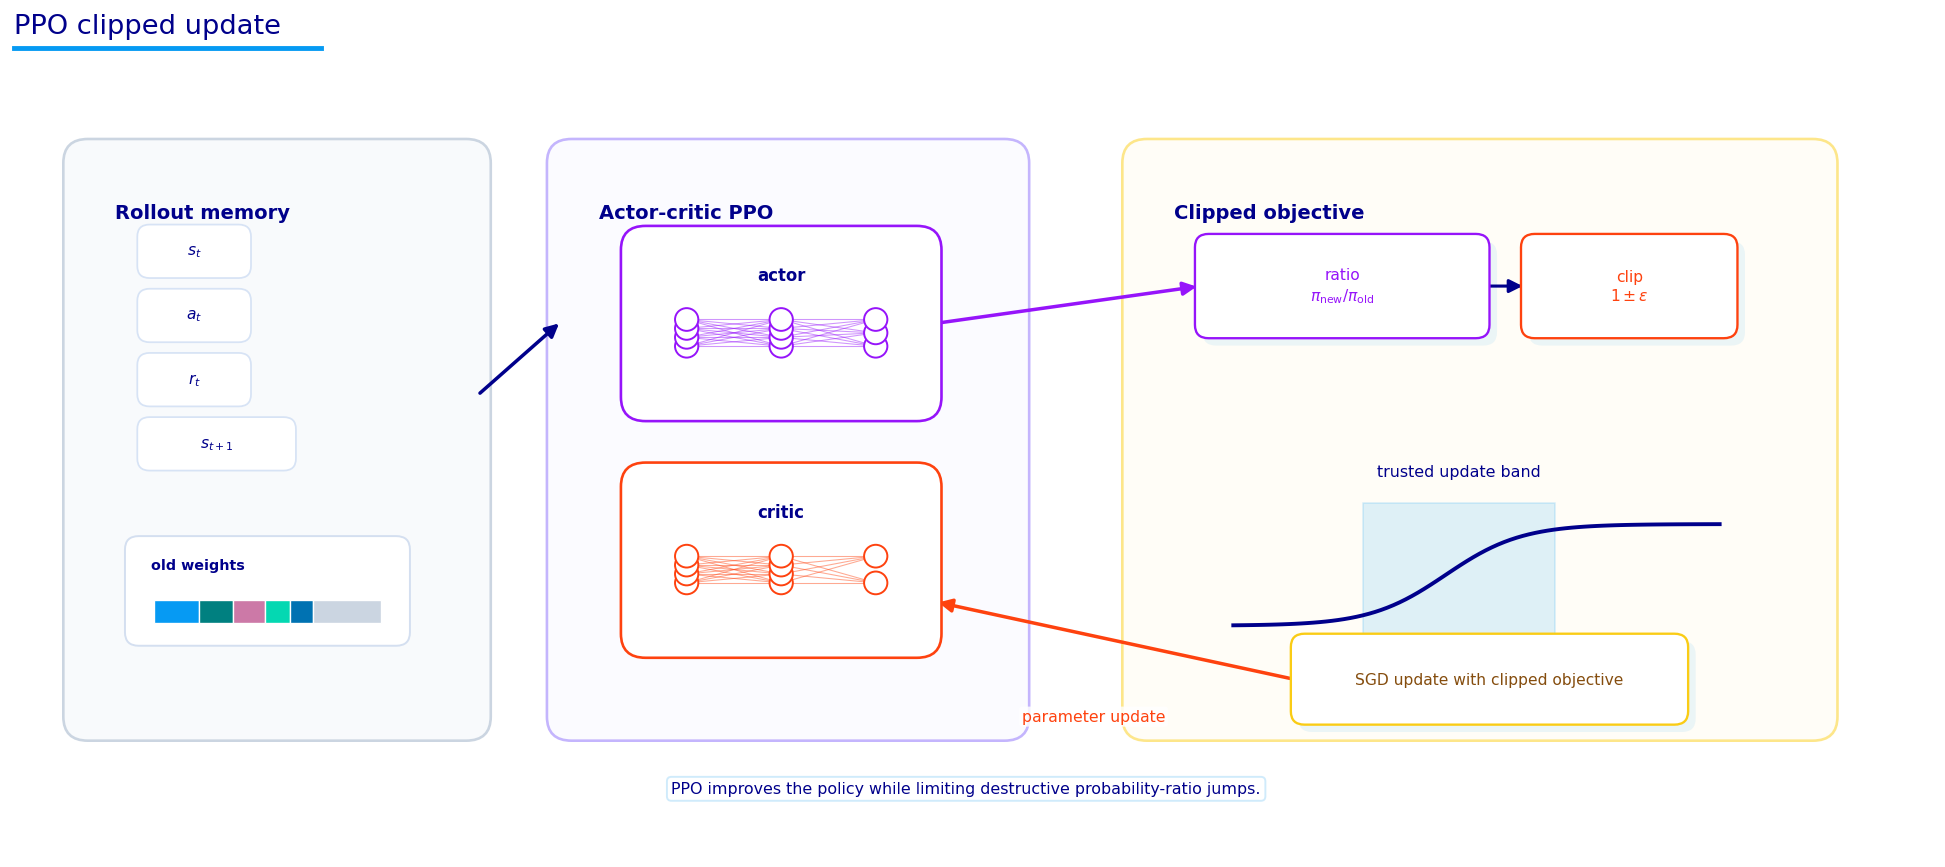

In [24]:
from quantfinlab.plotting.diagrams import ppo_diagram
fig, ax = ppo_diagram()
plt.show()


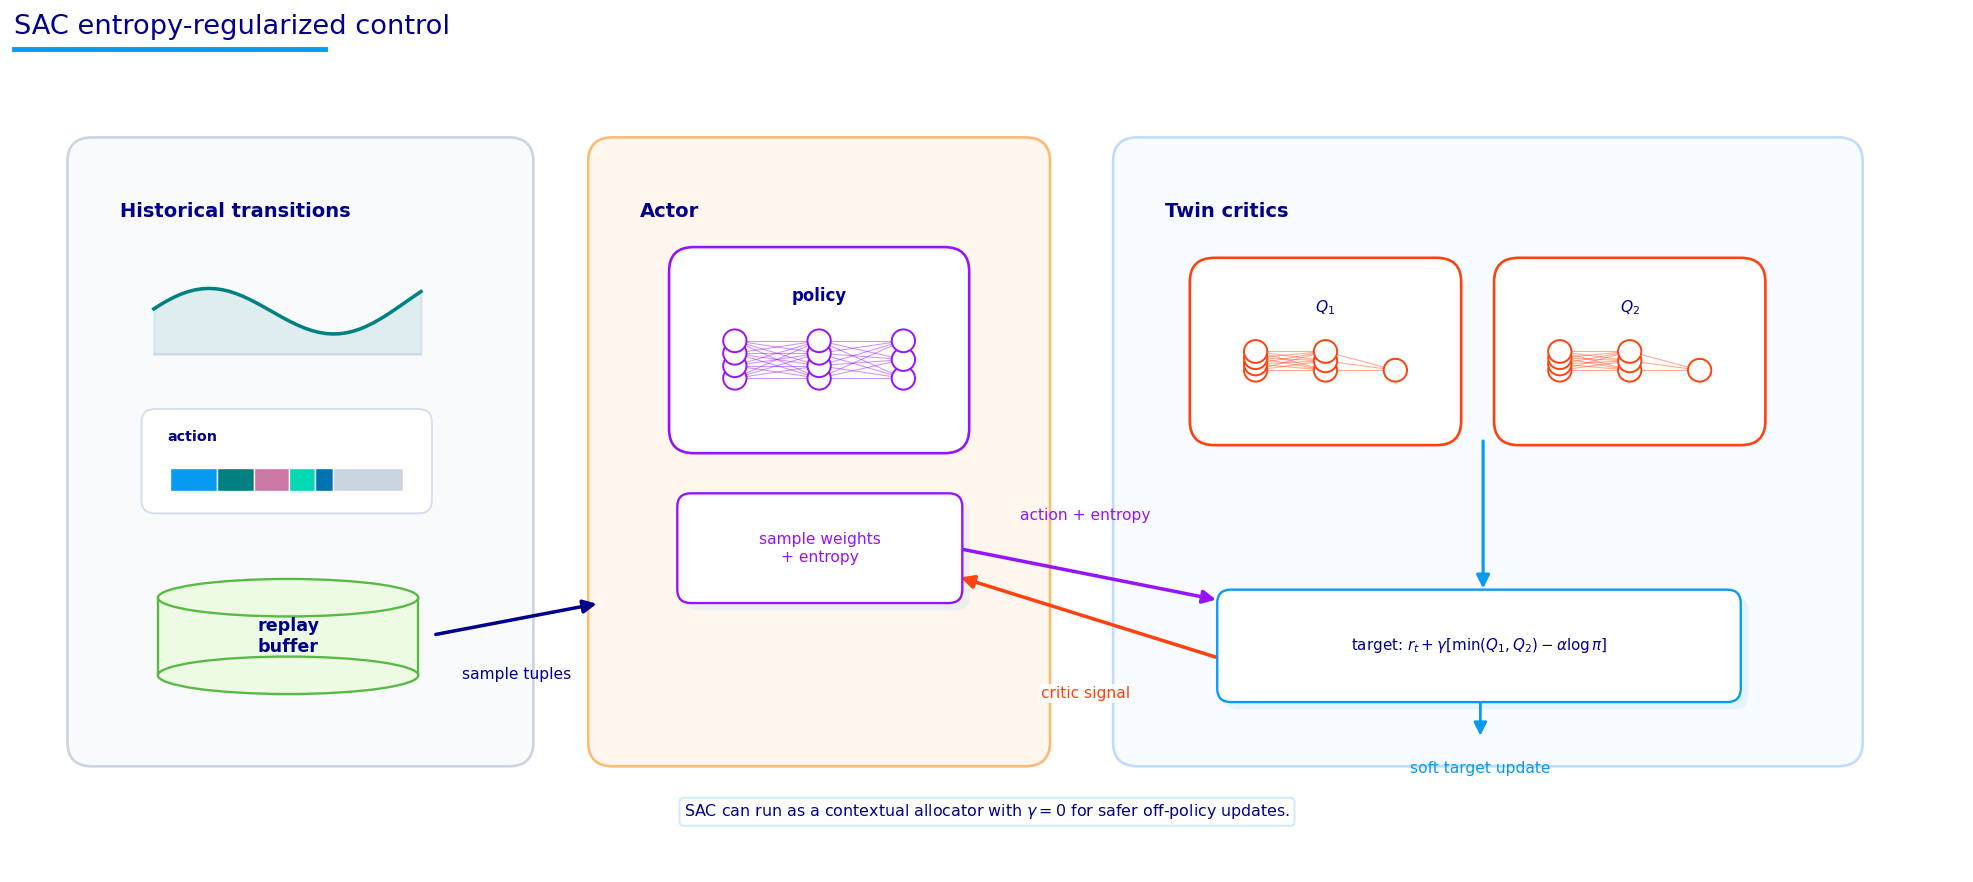

In [25]:
from quantfinlab.plotting.diagrams import sac_diagram
fig, ax = sac_diagram()
plt.show()


### 9.3 Cross-asset policy architecture

The PPO policy starts with a cross-asset encoder. This is a neural architecture designed for a portfolio universe, not for a single time series.

For each decision date, the asset features form:

$$
X_t \in \mathbb{R}^{N\times F_a}
$$

The encoder maps every asset row into a hidden vector:

$$
h_{i,t} = f_\theta(x_{i,t})
$$

Then multi-head attention lets assets interact with each other. Attention creates a context-aware asset representation:

$$
\tilde{h}_{i,t} = \text{Attention}(h_{i,t}, H_t)
$$

where $H_t$ is the matrix of all asset embeddings. Financially, this matters because asset allocation is cross-sectional. The attractiveness of QQQ doesn't only depend on QQQ features; it also depends on whether SPY, IWM, HYG, GLD, and SHY look better or worse at the same time.

The model also encodes global features and portfolio features:

$$
g_t = f_g(X^{global}_t)
$$

$$
p_t = f_p(X^{portfolio}_t)
$$

The final fused representation is:

$$
z_t = [c_t, g_t, p_t]
$$

where $c_t$ is the pooled cross-asset context. The policy has one head for risky-asset logits, one head for total exposure, and one value head for the critic.

The policy also has an alpha boost term. If the forecast feature index is available, the asset logits get an extra learned multiple of the forecast rank signal. This means the neural policy can learn to lean into the forecast signal instead of rediscovering it from scratch.

The cross-asset actor-critic architecture is designed around the input structure. The asset encoder reads the $N\times F_a$ asset matrix. A multi-head attention block lets assets interact with each other. This matters because allocation is relative. The model should be able to learn that SPY's signal is strong only relative to QQQ, HYG's signal is risky when LQD is weak, or GLD becomes useful when equity and bond features are both stressed.

The attention step can be summarized as:

$$
\text{Attention}(Q,K,V)=\text{softmax}\left(\frac{QK^\top}{\sqrt{d}}\right)V
$$

Here:

- $Q$ are queries, asking what each asset wants to compare,
- $K$ are keys, describing what information each asset offers,
- $V$ are values, carrying the transformed asset information,
- $d$ scales the dot products so attention scores don't explode.

In this project, attention is not used as a huge transformer. It is a compact way to let asset rows exchange information before the policy forms allocation scores.

The global encoder processes macro/regime/market features. The portfolio encoder processes previous portfolio context. These three streams are combined into one representation:

$$
z_t = [z^{asset}_t, z^{global}_t, z^{portfolio}_t]
$$

The actor head maps this representation to action means. The critic head maps it to a value estimate. The same encoded information therefore supports both decisions and value learning.


In [26]:
import torch.nn as nn
from torch.distributions import Normal

class CrossAssetEncoder(nn.Module):
    def __init__(self, n_asset_features, n_global_features, n_assets, hidden_size=96, heads=4):
        super().__init__()
        self.n_assets = n_assets
        self.n_portfolio_features = n_assets + 5
        self.asset_encoder = nn.Sequential(nn.LayerNorm(n_asset_features), nn.Linear(n_asset_features, hidden_size), nn.SiLU(), nn.Linear(hidden_size, hidden_size), nn.SiLU())
        self.attn = nn.MultiheadAttention(hidden_size, heads, batch_first=True)
        self.asset_norm = nn.LayerNorm(hidden_size)
        self.pool_score = nn.Linear(hidden_size, 1)
        self.global_encoder = nn.Sequential(nn.LayerNorm(n_global_features), nn.Linear(n_global_features, hidden_size), nn.SiLU(), nn.Linear(hidden_size, hidden_size), nn.SiLU())
        self.port_encoder = nn.Sequential(nn.LayerNorm(self.n_portfolio_features), nn.Linear(self.n_portfolio_features, hidden_size), nn.SiLU(), nn.Linear(hidden_size, hidden_size), nn.SiLU())
        self.output_dim = 3 * hidden_size
        self.asset_score_dim = 4 * hidden_size
        self.hidden_size = hidden_size
    def encode(self, ax, gx, px):
        a = self.asset_encoder(ax.float())
        attn, _ = self.attn(a, a, a, need_weights=False)
        h_asset = self.asset_norm(a + attn)
        pool_w = torch.softmax(self.pool_score(h_asset).squeeze(-1), dim=-1)
        context = (h_asset * pool_w.unsqueeze(-1)).sum(dim=1)
        global_h = self.global_encoder(gx.float())
        port_h = self.port_encoder(px.float())
        fused = torch.cat([context, global_h, port_h], dim=-1)
        return h_asset, context, global_h, port_h, fused
    def forward(self, ax, gx, px):
        return self.encode(ax, gx, px)[-1]

class PpoActorCritic(nn.Module):
    def __init__(self, n_asset_features, n_global_features, n_assets, hidden_size=96, alpha_index=None):
        super().__init__()
        self.n_assets = n_assets
        self.alpha_index = alpha_index
        self.alpha_gain = nn.Parameter(torch.tensor(4.0)) if alpha_index is not None else None
        self.encoder = CrossAssetEncoder(n_asset_features, n_global_features, n_assets, hidden_size=hidden_size)
        self.score_head = nn.Sequential(nn.LayerNorm(self.encoder.asset_score_dim), nn.Linear(self.encoder.asset_score_dim, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
        self.exposure_head = nn.Sequential(nn.LayerNorm(self.encoder.output_dim), nn.Linear(self.encoder.output_dim, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
        self.log_std = nn.Parameter(torch.full((n_assets + 1,), -0.65))
        self.value = nn.Sequential(nn.LayerNorm(self.encoder.output_dim), nn.Linear(self.encoder.output_dim, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
    def action_mean(self, ax, gx, px):
        h_asset, context, global_h, port_h, fused = self.encoder.encode(ax, gx, px)
        n = h_asset.shape[1]
        score_x = torch.cat([
            h_asset,
            context.unsqueeze(1).expand(-1, n, -1),
            global_h.unsqueeze(1).expand(-1, n, -1),
            port_h.unsqueeze(1).expand(-1, n, -1),
        ], dim=-1)
        risky_logits = self.score_head(score_x).squeeze(-1)
        if self.alpha_index is not None:
            risky_logits = risky_logits + self.alpha_gain * ax.float()[..., self.alpha_index]
        exposure_logit = self.exposure_head(fused).squeeze(-1)
        return torch.cat([risky_logits, exposure_logit.unsqueeze(-1)], dim=-1), fused
    def distribution(self, ax, gx, px):
        mean, z = self.action_mean(ax, gx, px)
        std = torch.exp(self.log_std).clamp(0.05, 2.0).expand_as(mean)
        return Normal(mean, std), self.value(z).squeeze(-1)
    def act(self, ax, gx, px, deterministic=False):
        dist, value = self.distribution(ax, gx, px)
        action = dist.mean if deterministic else dist.sample()
        log_prob = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        weights = action_to_weights(action, reward_settings["min_exposure"], reward_settings["max_exposure"], reward_settings["max_weight"])
        return action, log_prob, entropy, value, weights
    def evaluate_actions(self, ax, gx, px, action):
        dist, value = self.distribution(ax, gx, px)
        return dist.log_prob(action).sum(-1), dist.entropy().sum(-1), value


In [27]:
def collect_policy_rollout(model, indices, deterministic=False):
    model.to(device)
    w_prev = np.zeros(len(state_columns), dtype=float)
    nav = peak = 1.0
    prev_turnover = 0.0
    returns_hist, daily_returns_hist = [], []
    dsr_state = DifferentialSharpe(reward_settings["dsr_eta"])
    ew_daily_hist = []
    rows = {k: [] for k in ["asset", "global", "portfolio", "action", "log_prob", "entropy", "value", "reward", "return", "daily_returns", "weights", "date", "components"]}
    for t in indices:
        ax_np, gx_np, px_np = inputs_for_step(t, w_prev, nav, peak, returns_hist, prev_turnover, daily_returns_hist)
        ax_t = torch.tensor(ax_np[None], dtype=torch.float32, device=device)
        gx_t = torch.tensor(gx_np[None], dtype=torch.float32, device=device)
        px_t = torch.tensor(px_np[None], dtype=torch.float32, device=device)
        with torch.no_grad():
            action, logp, entropy, value, w_t = model.act(ax_t, gx_t, px_t, deterministic=deterministic)
        w_new, port_ret, turnover, cost, w_end, nav, peak, comps, daily_net, equal_daily = environment_step(t, action.detach().cpu().numpy().reshape(-1), w_prev, nav, peak, daily_returns_hist, ew_daily_hist, dsr_state, reward_settings)
        for key, val in [
            ("asset", ax_np), ("global", gx_np), ("portfolio", px_np), ("action", action.detach().cpu().numpy().reshape(-1)),
            ("log_prob", float(logp.detach().cpu())), ("entropy", float(entropy.detach().cpu())), ("value", float(value.detach().cpu())),
            ("reward", comps["reward"]), ("return", port_ret), ("daily_returns", daily_net), ("weights", w_new), ("date", state_dates[t]), ("components", comps)
        ]:
            rows[key].append(val)
        returns_hist.append(port_ret)
        daily_returns_hist.extend([float(x) for x in daily_net])
        ew_daily_hist.extend([float(x) for x in equal_daily])
        prev_turnover = turnover
        w_prev = w_end
    return rows

def gae(rewards, values, gamma=0.97, lam=0.90):
    rewards = np.asarray(rewards, dtype=np.float32)
    values = np.asarray(values, dtype=np.float32)
    adv = np.zeros_like(rewards)
    last = 0.0
    for i in range(len(rewards) - 1, -1, -1):
        next_value = values[i + 1] if i + 1 < len(values) else 0.0
        delta = rewards[i] + gamma * next_value - values[i]
        last = delta + gamma * lam * last
        adv[i] = last
    return adv, adv + values

def validation_stats_from_rollout(rows):
    if "daily_returns" in rows and rows["daily_returns"]:
        daily = np.concatenate([np.asarray(x, dtype=float).reshape(-1) for x in rows["daily_returns"]])
        r = pd.Series(daily)
        nav = (1.0 + r).cumprod()
        vol = r.std(ddof=1) * np.sqrt(252.0)
        sharpe = ((r - rf_daily).mean() / r.std(ddof=1) * np.sqrt(252.0)) if r.std(ddof=1) > 0 else np.nan
    else:
        r = pd.Series(rows["return"], index=pd.DatetimeIndex(rows["date"]))
        nav = (1 + r).cumprod()
        vol = r.std(ddof=1) * np.sqrt(52.0)
        rf_week = (1.0 + rf_daily) ** 5 - 1.0
        sharpe = ((r - rf_week).mean() / r.std(ddof=1) * np.sqrt(52.0)) if r.std(ddof=1) > 0 else np.nan
    return {"total_reward": float(np.sum(rows["reward"])), "mean_reward": float(np.mean(rows["reward"])), "return": float(nav.iloc[-1] - 1), "vol": float(vol), "sharpe": float(sharpe), "max_drawdown": float((nav / nav.cummax() - 1).min()), "avg_exposure": float(np.mean([w[:-1].sum() for w in rows["weights"]]))}

def train_ppo_model(model, model_path, epochs=80, rollout_length=96, lr=3e-4, entropy_weight=0.005):
    model.to(device)
    if model_path.exists():
        try:
            model.load_state_dict(torch.load(model_path, map_location=device))
            rows = collect_policy_rollout(model, valid_idx, deterministic=True)
            return pd.DataFrame(), validation_stats_from_rollout(rows)
        except Exception as exc:
            print(f"Retraining PPO because checkpoint is incompatible: {exc}")
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    history = []
    best_score, best_state = -np.inf, None
    for epoch in range(1, epochs + 1):
        if len(train_idx) > rollout_length:
            start = int(np.random.randint(0, max(1, len(train_idx) // 5))) if np.random.rand() < 0.4 else int(np.random.randint(0, max(1, len(train_idx) - rollout_length)))
            idx = train_idx[start:start + rollout_length]
        else:
            idx = train_idx
        rows = collect_policy_rollout(model, idx, deterministic=False)
        adv, ret = gae(rows["reward"], rows["value"])
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        ax_t = torch.tensor(np.asarray(rows["asset"]), dtype=torch.float32, device=device)
        gx_t = torch.tensor(np.asarray(rows["global"]), dtype=torch.float32, device=device)
        px_t = torch.tensor(np.asarray(rows["portfolio"]), dtype=torch.float32, device=device)
        act_t = torch.tensor(np.asarray(rows["action"]), dtype=torch.float32, device=device)
        old_log = torch.tensor(np.asarray(rows["log_prob"]), dtype=torch.float32, device=device)
        adv_t = torch.tensor(adv, dtype=torch.float32, device=device)
        ret_t = torch.tensor(ret, dtype=torch.float32, device=device)
        for _ in range(5):
            logp, entropy, value = model.evaluate_actions(ax_t, gx_t, px_t, act_t)
            ratio = torch.exp(logp - old_log)
            loss_pi = -torch.min(ratio * adv_t, torch.clamp(ratio, 0.8, 1.2) * adv_t).mean()
            loss_v = torch.nn.functional.mse_loss(value, ret_t)
            loss = loss_pi + 0.5 * loss_v - entropy_weight * entropy.mean()
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            opt.step()
        valid_rows = collect_policy_rollout(model, valid_idx, deterministic=True) if epoch % max(1, epochs // 10) == 0 or epoch == epochs else None
        valid_reward = np.nan
        valid_sharpe = np.nan
        if valid_rows is not None:
            stats = validation_stats_from_rollout(valid_rows)
            valid_reward = stats["total_reward"]
            valid_sharpe = stats["sharpe"]
            score = valid_sharpe if np.isfinite(valid_sharpe) else valid_reward
            if score > best_score:
                best_score = score
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        history.append({"epoch": epoch, "train_reward": np.sum(rows["reward"]), "policy_loss": float(loss_pi.detach().cpu()), "value_loss": float(loss_v.detach().cpu()), "entropy": float(entropy.mean().detach().cpu()), "avg_exposure": np.mean([w[:-1].sum() for w in rows["weights"]]), "validation_reward": valid_reward, "validation_sharpe": valid_sharpe})
    if best_state is not None:
        model.load_state_dict(best_state)
    model_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), model_path)
    return pd.DataFrame(history), validation_stats_from_rollout(collect_policy_rollout(model, valid_idx, deterministic=True))


In [28]:
alpha_index = asset_feature_names.index("z_blend_volscaled") if "z_blend_volscaled" in asset_feature_names else None
ppo = PpoActorCritic(asset_state.shape[2], global_state.shape[1], len(assets), hidden_size=128, alpha_index=alpha_index)
ppo_history, ppo_validation = train_ppo_model(
    ppo,
    model_dir / "ppo_dsr.pt",
    epochs=ppo_epochs_main,
    rollout_length=96,
    lr=3e-4,
    entropy_weight=0.006,
)
display(pd.Series(ppo_validation).to_frame("PPO").round(4))


,PPO
total_reward,92.5246
mean_reward,0.8897
return,0.0815
vol,0.0779
sharpe,0.0415
max_drawdown,-0.1154
avg_exposure,0.7998


The PPO implementation collects rollouts, computes GAE advantages, standardizes the advantages, and updates the policy using the clipped objective. The validation step is deterministic: it uses the mean action, not random sampling. That is how we test the learned policy as an actual portfolio rule.

The PPO validation table shows:

- total reward: **92.52**,
- mean reward: **0.8897**,
- return: **8.15%** over the validation window,
- volatility: **7.79%**,
- Sharpe: **0.0415** under the validation calculation,
- max drawdown: **-11.54%**,
- average risky exposure: **79.98%**.

The reward is strong because the policy learned to respect the reward design, not because its validation Sharpe is high. This is a useful warning: reward and conventional performance metrics can disagree. In RL portfolio work, a policy can learn the shaped reward very well while still being mediocre on CAGR or Sharpe.


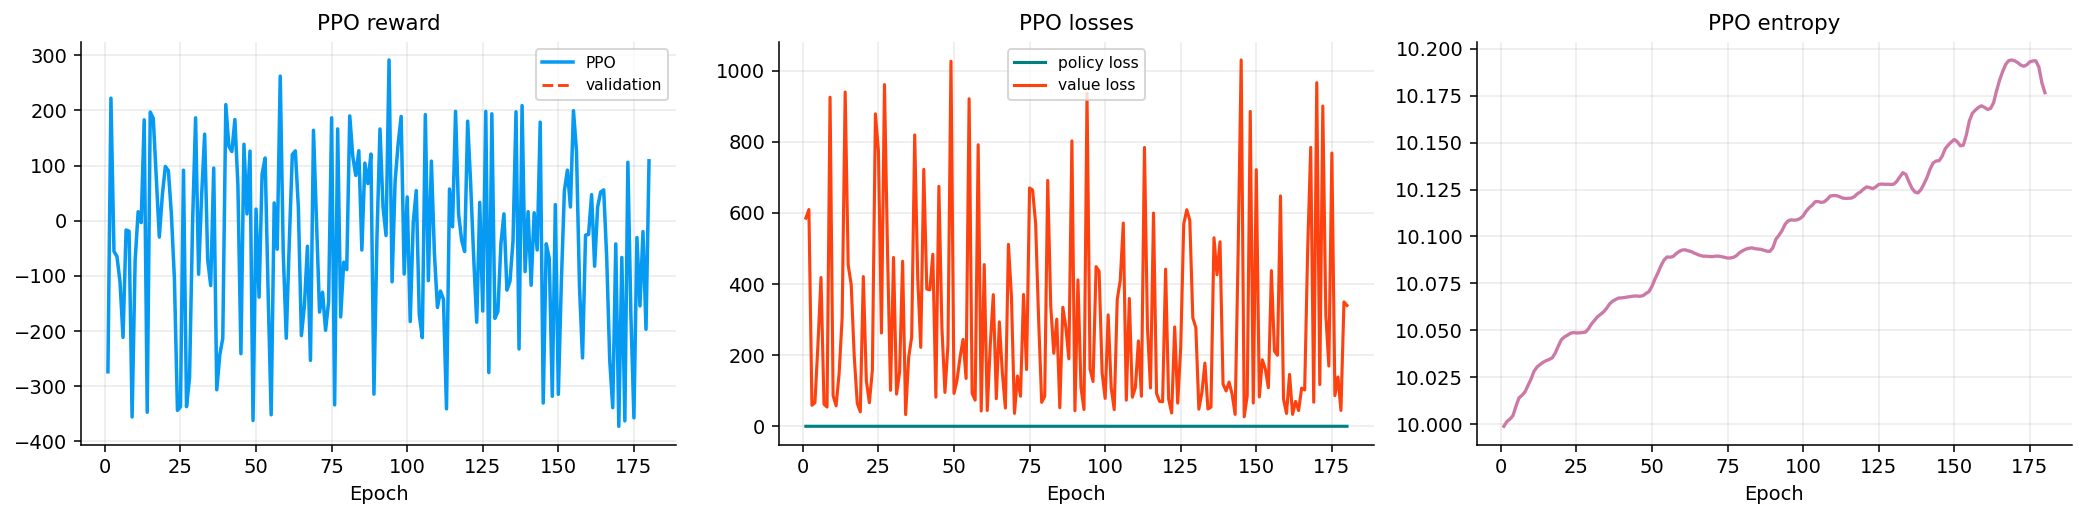

In [29]:
from quantfinlab.plotting.ml import policy_entropy_curve, ppo_loss_curves, training_reward_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
training_reward_curve(axes[0], ppo_history, label="PPO", title="PPO reward")
ppo_loss_curves(axes[1], ppo_history, title="PPO losses")
policy_entropy_curve(axes[2], ppo_history, title="PPO entropy")
plt.tight_layout()
plt.show()


,mean,std,min,max
SPY,0.1877,0.0489,0.0490,0.2572
QQQ,0.1089,0.0481,0.0333,0.2450
IWM,0.1208,0.0622,0.0171,0.2582
EFA,0.0829,0.0576,0.0097,0.2546
EEM,0.0383,0.0192,0.0093,0.1010
VNQ,0.0446,0.0507,0.0062,0.2350
DBC,0.0467,0.0372,0.0048,0.1649
GLD,0.0167,0.0190,0.0037,0.1303
IEF,0.0061,0.0032,0.0040,0.0236
TLT,0.0226,0.0305,0.0046,0.1711


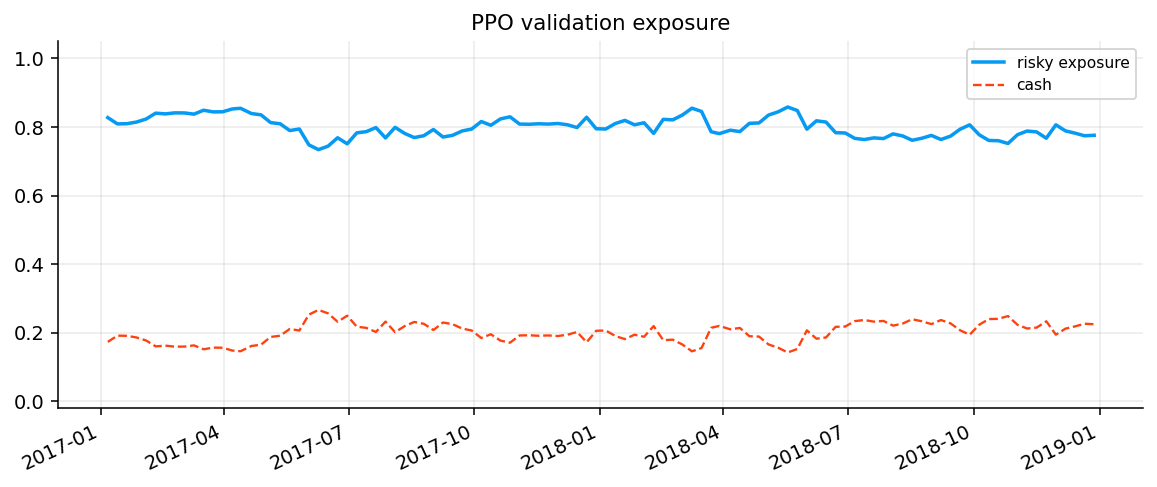

In [30]:
ppo_valid_rows = collect_policy_rollout(ppo, valid_idx, deterministic=True)
w_ppo_valid = pd.DataFrame(ppo_valid_rows["weights"], index=pd.DatetimeIndex(ppo_valid_rows["date"]), columns=state_columns)
display(w_ppo_valid.describe().T[["mean", "std", "min", "max"]].round(4))
fig, ax = plt.subplots(figsize=(10, 3.4))
policy_exposure_path(ax, w_ppo_valid, cash_ticker=cash_ticker, title="PPO validation exposure")
plt.show()


The training curves should be read as diagnostics rather than proof of success. A rising training reward is good, but it can reflect overfitting to the training market path. Validation exposure and validation reward are more informative. In the output, PPO finds a controlled allocation with moderate cash and diversified risky weights. That is stable behavior, but the final test comparison shows that stability alone doesn't beat the stronger supervised portfolio baselines.


The validation result for PPO shows a positive total reward and controlled volatility around 7.8%, but the Sharpe is only slightly positive in the validation table. The policy average exposure is around 80%, and the weight summary shows meaningful cash around 20%. PPO learns a conservative policy with diversified risky weights, but it doesn't look like it dominates the stronger rule-based forecast models.

### Reading PPO training outputs

The PPO training plot usually contains reward and loss-style curves. These are useful, but they should be interpreted carefully.

A rising training reward means the policy is learning to score better inside the training environment. It doesn't automatically mean the policy will perform better out of sample. The validation table is more important because it uses a separate period. The test-period strategy comparison is more important still.

The value loss tells us how well the critic is fitting return targets. If value loss is too high, the advantage estimates become unreliable. If it is too low too quickly, the critic may be overfitting the training path. The entropy curve tells us whether the policy is still exploring. If entropy collapses early, the policy may become deterministic before it has learned enough.

For this project, the practical PPO diagnostic is the validation exposure plot. PPO doesn't become extremely aggressive. It keeps a meaningful SHY position and spreads risk across several assets. That behavior is consistent with the reward: cost, concentration, drawdown, and volatility penalties push the policy away from extreme allocations.

The limitation is that PPO's caution also reduces upside. A policy can avoid many mistakes and still fail to beat a strong forecast-gated strategy if it doesn't take enough profitable risk when conditions are favorable.

### Neural-network outputs and portfolio interpretation

The PPO actor has two important output concepts: allocation scores and exposure. The risky scores decide the relative risky allocation. The exposure score decides how much of the portfolio goes into the risky sleeve versus SHY.

This creates a two-level allocation decision:

$$
\text{policy state} \rightarrow \begin{cases}
\text{relative risky weights} \\
\text{total risky exposure}
\end{cases}
$$

That structure is better than asking the network to output 13 unrelated weights. It matches portfolio thinking. A manager often first decides the risk budget, then decides which assets deserve that risk. For example, in a defensive environment the policy may reduce total risky exposure. Inside the remaining risky sleeve, it may still prefer GLD, IEF, or defensive equity exposure. In a risk-on environment, the policy may raise total exposure and tilt toward SPY, QQQ, HYG, or IWM.

The value head has a different job. It doesn't choose weights. It estimates how good the current state is under the current policy. When the critic says the state is valuable but the realized reward disappoints, the advantage becomes negative. When the realized reward exceeds the critic's expectation, the advantage becomes positive. This is how the model learns from surprise.

The architecture therefore separates three tasks cleanly:

- encode asset-level relative information,
- encode global market context,
- encode previous portfolio state,
- produce a stochastic action distribution,
- estimate state value for advantage learning.

This separation helps the reader understand why the code has encoders, actor heads, exposure heads, log-standard-deviation parameters, and value heads. They aren't arbitrary neural-network pieces. Each one corresponds to a part of the portfolio-control problem.


The PPO training plot shows noisy training rewards, noisy policy/value losses, and a gradual change in entropy. That is normal for on-policy RL with a small financial sample. The policy is learning from a single sequence of weekly market transitions, so the reward path is much more unstable than the loss curve of a supervised regression model.

The PPO validation exposure plot shows the policy staying mostly around **75% to 85% risky exposure**, with cash around **15% to 25%**. This is consistent with the validation weight table. PPO gives the largest average allocations to SPY, SHY, IWM, QQQ, and HYG. It gives very small weights to IEF and GLD on average, which means it doesn't behave like a defensive bond/gold allocator. It behaves more like a diversified risky policy with a cash buffer.


## 10) Recurrent PPO and Memory

Feedforward PPO receives one state vector at a time. Recurrent PPO adds memory. The policy keeps an internal hidden state that updates as observations arrive:

$$
h_t = \text{LSTM}_\theta(z_t, h_{t-1})
$$

The LSTM was already covered in the forecasting project, so here the important point is its RL role. The policy isn't forecasting an asset return sequence. It is carrying a memory of the market-control sequence: previous states, previous actions, and the reward environment implied by them.

The recurrent policy still outputs a Gaussian raw action distribution, but the mean depends on the memory:

$$
\mu_t = f_\theta(X^{asset}_t, X^{global}_t, X^{portfolio}_t, h_t)
$$

This can help in partial observability. For example, a single state might show moderate volatility, but the last several states may show volatility rising week by week. A recurrent policy can remember that path. In finance, the path often matters because regimes evolve through sequences, not isolated observations.

The recurrent PPO training code evaluates sequence actions in chunks. It computes GAE inside subsequences and applies the same clipped PPO objective as the feedforward model:

$$
L^{RPPO}_{policy} = -\mathbb{E}\left[\min\left(r_t\hat{A}_t, \text{clip}(r_t,0.8,1.2)\hat{A}_t\right)\right]
$$

The difference is not the PPO loss. The difference is the policy representation. Recurrent PPO can make the same observed state lead to different actions depending on the hidden memory.

### 10.1 Sequence memory and recurrent state

Recurrent PPO adds memory through an LSTM. This is useful because the current state vector may not fully capture the market path. The LSTM processes a sequence of observations and carries a hidden state:

$$
h_t, c_t = \text{LSTM}_\theta(x_t, h_{t-1}, c_{t-1})
$$

The two internal objects have different roles:

- $h_t$ is the hidden state passed to the policy head,
- $c_t$ is the cell state that stores longer-term information.

The LSTM gates decide what to keep, forget, and output. A simplified view is:

$$
f_t = \sigma(W_f[x_t,h_{t-1}] + b_f)
$$

$$
i_t = \sigma(W_i[x_t,h_{t-1}] + b_i)
$$

$$
o_t = \sigma(W_o[x_t,h_{t-1}] + b_o)
$$

The forget gate $f_t$ controls how much old memory survives. The input gate $i_t$ controls how much new information enters memory. The output gate $o_t$ controls how much of the memory is exposed to the policy. This gating structure is why an LSTM can remember more than a simple RNN.

For portfolio allocation, memory can represent patterns like:

- volatility rising for several weeks,
- equity breadth deteriorating gradually,
- forecasts staying positive but realized returns weakening,
- credit spreads improving persistently,
- repeated failed attempts to rotate into risk assets.


### 10.2 Truncated backpropagation through time

Training a recurrent policy requires backpropagating through sequences. If we backpropagated through the entire 949-week history at once, training would be unstable and memory-heavy. Instead we train on chunks of fixed sequence length. This is called truncated backpropagation through time.

Let the recurrent policy process a sequence:

$$
x_{t-L+1}, x_{t-L+2}, \ldots, x_t
$$

The LSTM updates hidden memory step by step:

$$
h_{k},c_{k}=f_\theta(x_k,h_{k-1},c_{k-1})
$$

The policy loss is computed across the sequence, but gradients are only propagated across that training chunk. This gives the model enough history to learn persistent regimes without making training too expensive.

In this notebook the recurrent policy uses a sequence length of 52 weeks. That is roughly one year of weekly decisions. This is a sensible horizon for macro and allocation regimes: long enough to observe slow deterioration or recovery, short enough to keep training manageable.


In [31]:
class RecurrentPpoActorCritic(nn.Module):
    def __init__(self, n_asset_features, n_global_features, n_assets, hidden_size=96, recurrent_size=80, alpha_index=None):
        super().__init__()
        self.n_assets = n_assets
        self.sequence_length = 52
        self.alpha_index = alpha_index
        self.alpha_gain = nn.Parameter(torch.tensor(4.0)) if alpha_index is not None else None
        self.encoder = CrossAssetEncoder(n_asset_features, n_global_features, n_assets, hidden_size=hidden_size)
        self.lstm = nn.LSTM(self.encoder.output_dim, recurrent_size, batch_first=True)
        self.score_head = nn.Sequential(nn.LayerNorm(self.encoder.asset_score_dim + recurrent_size), nn.Linear(self.encoder.asset_score_dim + recurrent_size, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
        self.exposure_head = nn.Sequential(nn.LayerNorm(self.encoder.output_dim + recurrent_size), nn.Linear(self.encoder.output_dim + recurrent_size, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
        self.log_std = nn.Parameter(torch.full((n_assets + 1,), -0.70))
        self.value = nn.Sequential(nn.LayerNorm(self.encoder.output_dim + recurrent_size), nn.Linear(self.encoder.output_dim + recurrent_size, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
    def _apply_alpha(self, mean, ax):
        if self.alpha_index is None:
            return mean
        n = self.n_assets
        risky = mean[..., :n] + self.alpha_gain * ax.float()[..., self.alpha_index]
        return torch.cat([risky, mean[..., n:]], dim=-1)
    def _heads(self, h_asset, context, global_h, port_h, fused, memory):
        if memory.ndim == 2:
            n = h_asset.shape[1]
            score_x = torch.cat([
                h_asset,
                context.unsqueeze(1).expand(-1, n, -1),
                global_h.unsqueeze(1).expand(-1, n, -1),
                port_h.unsqueeze(1).expand(-1, n, -1),
                memory.unsqueeze(1).expand(-1, n, -1),
            ], dim=-1)
            risky = self.score_head(score_x).squeeze(-1)
            base = torch.cat([fused, memory], dim=-1)
            exposure = self.exposure_head(base).squeeze(-1)
            value = self.value(base).squeeze(-1)
            return torch.cat([risky, exposure.unsqueeze(-1)], dim=-1), value
        B, T, N, H = h_asset.shape
        score_x = torch.cat([
            h_asset,
            context.unsqueeze(2).expand(-1, -1, N, -1),
            global_h.unsqueeze(2).expand(-1, -1, N, -1),
            port_h.unsqueeze(2).expand(-1, -1, N, -1),
            memory.unsqueeze(2).expand(-1, -1, N, -1),
        ], dim=-1)
        risky = self.score_head(score_x.reshape(B * T, N, -1)).reshape(B, T, N)
        base = torch.cat([fused, memory], dim=-1)
        exposure = self.exposure_head(base).squeeze(-1)
        value = self.value(base).squeeze(-1)
        return torch.cat([risky, exposure.unsqueeze(-1)], dim=-1), value
    def distribution(self, ax, gx, px, hidden=None):
        h_asset, context, global_h, port_h, fused = self.encoder.encode(ax, gx, px)
        memory, hidden = self.lstm(fused.unsqueeze(1), hidden)
        mean, value = self._heads(h_asset, context, global_h, port_h, fused, memory[:, -1, :])
        mean = self._apply_alpha(mean, ax)
        std = torch.exp(self.log_std).clamp(0.05, 2.0).expand_as(mean)
        return Normal(mean, std), value, hidden
    def sequence_distribution(self, ax, gx, px):
        B, T = ax.shape[0], ax.shape[1]
        flat_ax = ax.reshape(B * T, ax.shape[2], ax.shape[3])
        flat_gx = gx.reshape(B * T, gx.shape[2])
        flat_px = px.reshape(B * T, px.shape[2])
        h_asset, context, global_h, port_h, fused = self.encoder.encode(flat_ax, flat_gx, flat_px)
        h_asset = h_asset.reshape(B, T, h_asset.shape[1], h_asset.shape[2])
        context = context.reshape(B, T, -1)
        global_h = global_h.reshape(B, T, -1)
        port_h = port_h.reshape(B, T, -1)
        fused = fused.reshape(B, T, -1)
        memory, _ = self.lstm(fused)
        mean, value = self._heads(h_asset, context, global_h, port_h, fused, memory)
        mean = self._apply_alpha(mean, ax)
        std = torch.exp(self.log_std).clamp(0.05, 2.0).view(1, 1, -1).expand_as(mean)
        return Normal(mean, std), value
    def act(self, ax, gx, px, hidden=None, deterministic=False):
        dist, value, hidden = self.distribution(ax, gx, px, hidden)
        action = dist.mean if deterministic else dist.sample()
        log_prob = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        weights = action_to_weights(action, reward_settings["min_exposure"], reward_settings["max_exposure"], reward_settings["max_weight"])
        return action, log_prob, entropy, value, weights, hidden
    def evaluate_actions(self, ax, gx, px, action):
        dist, value, _ = self.distribution(ax, gx, px, None)
        return dist.log_prob(action).sum(-1), dist.entropy().sum(-1), value
    def evaluate_sequence_actions(self, ax, gx, px, action):
        dist, value = self.sequence_distribution(ax, gx, px)
        return dist.log_prob(action).sum(-1), dist.entropy().sum(-1), value


In [32]:
def collect_recurrent_rollout(model, indices, deterministic=False):
    model.to(device)
    w_prev = np.zeros(len(state_columns), dtype=float)
    nav = peak = 1.0
    prev_turnover = 0.0
    returns_hist, daily_returns_hist = [], []
    dsr_state = DifferentialSharpe(reward_settings["dsr_eta"])
    ew_daily_hist = []
    hidden = None
    rows = {k: [] for k in ["asset", "global", "portfolio", "action", "log_prob", "entropy", "value", "reward", "return", "daily_returns", "weights", "date", "components"]}
    for pos, t in enumerate(indices):
        if pos % 52 == 0:
            hidden = None
        ax_np, gx_np, px_np = inputs_for_step(t, w_prev, nav, peak, returns_hist, prev_turnover, daily_returns_hist)
        ax_t = torch.tensor(ax_np[None], dtype=torch.float32, device=device)
        gx_t = torch.tensor(gx_np[None], dtype=torch.float32, device=device)
        px_t = torch.tensor(px_np[None], dtype=torch.float32, device=device)
        with torch.no_grad():
            action, logp, entropy, value, w_t, hidden = model.act(ax_t, gx_t, px_t, hidden=hidden, deterministic=deterministic)
            hidden = tuple(h.detach() for h in hidden)
        w_new, port_ret, turnover, cost, w_end, nav, peak, comps, daily_net, equal_daily = environment_step(t, action.detach().cpu().numpy().reshape(-1), w_prev, nav, peak, daily_returns_hist, ew_daily_hist, dsr_state, reward_settings)
        for key, val in [
            ("asset", ax_np), ("global", gx_np), ("portfolio", px_np), ("action", action.detach().cpu().numpy().reshape(-1)),
            ("log_prob", float(logp.detach().cpu())), ("entropy", float(entropy.detach().cpu())), ("value", float(value.detach().cpu())),
            ("reward", comps["reward"]), ("return", port_ret), ("daily_returns", daily_net), ("weights", w_new), ("date", state_dates[t]), ("components", comps)
        ]:
            rows[key].append(val)
        returns_hist.append(port_ret)
        daily_returns_hist.extend([float(x) for x in daily_net])
        ew_daily_hist.extend([float(x) for x in equal_daily])
        prev_turnover = turnover
        w_prev = w_end
    return rows

def train_recurrent_ppo_model(model, model_path, epochs=100, lr=2.5e-4):
    model.to(device)
    if model_path.exists():
        try:
            model.load_state_dict(torch.load(model_path, map_location=device))
            rows = collect_recurrent_rollout(model, valid_idx, deterministic=True)
            return pd.DataFrame(), validation_stats_from_rollout(rows)
        except Exception as exc:
            print(f"Retraining Recurrent PPO because checkpoint is incompatible: {exc}")
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    history, best_score, best_state = [], -np.inf, None
    for epoch in range(1, epochs + 1):
        if len(train_idx) > 104:
            start = int(np.random.randint(0, max(1, len(train_idx) // 5))) if np.random.rand() < 0.4 else int(np.random.randint(0, max(1, len(train_idx) - 104)))
            idx = train_idx[start:start + 104]
        else:
            idx = train_idx
        rows = collect_recurrent_rollout(model, idx, deterministic=False)
        rewards = np.asarray(rows["reward"], dtype=np.float32)
        values = np.asarray(rows["value"], dtype=np.float32)
        ranges = [(i, min(i + 52, len(rewards))) for i in range(0, len(rewards), 52) if min(i + 52, len(rewards)) - i >= 2]
        adv = np.zeros_like(rewards)
        ret = np.zeros_like(rewards)
        for a, b in ranges:
            adv[a:b], ret[a:b] = gae(rewards[a:b], values[a:b])
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        asset_np = np.asarray(rows["asset"])
        global_np = np.asarray(rows["global"])
        port_np = np.asarray(rows["portfolio"])
        action_np = np.asarray(rows["action"])
        old_log_np = np.asarray(rows["log_prob"], dtype=np.float32)
        last_loss_pi = last_loss_v = last_entropy = torch.tensor(np.nan, device=device)
        for _ in range(5):
            for a, b in ranges:
                ax_t = torch.tensor(asset_np[a:b][None], dtype=torch.float32, device=device)
                gx_t = torch.tensor(global_np[a:b][None], dtype=torch.float32, device=device)
                px_t = torch.tensor(port_np[a:b][None], dtype=torch.float32, device=device)
                act_t = torch.tensor(action_np[a:b][None], dtype=torch.float32, device=device)
                old_log = torch.tensor(old_log_np[a:b][None], dtype=torch.float32, device=device)
                adv_t = torch.tensor(adv[a:b][None], dtype=torch.float32, device=device)
                ret_t = torch.tensor(ret[a:b][None], dtype=torch.float32, device=device)
                logp, entropy, value = model.evaluate_sequence_actions(ax_t, gx_t, px_t, act_t)
                ratio = torch.exp(logp - old_log)
                loss_pi = -torch.min(ratio * adv_t, torch.clamp(ratio, 0.8, 1.2) * adv_t).mean()
                loss_v = torch.nn.functional.mse_loss(value, ret_t)
                loss = loss_pi + 0.5 * loss_v - 0.004 * entropy.mean()
                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                opt.step()
                last_loss_pi, last_loss_v, last_entropy = loss_pi, loss_v, entropy.mean()
        valid_reward = np.nan
        valid_sharpe = np.nan
        if epoch % max(1, epochs // 10) == 0 or epoch == epochs:
            stats = validation_stats_from_rollout(collect_recurrent_rollout(model, valid_idx, deterministic=True))
            valid_reward, valid_sharpe = stats["total_reward"], stats["sharpe"]
            score = valid_sharpe if np.isfinite(valid_sharpe) else valid_reward
            if score > best_score:
                best_score = score
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        history.append({"epoch": epoch, "train_reward": np.sum(rows["reward"]), "policy_loss": float(last_loss_pi.detach().cpu()), "value_loss": float(last_loss_v.detach().cpu()), "entropy": float(last_entropy.detach().cpu()), "avg_exposure": np.mean([w[:-1].sum() for w in rows["weights"]]), "validation_reward": valid_reward, "validation_sharpe": valid_sharpe})
    if best_state is not None:
        model.load_state_dict(best_state)
    model_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), model_path)
    return pd.DataFrame(history), validation_stats_from_rollout(collect_recurrent_rollout(model, valid_idx, deterministic=True))


In [33]:
rppo = RecurrentPpoActorCritic(asset_state.shape[2], global_state.shape[1], len(assets), hidden_size=128, recurrent_size=96, alpha_index=alpha_index)
rppo_history, rppo_validation = train_recurrent_ppo_model(
    rppo,
    model_dir / "recurrent_ppo_dsr.pt",
    epochs=rppo_epochs_main,
)
display(pd.Series(rppo_validation).to_frame("Recurrent PPO").round(4))


,Recurrent PPO
total_reward,55.7606
mean_reward,0.5362
return,0.0710
vol,0.0729
sharpe,-0.0281
max_drawdown,-0.1108
avg_exposure,0.7214


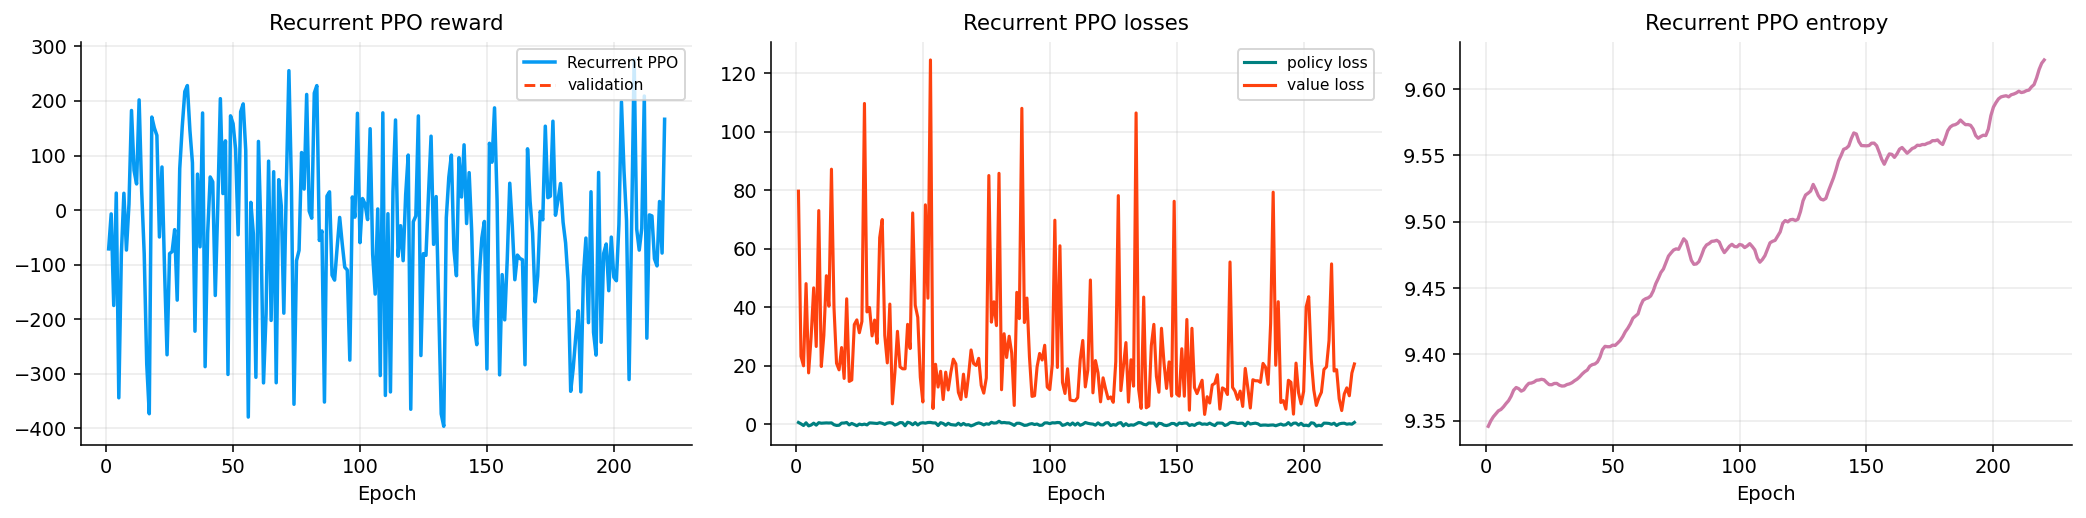

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
training_reward_curve(axes[0], rppo_history, label="Recurrent PPO", title="Recurrent PPO reward")
ppo_loss_curves(axes[1], rppo_history, title="Recurrent PPO losses")
policy_entropy_curve(axes[2], rppo_history, title="Recurrent PPO entropy")
plt.tight_layout()
plt.show()


,mean,std,min,max
SPY,0.1767,0.0450,0.0412,0.2540
QQQ,0.0974,0.0479,0.0376,0.2316
IWM,0.1174,0.0585,0.0144,0.2470
EFA,0.0741,0.0488,0.0110,0.2218
EEM,0.0357,0.0126,0.0149,0.0854
VNQ,0.0460,0.0469,0.0066,0.2299
DBC,0.0402,0.0274,0.0044,0.1047
GLD,0.0151,0.0109,0.0037,0.0657
IEF,0.0051,0.0018,0.0029,0.0133
TLT,0.0255,0.0334,0.0061,0.1820


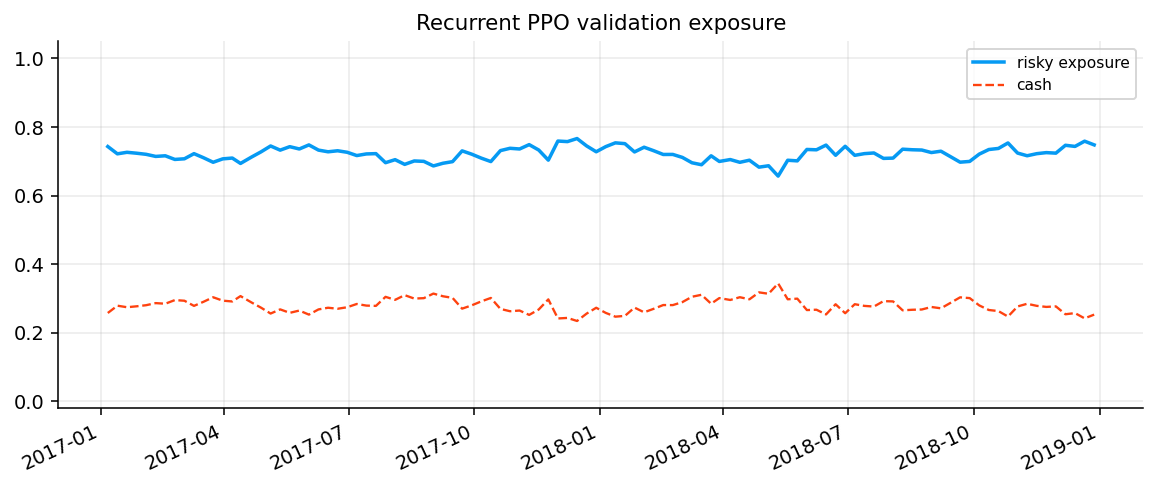

In [35]:
rppo_valid_rows = collect_recurrent_rollout(rppo, valid_idx, deterministic=True)
w_rppo_valid = pd.DataFrame(rppo_valid_rows["weights"], index=pd.DatetimeIndex(rppo_valid_rows["date"]), columns=state_columns)
display(w_rppo_valid.describe().T[["mean", "std", "min", "max"]].round(4))
fig, ax = plt.subplots(figsize=(10, 3.4))
policy_exposure_path(ax, w_rppo_valid, cash_ticker=cash_ticker, title="Recurrent PPO validation exposure")
plt.show()


The recurrent PPO validation table shows lower risky exposure than PPO, around 72%, and higher cash. It also shows lower validation total reward. In this run, the recurrent memory makes the policy more defensive, but it doesn't clearly improve performance. That is still a useful result. Memory helps only if the training data is rich enough and the sequence signal is stable enough. If the recurrent model mostly learns to avoid risk, it can reduce drawdown but lose too much return.


The RPPO result is an important reminder that more model structure doesn't automatically improve allocation. The recurrent model has memory, but it also has more parameters and a harder training problem. In this run it becomes more defensive, holds more SHY, and doesn't beat the non-recurrent PPO or SAC in the final comparison. That is a real result, not a failure of the notebook. It shows that the data may not contain enough stable sequential signal for this recurrent architecture to dominate.


The recurrent PPO validation table is weaker than the feedforward PPO table. It shows total reward **55.76**, return **7.10%**, volatility **7.29%**, validation Sharpe **-0.0281**, max drawdown **-11.08%**, and average exposure **72.14%**.

The lower exposure is visible in the validation weight table. Recurrent PPO holds about **27.86%** in SHY on average, compared with about **20.02%** for PPO. It also spreads risk more evenly. Effective diversification later confirms that recurrent PPO is the most diversified RL policy.

This is not automatically a failure. It means the recurrent policy learned a more defensive allocation. In this validation sample, that defensiveness reduced volatility but didn't improve Sharpe. The added memory may also be too flexible for the amount of training data. Recurrent models need enough sequential evidence to justify the extra parameters.


The recurrent training plots show the same basic pattern: noisy reward, unstable loss paths, and gradual changes in exposure. This is a good place to remember that RL training curves in finance don't look like clean supervised-learning curves. A supervised model sees many labeled samples. An on-policy RL model repeatedly changes the policy, changes the data distribution it experiences, and then updates again. That makes the training path noisier by design.


## 11) SAC and Maximum-Entropy Actor-Critic

SAC is the most advanced RL model in this notebook. It is an **off-policy actor-critic** method with a maximum-entropy objective.

The standard RL objective maximizes expected return:

$$
J(\pi) = \mathbb{E}_{\pi}\left[\sum_t \gamma^t r_t\right]
$$

SAC adds entropy:

$$
J_{SAC}(\pi) = \mathbb{E}_{\pi}\left[\sum_t \gamma^t \left(r_t + \alpha H(\pi(\cdot\mid s_t))\right)\right]
$$

The entropy term rewards policies that keep some randomness. The coefficient $\alpha$ controls how much the policy values exploration. In continuous control, this is very useful because the action space has many possible directions. In portfolio allocation, it means the policy doesn't have to collapse immediately into one deterministic set of weights during training.

SAC learns a soft Q-function. The soft target is:

$$
y_t = r_t + \gamma\left(\min(Q_{\phi_1^-}(s_{t+1},a_{t+1}),Q_{\phi_2^-}(s_{t+1},a_{t+1})) - \alpha \log \pi_\theta(a_{t+1}\mid s_{t+1})\right)
$$

There are several details packed into this equation:

- $Q_{\phi_1}$ and $Q_{\phi_2}$ are twin critics,
- the minimum reduces overestimation bias,
- the target critics $\phi^-_1,\phi^-_2$ move slowly for stability,
- the $-\alpha\log\pi$ term is the entropy-adjusted value of the next action,
- the sampled next action $a_{t+1}$ comes from the current stochastic actor.

The critic loss is:

$$
L_Q(\phi_i) = \mathbb{E}\left[(Q_{\phi_i}(s_t,a_t)-y_t)^2\right]
$$

The actor loss is:

$$
L_\pi(\theta) = \mathbb{E}\left[\alpha \log \pi_\theta(a_t\mid s_t) - \min(Q_{\phi_1}(s_t,a_t),Q_{\phi_2}(s_t,a_t))\right]
$$

Minimizing this actor loss means increasing Q-value while also keeping entropy. The implementation also learns $\alpha$ using a target entropy, so the amount of randomness adjusts during training rather than being fixed forever.

### 11.1 Maximum entropy objective

SAC optimizes a different objective from PPO. It doesn't only maximize expected reward. It also rewards entropy:

$$
J(\pi)=E_\pi\left[\sum_{t=0}^{T-1}\gamma^t\left(R_{t+1}+\alpha\mathcal{H}(\pi(\cdot\mid S_t))\right)\right]
$$

The entropy term measures how random the policy is. Higher entropy means the policy keeps multiple actions plausible instead of collapsing into one deterministic allocation. The coefficient $\alpha$ controls how much entropy matters.

In financial allocation, entropy has a practical meaning. A policy that becomes too certain too quickly may overfit one historical pattern. A stochastic policy keeps exploring different allocation shapes, which can act like a regularizer. SAC also learns $\alpha$ automatically, which is useful because the right exploration level changes during training.

SAC learns two critics:

$$
Q_{\phi_1}(s,a), \qquad Q_{\phi_2}(s,a)
$$

The target uses the minimum of the two:

$$
\min(Q_{\phi_1},Q_{\phi_2})
$$

This reduces overestimation bias. If one critic is too optimistic about an action, the other critic can pull the target down. In noisy finance rewards, that is a big advantage.

The soft Bellman target is:

$$
y_t = r_t + \gamma(1-d_t)\left[\min_i Q_{\phi_i^-}(s_{t+1},a_{t+1}) - \alpha\log\pi_\theta(a_{t+1}\mid s_{t+1})\right]
$$

The first part is the immediate reward. The second part is discounted future soft value. The $\log\pi$ term is negative for low-probability actions, so subtracting $\alpha\log\pi$ rewards entropy. The target critics $Q_{\phi_i^-}$ are slow-moving copies of the learned critics, which stabilizes training.

The actor objective is:

$$
\mathcal{L}_{actor}=E\left[\alpha\log\pi_\theta(a_t\mid s_t)-\min_i Q_{\phi_i}(s_t,a_t)\right]
$$

Minimizing this loss pushes the actor toward actions with high critic value and enough entropy. The actor wants high $Q$, but it is also encouraged not to become too deterministic.

This is why SAC often behaves differently from PPO. PPO collects fresh rollouts and updates cautiously around them. SAC reuses experience through a replay buffer and learns a critic over continuous actions.


### 11.2 Reparameterization in SAC

SAC uses the reparameterization trick for the actor update. Instead of sampling an action in a way that blocks gradients, we write the sampled action as:

$$
a_t = \mu_\theta(s_t) + \sigma_\theta(s_t)\odot \epsilon_t, \qquad \epsilon_t\sim\mathcal{N}(0,I)
$$

Now the randomness is isolated in $\epsilon_t$, and the action remains differentiable with respect to $\mu_\theta$ and $\sigma_\theta$. This lets the actor receive gradients through the critic:

$$
\nabla_\theta Q_\phi(s_t,a_t)
$$

That is one reason SAC is powerful for continuous action spaces. The actor doesn't only learn from log-probability weighting like vanilla policy gradient. It can move directly toward actions that the critic says have high value, while the entropy term keeps it exploratory.

### 11.3 Automatic entropy temperature

The entropy temperature $\alpha$ is learned by comparing the policy entropy with a target entropy. A common objective is:

$$
\mathcal{L}(\alpha)=E\left[-\alpha\left(\log\pi_\theta(a_t\mid s_t)+\mathcal{H}_{target}\right)\right]
$$

If the policy entropy is too low, $\alpha$ rises and exploration becomes more valuable. If entropy is too high, $\alpha$ falls and the policy focuses more on reward. The notebook sets the target entropy proportional to the action dimension:

$$
\mathcal{H}_{target} = -0.75(N+1)
$$

The action dimension is $N+1$ because we have one raw score per risky asset plus one exposure score. This scaling makes sense because a higher-dimensional action space needs more entropy than a one-dimensional action space.

The learned temperature is another stabilizer. In a noisy portfolio environment, a fixed entropy penalty might be too high early and too low later. Automatic temperature tuning gives SAC a way to adjust exploration during training.

### 11.4 Twin critics and pessimism

SAC's twin critics are especially useful in finance because return noise can make value estimates too optimistic. If one critic overestimates the value of a high-risk action, the min operator reduces the target:

$$
Q_{target}(s,a)=\min(Q_{\phi_1^-}(s,a),Q_{\phi_2^-}(s,a))
$$

This is a built-in pessimism mechanism. It doesn't make the policy conservative in every sense, but it reduces the chance that one critic's positive error makes the actor chase a bad action.


### 11.5 SAC behavior in the final portfolio context

SAC's aggressive behavior can be understood from its objective. The critic learns that many risky allocations produced strong reward over parts of the historical sample. The entropy objective keeps the policy from collapsing, but it doesn't force the policy to hold cash. If the critic values high-exposure actions, SAC will learn high exposure.


### 11.6 PPO and SAC as different answers to the same control problem

PPO and SAC solve the same portfolio-control problem with different learning assumptions.

PPO says: collect data from the current policy, estimate advantages, and update the policy carefully so it doesn't move too far. The policy is stable because each update is restricted. The downside is that PPO is sample-hungry. It uses fresh rollouts and doesn't reuse old experience as aggressively.

SAC says: store transitions in a replay buffer, learn critics off-policy, and train an actor that maximizes both value and entropy. This is more sample-efficient and often more powerful in continuous-control environments. The downside is that critic errors can shape the actor in bad ways if the Q-function becomes miscalibrated.

In finance, neither assumption is perfect. PPO's on-policy stability is attractive because market data is noisy, but on-policy learning wastes data. SAC's replay buffer is attractive because data is limited, but old transitions may come from regimes that no longer apply. This is why the notebook trains both. The comparison isn't just a leaderboard. It shows two different RL philosophies applied to the same allocation environment.


### 11.7 Replay buffer and off-policy updates

SAC is off-policy, so it can reuse previously collected transitions. The replay buffer stores tuples:

$$
(s_t,a_t,r_t,s_{t+1},d_t)
$$

where $d_t$ indicates whether the episode ended. During training, SAC samples minibatches from this buffer and updates the critics and actor. This is more sample-efficient than on-policy PPO because the same transition can be used multiple times.

In this notebook, the SAC code collects a full rollout from the current policy, appends transitions to the replay buffer, and then performs minibatch critic/actor updates. The target critic is updated softly:

$$
\phi^- \leftarrow \rho \phi^- + (1-\rho)\phi
$$

The code uses a slow update, with most of the target network preserved and a small amount of current critic weight mixed in. This is another stability mechanism.

The twin-critic structure is especially useful in continuous action problems. If a single critic overestimates the value of a weird action, the actor may exploit that error. Taking the minimum of two critics makes that exploitation harder.

Off-policy learning is another major SAC advantage. PPO can only update from data collected by the current policy, or almost-current policy. SAC stores transitions in a replay buffer:

$$
(s_t,a_t,r_t,s_{t+1},d_t)
$$

Then it samples mini-batches from that buffer many times. This is more sample efficient. In finance, sample efficiency matters because we have very limited historical data. However, replay also has risk: old transitions may come from policies or market periods that are no longer representative.

The target critic update uses soft target networks:

$$
\phi^- \leftarrow \rho\phi^- + (1-\rho)\phi
$$

With $\rho=0.995$, the target critic changes slowly. This prevents the critic target from chasing the online critic too aggressively.


In [36]:
class SacCriticLocal(nn.Module):
    def __init__(self, n_asset_features, n_global_features, n_assets, hidden_size=96):
        super().__init__()
        self.encoder = CrossAssetEncoder(n_asset_features, n_global_features, n_assets, hidden_size=hidden_size)
        q_in = self.encoder.output_dim + n_assets + 1
        self.q1 = nn.Sequential(nn.LayerNorm(q_in), nn.Linear(q_in, hidden_size), nn.SiLU(), nn.Linear(hidden_size, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
        self.q2 = nn.Sequential(nn.LayerNorm(q_in), nn.Linear(q_in, hidden_size), nn.SiLU(), nn.Linear(hidden_size, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
    def forward(self, ax, gx, px, action):
        z = self.encoder(ax, gx, px)
        qx = torch.cat([z, action.float()], dim=-1)
        return self.q1(qx).squeeze(-1), self.q2(qx).squeeze(-1)

class SacActorCritic(nn.Module):
    def __init__(self, n_asset_features, n_global_features, n_assets, hidden_size=96, alpha_index=None):
        super().__init__()
        self.n_assets = n_assets
        self.alpha_index = alpha_index
        self.alpha_gain = nn.Parameter(torch.tensor(4.0)) if alpha_index is not None else None
        self.actor_encoder = CrossAssetEncoder(n_asset_features, n_global_features, n_assets, hidden_size=hidden_size)
        self.actor_score_head = nn.Sequential(nn.LayerNorm(self.actor_encoder.asset_score_dim), nn.Linear(self.actor_encoder.asset_score_dim, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
        self.actor_exposure_head = nn.Sequential(nn.LayerNorm(self.actor_encoder.output_dim), nn.Linear(self.actor_encoder.output_dim, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
        self.actor_log_std_head = nn.Sequential(nn.LayerNorm(self.actor_encoder.output_dim), nn.Linear(self.actor_encoder.output_dim, hidden_size), nn.SiLU(), nn.Linear(hidden_size, n_assets + 1))
        self.critic = SacCriticLocal(n_asset_features, n_global_features, n_assets, hidden_size=hidden_size)
    def action_mean(self, ax, gx, px):
        h_asset, context, global_h, port_h, fused = self.actor_encoder.encode(ax, gx, px)
        n = h_asset.shape[1]
        score_x = torch.cat([
            h_asset,
            context.unsqueeze(1).expand(-1, n, -1),
            global_h.unsqueeze(1).expand(-1, n, -1),
            port_h.unsqueeze(1).expand(-1, n, -1),
        ], dim=-1)
        risky = self.actor_score_head(score_x).squeeze(-1)
        if self.alpha_index is not None:
            risky = risky + self.alpha_gain * ax.float()[..., self.alpha_index]
        exposure = self.actor_exposure_head(fused).squeeze(-1)
        return torch.cat([risky, exposure.unsqueeze(-1)], dim=-1), fused
    def sample_action(self, ax, gx, px, deterministic=False):
        mean, fused = self.action_mean(ax, gx, px)
        std = torch.exp(self.actor_log_std_head(fused).clamp(-5, 1))
        dist = Normal(mean, std)
        action = mean if deterministic else dist.rsample()
        logp = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        weights = action_to_weights(action, reward_settings["min_exposure"], reward_settings["max_exposure"], reward_settings["max_weight"])
        return action, logp, entropy, weights
    def q_values(self, ax, gx, px, action):
        return self.critic(ax, gx, px, action)
    def act(self, ax, gx, px, deterministic=False):
        action, logp, entropy, weights = self.sample_action(ax, gx, px, deterministic=deterministic)
        return action, logp, entropy, torch.zeros_like(logp), weights


In [37]:
def train_sac_model(model, model_path, epochs=120, batch_size=128, alpha=0.05):
    model.to(device)
    if model_path.exists():
        try:
            model.load_state_dict(torch.load(model_path, map_location=device))
            rows = collect_policy_rollout(model, valid_idx, deterministic=True)
            return pd.DataFrame(), validation_stats_from_rollout(rows)
        except Exception as exc:
            print(f"Retraining SAC because checkpoint is incompatible: {exc}")
    target_critic = copy.deepcopy(model.critic).to(device)
    actor_params = list(model.actor_encoder.parameters()) + list(model.actor_score_head.parameters()) + list(model.actor_exposure_head.parameters()) + list(model.actor_log_std_head.parameters()) + ([model.alpha_gain] if getattr(model, "alpha_gain", None) is not None else [])
    critic_params = list(model.critic.parameters())
    actor_opt = torch.optim.AdamW(actor_params, lr=3e-4, weight_decay=1e-5)
    critic_opt = torch.optim.AdamW(critic_params, lr=3e-4, weight_decay=1e-5)
    log_alpha = torch.tensor(np.log(alpha), dtype=torch.float32, device=device, requires_grad=True)
    alpha_opt = torch.optim.AdamW([log_alpha], lr=3e-4)
    target_entropy = -0.75 * (len(assets) + 1)
    reward_scale = 0.01
    replay, history, best_score, best_state = [], [], -np.inf, None
    update_count = 0
    sac_rollout_length = 156
    for epoch in range(1, epochs + 1):
        if len(train_idx) > sac_rollout_length:
            start = int(np.random.randint(0, max(1, len(train_idx) // 5))) if np.random.rand() < 0.4 else int(np.random.randint(0, max(1, len(train_idx) - sac_rollout_length)))
            idx = train_idx[start:start + sac_rollout_length]
        else:
            idx = train_idx
        rows = collect_policy_rollout(model, idx, deterministic=False)
        for i in range(len(rows["reward"])):
            ni = min(i + 1, len(rows["reward"]) - 1)
            replay.append((rows["asset"][i], rows["global"][i], rows["portfolio"][i], rows["action"][i], rows["reward"][i], rows["asset"][ni], rows["global"][ni], rows["portfolio"][ni], float(i == len(rows["reward"]) - 1)))
        replay = replay[-100000:]
        critic_losses, actor_losses, q_values = [], [], []
        updates = max(1, len(train_idx) // batch_size)
        for _ in range(updates):
            if len(replay) < batch_size:
                break
            pick = np.random.randint(0, len(replay), size=batch_size)
            batch = [replay[i] for i in pick]
            ax = torch.tensor(np.asarray([b[0] for b in batch]), dtype=torch.float32, device=device)
            gx = torch.tensor(np.asarray([b[1] for b in batch]), dtype=torch.float32, device=device)
            px = torch.tensor(np.asarray([b[2] for b in batch]), dtype=torch.float32, device=device)
            act = torch.tensor(np.asarray([b[3] for b in batch]), dtype=torch.float32, device=device)
            rew = torch.tensor(np.asarray([b[4] for b in batch]), dtype=torch.float32, device=device) * reward_scale
            nax = torch.tensor(np.asarray([b[5] for b in batch]), dtype=torch.float32, device=device)
            ngx = torch.tensor(np.asarray([b[6] for b in batch]), dtype=torch.float32, device=device)
            npx = torch.tensor(np.asarray([b[7] for b in batch]), dtype=torch.float32, device=device)
            done = torch.tensor(np.asarray([b[8] for b in batch]), dtype=torch.float32, device=device)
            with torch.no_grad():
                nact, nlogp, _, _ = model.sample_action(nax, ngx, npx)
                tq1, tq2 = target_critic(nax, ngx, npx, nact)
                target_q = torch.min(tq1, tq2) - log_alpha.exp().detach() * nlogp
                y = rew + reward_settings["sac_gamma"] * (1.0 - done) * target_q
            q1, q2 = model.q_values(ax, gx, px, act)
            critic_loss = torch.nn.functional.mse_loss(q1, y) + torch.nn.functional.mse_loss(q2, y)
            critic_opt.zero_grad(set_to_none=True)
            critic_loss.backward()
            torch.nn.utils.clip_grad_norm_(critic_params, 2.0)
            critic_opt.step()
            update_count += 1
            if update_count % 2 == 0:
                for p in model.critic.parameters():
                    p.requires_grad_(False)
                pact, logp, entropy, _ = model.sample_action(ax, gx, px)
                q1p, q2p = model.q_values(ax, gx, px, pact)
                qpi = torch.min(q1p, q2p)
                actor_loss = (log_alpha.exp().detach() * logp - qpi).mean()
                actor_opt.zero_grad(set_to_none=True)
                actor_loss.backward()
                torch.nn.utils.clip_grad_norm_(actor_params, 2.0)
                actor_opt.step()
                alpha_loss = -(log_alpha * (logp.detach() + target_entropy)).mean()
                alpha_opt.zero_grad(set_to_none=True)
                alpha_loss.backward()
                alpha_opt.step()
                for p in model.critic.parameters():
                    p.requires_grad_(True)
                for tp, sp in zip(target_critic.parameters(), model.critic.parameters()):
                    tp.data.mul_(0.995).add_(sp.data, alpha=0.005)
                actor_losses.append(float(actor_loss.detach().cpu()))
                q_values.append(float(qpi.mean().detach().cpu()))
            critic_losses.append(float(critic_loss.detach().cpu()))
        valid_reward = np.nan
        valid_sharpe = np.nan
        if epoch % max(1, epochs // 10) == 0 or epoch == epochs:
            stats = validation_stats_from_rollout(collect_policy_rollout(model, valid_idx, deterministic=True))
            valid_reward, valid_sharpe = stats["total_reward"], stats["sharpe"]
            score = valid_sharpe if np.isfinite(valid_sharpe) else valid_reward
            if score > best_score:
                best_score = score
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        history.append({"epoch": epoch, "train_reward": np.sum(rows["reward"]), "critic_loss": np.mean(critic_losses) if critic_losses else np.nan, "actor_loss": np.mean(actor_losses) if actor_losses else np.nan, "q_value": np.mean(q_values) if q_values else np.nan, "alpha": float(log_alpha.exp().detach().cpu()), "entropy": np.mean(rows["entropy"]), "avg_exposure": np.mean([w[:-1].sum() for w in rows["weights"]]), "validation_reward": valid_reward, "validation_sharpe": valid_sharpe})
    if best_state is not None:
        model.load_state_dict(best_state)
    model_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), model_path)
    return pd.DataFrame(history), validation_stats_from_rollout(collect_policy_rollout(model, valid_idx, deterministic=True))


In [38]:
import copy
sac = SacActorCritic(asset_state.shape[2], global_state.shape[1], len(assets), hidden_size=128, alpha_index=alpha_index)
sac_history, sac_validation = train_sac_model(
    sac,
    model_dir / "sac_dsr.pt",
    epochs=sac_epochs_main,
    batch_size=128,
    alpha=0.05,
)
display(pd.Series(sac_validation).to_frame("SAC").round(4))


,SAC
total_reward,60.3848
mean_reward,0.5806
return,0.0859
vol,0.0935
sharpe,0.0704
max_drawdown,-0.1443
avg_exposure,0.9624


The SAC validation table shows the strongest validation Sharpe among the three RL policies, even though the reward is not the highest. It reports total reward **60.38**, return **8.59%**, volatility **9.35%**, Sharpe **0.0704**, max drawdown **-14.43%**, and average exposure **96.24%**.

This makes SAC clearly more aggressive than PPO and recurrent PPO. The validation weight table shows average weights around **25.01% SPY**, **15.30% HYG**, **14.46% IWM**, **11.35% EFA**, and only **3.76% SHY**. The max weights also show that SPY, EFA, and HYG can hit the 35% cap.

So SAC is learning a high-risky-exposure policy. It accepts more volatility and drawdown than the PPO policies, but it captures more upside. Later, when we compare out-of-sample performance, SAC remains the best RL policy by Sharpe, but it still doesn't beat the stronger supervised/rule-based baselines.


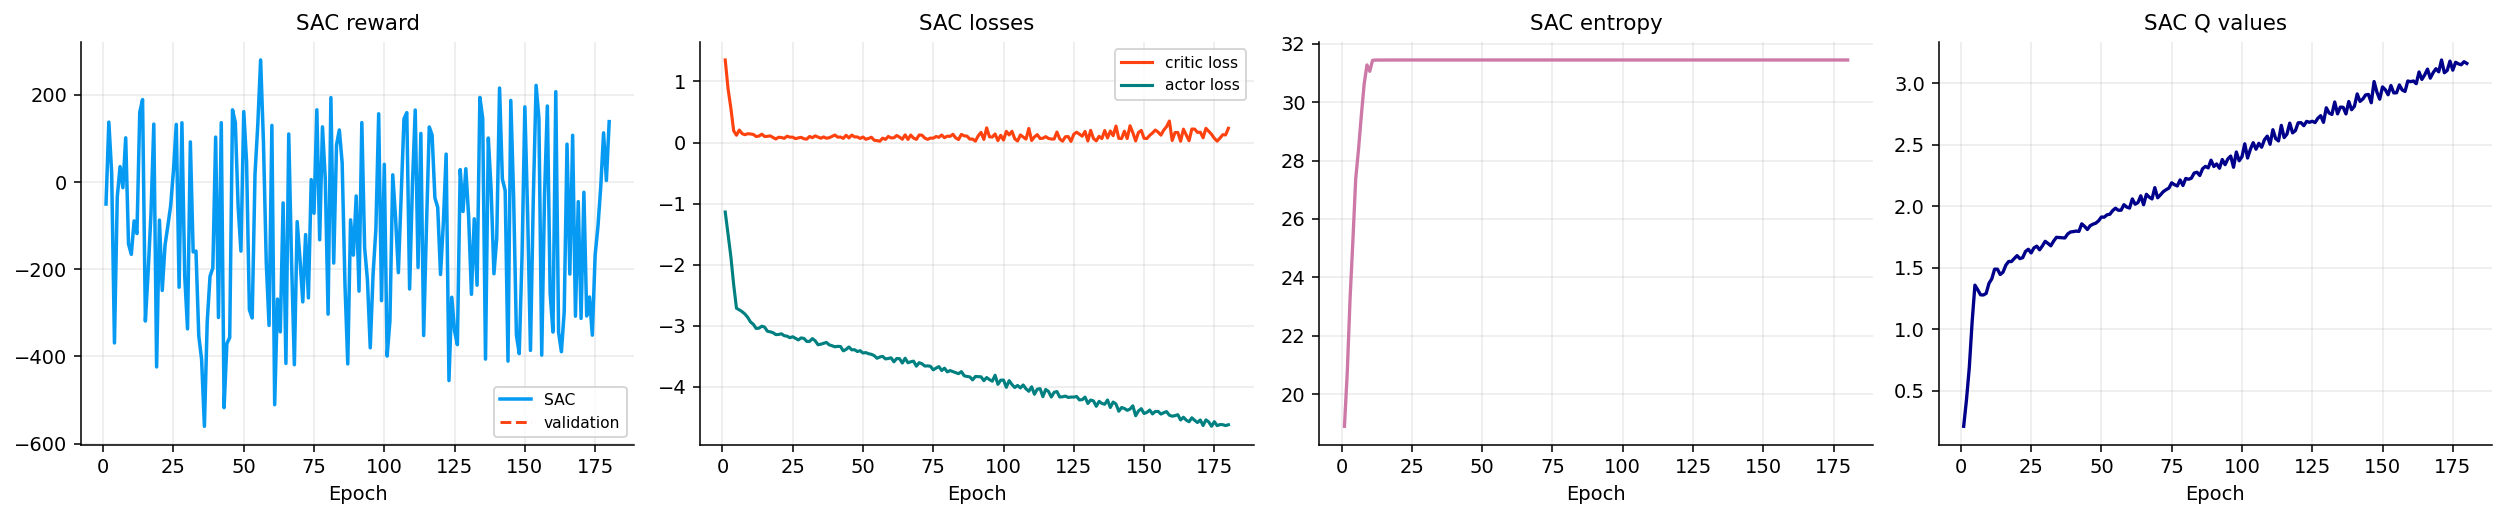

In [39]:
from quantfinlab.plotting.ml import q_value_curve, sac_loss_curves
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
training_reward_curve(axes[0], sac_history, label="SAC", title="SAC reward")
sac_loss_curves(axes[1], sac_history, title="SAC losses")
policy_entropy_curve(axes[2], sac_history, title="SAC entropy")
q_value_curve(axes[3], sac_history, title="SAC Q values")
plt.tight_layout()
plt.show()


,mean,std,min,max
SPY,0.2501,0.0733,0.0609,0.3500
QQQ,0.0977,0.0494,0.0364,0.2594
IWM,0.1446,0.0715,0.0292,0.3423
EFA,0.1135,0.0752,0.0160,0.3500
EEM,0.0358,0.0147,0.0120,0.0726
VNQ,0.0453,0.0405,0.0101,0.2779
DBC,0.0365,0.0240,0.0022,0.1042
GLD,0.0201,0.0202,0.0029,0.1198
IEF,0.0100,0.0028,0.0034,0.0203
TLT,0.0215,0.0212,0.0059,0.1104


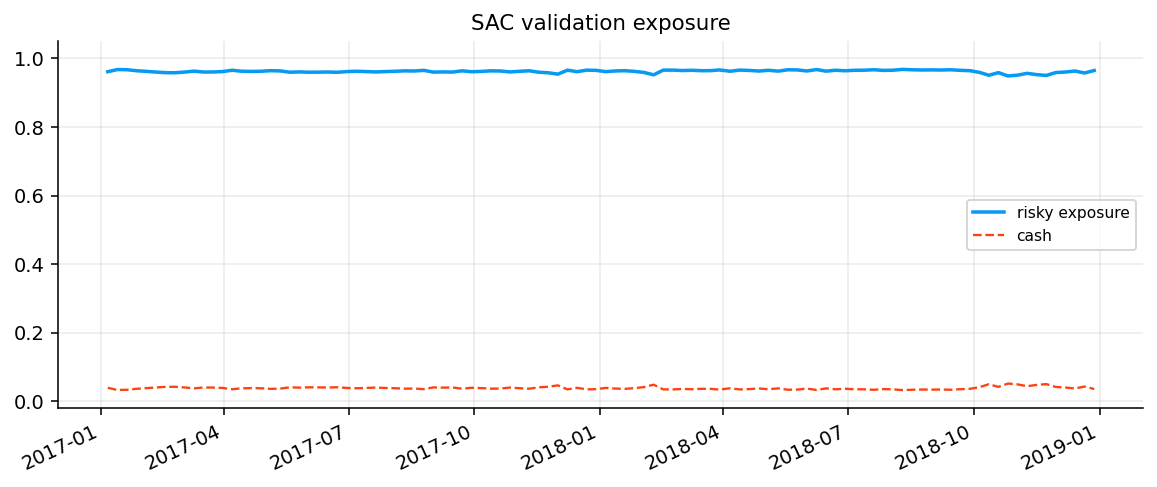

In [40]:
sac_valid_rows = collect_policy_rollout(sac, valid_idx, deterministic=True)
w_sac_valid = pd.DataFrame(sac_valid_rows["weights"], index=pd.DatetimeIndex(sac_valid_rows["date"]), columns=state_columns)
display(w_sac_valid.describe().T[["mean", "std", "min", "max"]].round(4))
fig, ax = plt.subplots(figsize=(10, 3.4))
policy_exposure_path(ax, w_sac_valid, cash_ticker=cash_ticker, title="SAC validation exposure")
plt.show()


The SAC loss plot has four panels: training reward, critic loss, actor loss, and soft Q-value. The critic loss falls quickly and then stays near a low region, which suggests the critic is fitting the replay-buffer targets. The Q-value plot rises over training, which means the actor-critic system is learning actions the critics value more highly.

The policy validation exposure plot shows SAC staying close to full risky exposure. Cash is consistently low. This is the opposite of recurrent PPO and very different from the cash-heavy validation behavior of RandomForest Kelly. SAC is using the action space to make aggressive allocations while respecting the per-asset cap.


In this notebook, SAC becomes the highest-risky-exposure RL policy, with average exposure around 96% and cash around 4%.


The final SAC behavior still turns out aggressive. That tells us the critic learned high value for risky exposure in many states. Since the sample includes strong equity and credit periods, that is understandable. The risk report later shows the cost of that behavior in stress windows.


The validation weight summary confirms this. SAC holds much less SHY than PPO and recurrent PPO. It puts more average weight into SPY, IWM, HYG, QQQ, and EFA. That is a risk-on cross-asset allocation. It can do well when equity and credit premia are rewarded, but it creates larger losses during broad stress.

This is exactly why SAC is interesting here. It is the most advanced RL method in the notebook, and it becomes the best RL model by final Sharpe, but it still doesn't dominate the rule-based alternatives. That makes the empirical story stronger. We can see the algorithm's strength and its limitation at the same time:

- it learns a decisive continuous policy,
- it uses off-policy sample reuse,
- it handles stochastic exploration elegantly,
- it still struggles against carefully designed financial baselines.

A weaker notebook would hide that comparison. This one makes it visible.


The output behavior matches that difference. PPO is controlled and diversified. SAC is more decisive and risk-seeking. Recurrent PPO becomes more defensive because the memory model appears to learn caution from sequences. These behavioral differences are just as important as the final Sharpe ratios.


The SAC validation result shows higher return than PPO and recurrent PPO, but also higher volatility and a deeper drawdown. The average exposure is near the maximum. This is exactly the kind of tradeoff we need to interpret carefully. SAC is the most aggressive RL model in this run. It learns to use the risky sleeve heavily, especially SPY, IWM, HYG, and QQQ. That can help in bull or rebound periods, but it also leaves the policy more exposed in stress windows.


## 12) Building the Final RL Weight Frames

After training, we convert each policy into a deterministic weight frame for the test period. PPO, recurrent PPO, and SAC each produce weekly weights. Then we also create an RL ensemble by blending the policies using validation Sharpe-like scores.

The blend weight logic is:

$$
w^{ens}_t = \sum_m \omega_m w^{(m)}_t
$$

with:

$$
\omega_m = \frac{\max(score_m,0.01)}{\sum_j \max(score_j,0.01)}
$$

The small floor prevents a model from receiving exactly zero ensemble weight. This is useful when validation scores are noisy. If a model is weak but not completely unusable, a tiny allocation keeps it represented without letting it dominate.

The final strategy set contains:

- Equal Weight,
- Forecast-Gated MaxSharpe from Project 19,
- RandomForest Kelly from Project 19,
- ML Regime-Aware from Project 16,
- PPO,
- Recurrent PPO,
- SAC,
- Ensemble RL.

This comparison is deliberately hard for RL. It doesn't compare RL only against naive baselines. It compares RL against strong hand-built and supervised-learning strategies that already use forecasts, Kelly sizing, and regime logic.

### 12.1 Validation-score ensemble

The RL ensemble combines PPO, recurrent PPO, and SAC using validation performance. The generic ensemble weight is:

$$
w^{ens}_t = \sum_{m=1}^{M}\omega_m w^{(m)}_t
$$

where $w^{(m)}_t$ is the weight vector from model $m$, and $\omega_m$ is the model's ensemble weight. The weights are based on validation scores, so stronger validation policies receive more influence.

This kind of ensemble can reduce model-specific risk. PPO is more cautious, recurrent PPO is even more defensive, and SAC is more aggressive. Averaging them can smooth extreme behavior. The tradeoff is that an ensemble can also dilute the best model. If SAC is the strongest RL model, averaging it with weaker PPO policies may lower return while only partially improving drawdown.


## 13) Final Strategy Comparison


In [41]:
def policy_weight_frame_local(model, indices, recurrent=False):
    rows = collect_recurrent_rollout(model, indices, deterministic=True) if recurrent else collect_policy_rollout(model, indices, deterministic=True)
    return pd.DataFrame(rows["weights"], index=pd.DatetimeIndex(rows["date"]), columns=state_columns)

def blend_policy_weights(weight_frames, blend_weights):
    total = sum(max(0.0, v) for v in blend_weights.values()) or float(len(weight_frames))
    columns = sorted({c for f in weight_frames.values() for c in f.columns})
    index = sorted({d for f in weight_frames.values() for d in f.index})
    blended = pd.DataFrame(0.0, index=pd.DatetimeIndex(index), columns=columns)
    for name, frame in weight_frames.items():
        blended = blended + (max(0.0, blend_weights.get(name, 0.0)) / total) * frame.reindex(index=blended.index, columns=columns).fillna(0.0)
    return blended.div(blended.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

w_ppo = policy_weight_frame_local(ppo, test_idx)
w_rppo = policy_weight_frame_local(rppo, test_idx, recurrent=True)
w_sac = policy_weight_frame_local(sac, test_idx)
w_ensemble = blend_policy_weights(
    {"PPO": w_ppo, "Recurrent PPO": w_rppo, "SAC": w_sac},
    {
        "PPO": max(0.01, ppo_validation["sharpe"]),
        "Recurrent PPO": max(0.01, rppo_validation["sharpe"]),
        "SAC": max(0.01, sac_validation["sharpe"]),
    },
).reindex(columns=state_columns).fillna(0.0)

weights_by_strategy = {
    "Equal Weight": w_eq,
    "Forecast-Gated MaxSharpe": w_forecast_gated_ms,
    "RandomForest Kelly": w_rf_kelly,
    "ML Regime-Aware": w_regime,
    "PPO": w_ppo,
    "Recurrent PPO": w_rppo,
    "SAC": w_sac,
    "Ensemble RL": w_ensemble,
}
test_returns_daily = r_d.loc[pd.Timestamp(test_period[0]):pd.Timestamp(test_period[1]), assets + [cash_ticker]]
final_backtests = run_many_weights_backtests(
    weights_by_strategy,
    returns=test_returns_daily,
    cost_bps=cost_bps,
    rf_daily=rf_daily,
    w_min=0.0,
    w_max=1.0,
    long_only=True,
    normalize=True,
    weight_timing="next_close",
)


In [42]:
final_summary = build_strategy_summary(final_backtests, rf_daily=rf_daily, annualization=annualization)
final_summary = final_summary.sort_values(["Sharpe", "Max Drawdown"], ascending=[False, False])
display(final_summary[["CAGR", "Vol", "Sharpe", "Sortino", "Max Drawdown", "Turnover", "Effective N"]].round(4))


,CAGR,Vol,Sharpe,Sortino,Max Drawdown,Turnover,Effective N
Strategy,,,,,,,
ML Regime-Aware,0.1088,0.1000,0.6889,0.8601,-0.1913,0.2252,7.3736
RandomForest Kelly,0.1244,0.1321,0.6588,0.8412,-0.2198,0.3898,5.2668
Forecast-Gated MaxSharpe,0.1246,0.1395,0.6378,0.7687,-0.2747,0.3300,3.2402
Equal Weight,0.1036,0.1180,0.5629,0.6867,-0.2218,0.0178,12.0000
SAC,0.0903,0.1311,0.4211,0.5002,-0.2824,0.1754,6.0107
Ensemble RL,0.0850,0.1195,0.4102,0.4902,-0.2544,0.1577,6.6886
Recurrent PPO,0.0789,0.1021,0.4070,0.4938,-0.2053,0.1332,6.0940
PPO,0.0763,0.1054,0.3754,0.4543,-0.2272,0.1473,6.3323


The final results show exactly that kind of mixed behavior. Ensemble RL sits between the individual policies. It has lower volatility than SAC but also lower return. It doesn't beat the strongest rule-based models.


The final performance table is the most important result in the notebook. It shows that the strongest overall model is **ML Regime-Aware**, with Sharpe **0.6889**, CAGR **10.88%**, volatility **10.00%**, and max drawdown **-19.13%**. RandomForest Kelly and Forecast-Gated MaxSharpe have higher CAGR, around **12.44%** and **12.46%**, but also higher volatility and larger drawdowns.

Among the RL models, **SAC is the strongest**, with Sharpe **0.4211**, CAGR **9.03%**, volatility **13.11%**, and max drawdown **-28.24%**. Ensemble RL, recurrent PPO, and PPO are weaker. PPO has the lowest RL Sharpe at **0.3754**. Recurrent PPO has lower volatility and drawdown than SAC, but it doesn't generate enough return to compensate.

The honest interpretation is that RL is impressive as an implementation, but it doesn't dominate the portfolio models in this sample. This is a realistic result. Financial RL has very limited independent training data, strong nonstationarity, transaction costs, and a noisy reward. The rule-based ML strategies benefit from stronger structure: they transform forecasts and regimes through explicit portfolio rules. The RL policies have to learn that mapping from a much smaller sequential training set.

The table still shows useful behavior. SAC reaches a reasonable out-of-sample CAGR and effective number around **6.01**, so it isn't just degenerating into one asset. Recurrent PPO has the lowest RL drawdown at **-20.53%**, suggesting the memory policy learned a more defensive style. PPO and recurrent PPO also have lower turnover than the rule-based forecasting strategies.

The final comparison table is the most important empirical output. The strongest strategies in the test period are still the earlier supervised/rule-based models: ML Regime-Aware, RandomForest Kelly, and Forecast-Gated MaxSharpe. SAC is the best pure RL model by Sharpe among the three RL policies, but it doesn't beat the strongest non-RL models.

This is a realistic result. RL has a more flexible objective and a richer action loop, but flexibility doesn't guarantee better out-of-sample performance. The stronger rule-based models benefit from more direct forecast-to-weight structure and stronger inductive bias. RL has to learn the whole mapping from state to action from a small historical sample.

Still, the RL models are not useless. They show different policy behavior:

- PPO learns a diversified, moderately defensive allocation.
- Recurrent PPO learns an even more defensive allocation with more SHY.
- SAC learns a high-exposure, more concentrated policy.
- The RL ensemble averages those behaviors and lands between them.

The final performance table gives us a good honest conclusion: RL is promising as a decision layer, but in this dataset and implementation, it doesn't yet dominate the simpler forecast-gated and regime-aware systems. That is valuable because it tells us where the bottleneck is. The issue is not building an RL environment. The environment works. The issue is extracting robust signal from a small, noisy market history without overfitting.

### 13.1 Model comparison across learning philosophies

The final table is also a comparison of modeling philosophies:

| Strategy type | Main learning idea | Main risk |
|---|---|---|
| Equal Weight | no forecast, stable diversification | ignores changing opportunity set |
| Forecast-Gated MaxSharpe | supervised alpha forecast plus optimizer | sensitive to forecast quality and optimizer assumptions |
| RandomForest Kelly | tree forecast plus growth-optimal sizing | sizing can become too aggressive or too defensive |
| ML Regime-Aware | regime probabilities guide allocation | regime model may lag transitions |
| PPO | cautious on-policy RL control | sample-hungry and may learn conservative behavior |
| Recurrent PPO | PPO plus memory | harder to train, may become overly defensive |
| SAC | off-policy entropy-regularized actor-critic | can become aggressive if critic values risky exposure |
| Ensemble RL | average RL policy behavior | may dilute the best individual policy |

This table is useful because the project shouldn't be judged by one leaderboard number only. Each model has a different bias. Forecast-Gated MaxSharpe has a strong prior: forecasts enter an optimizer. RL has a weaker prior: it learns the state-action mapping from reward. That makes RL more flexible but also easier to overfit.

The empirical result favors the structured supervised allocation models. That doesn't reduce the value of Project 20. It actually makes the project stronger, because it shows a realistic outcome. The final project demonstrates RL engineering, reward design, policy training, and risk diagnostics, while still admitting that the best simpler models remain hard to beat.

### 13.2 Practical ranking of the final strategies

The final ranking can be interpreted in three layers.

First, the strongest test Sharpe belongs to **ML Regime-Aware**. That means the regime information from Project 16 still has strong practical value when mapped into portfolio weights. It doesn't need to learn a full RL control policy. It uses a structured macro/market-state idea and behaves well out of sample.

Second, **RandomForest Kelly** and **Forecast-Gated MaxSharpe** have the strongest return profiles. These are more forecast-driven and more active. Their drawdowns are larger than ML Regime-Aware, but their CAGR is also higher. This is the familiar tradeoff between growth, turnover, concentration, and drawdown.

Third, the RL models occupy the middle/lower part of the table. SAC is the strongest RL model, but its Sharpe is below the main supervised baselines. PPO and recurrent PPO are more conservative but also lower return. Ensemble RL smooths the RL policies but doesn't create a new edge.

This is a useful final lesson for the series. More flexible ML doesn't automatically beat stronger structure. In finance, a model with a good inductive bias can outperform a larger model that has to learn the bias from limited data. RL gives us a powerful framework, but it needs enough data and a very well-aligned reward to compete with carefully designed portfolio rules.


The table also shows a practical limitation of final-project complexity. A model can be technically more advanced and still lose to a simpler structure if the simpler structure matches the data-generating problem better. In this sample, regime-aware and forecast-gated rules have strong financial priors: they already know how forecasts and regimes should affect weights. RL has to discover that mapping from reward. With only hundreds of weekly decisions, discovering a robust mapping is difficult. That is the central empirical message.


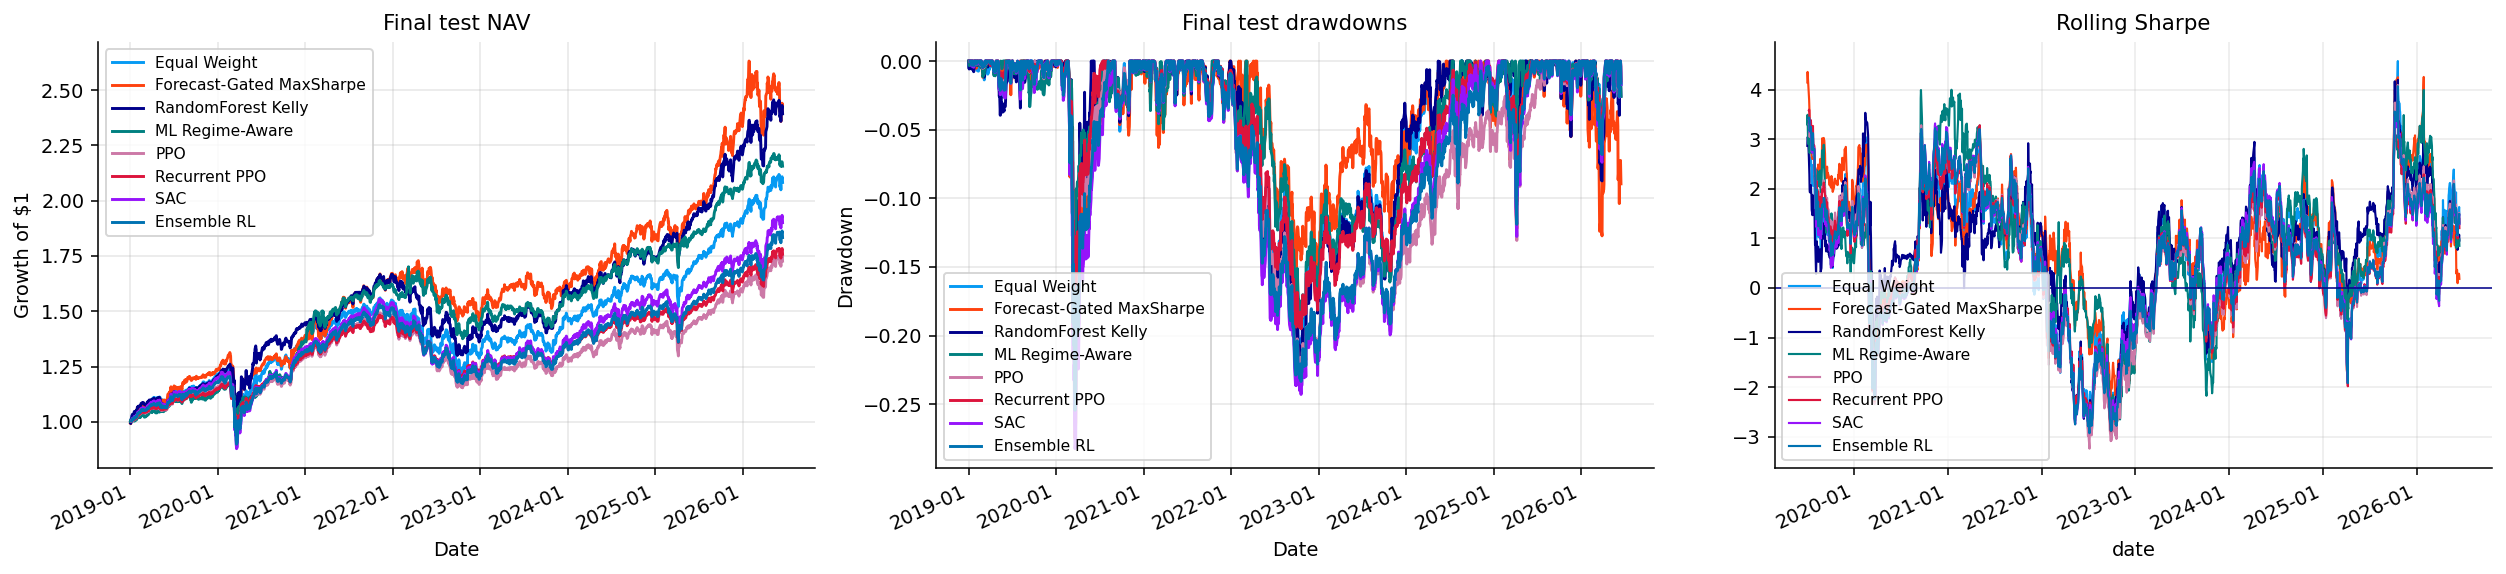

In [43]:
strategy_returns = pd.DataFrame({name: res.net_returns for name, res in final_backtests.items()}).dropna(how="all")
nav = pd.DataFrame({name: res.net_values for name, res in final_backtests.items()}).dropna(how="all")
fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))
plot_strategy_nav(nav, ax=axes[0], title="Final test NAV")
plot_strategy_drawdowns(nav, ax=axes[1], title="Final test drawdowns")
plot_rolling_sharpe(axes[2], strategy_returns, window=126, rf_daily=rf_daily, title="Rolling Sharpe")
plt.tight_layout()
plt.show()


The NAV and drawdown plots make the same story clearer. The forecast and regime models build larger wealth over the test period. The RL policies lag, especially after strong risk-on periods where their constraints and reward shaping keep them from fully chasing upside. SAC tracks risk assets more closely because it keeps high risky exposure, but that also gives it the largest RL drawdown.

The active-return plot versus Forecast-Gated MaxSharpe is negative for the RL policies. This is consistent with the active performance table that follows. RL is not adding active alpha relative to the strongest forecast-driven strategy. The policy is learning a valid control rule, but the existing forecast-gated optimizer remains stronger in this historical test.


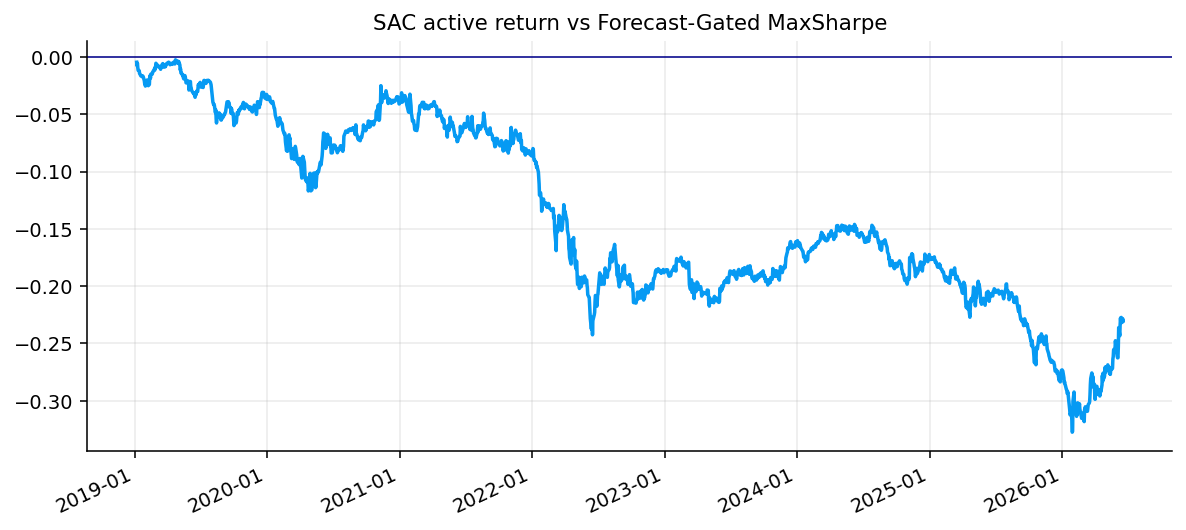

best policy: SAC


In [44]:
best_policy_name = final_summary.loc[[x for x in final_summary.index if x in ["PPO", "Recurrent PPO", "SAC"]], "Sharpe"].idxmax()
fig, ax = plt.subplots(figsize=(10, 3.8))
active_return_curve(ax, strategy_returns, strategy=best_policy_name, benchmark="Forecast-Gated MaxSharpe", title=f"{best_policy_name} active return vs Forecast-Gated MaxSharpe")
plt.show()
print("best policy:", best_policy_name)


The best RL policy by Sharpe is **SAC**, and the SAC active return plot versus Forecast-Gated MaxSharpe is mostly below zero. The active curve falls sharply during parts of the test window and never fully recovers. That tells us the underperformance is not one isolated month. It is a persistent active-return gap.

This result is important for the repo. The point of a final project like this is not to pretend RL always wins. The point is to show the full machinery, train the policies correctly, compare them honestly, and learn where RL struggles in real financial allocation.


In [45]:
def active_performance(strategy_returns, benchmark):
    R = strategy_returns.copy()
    rows = []
    b = R[benchmark]
    for name in R.columns:
        if name == benchmark:
            continue
        active = (R[name] - b).dropna()
        te = active.std(ddof=1) * np.sqrt(252.0)
        active_ann = active.mean() * 252.0
        active_nav = (1 + active).cumprod()
        rows.append({
            "Strategy": name,
            "Active CAGR": active_ann,
            "Tracking Error": te,
            "Information Ratio": active_ann / te if te > 0 else np.nan,
            "Active Max Drawdown": (active_nav / active_nav.cummax() - 1).min(),
            "Monthly Active Hit Rate": (active.resample("ME").sum() > 0).mean(),
        })
    return pd.DataFrame(rows).set_index("Strategy")

active_table = active_performance(strategy_returns, "Forecast-Gated MaxSharpe")
display(active_table.round(4))


,Active CAGR,Tracking Error,Information Ratio,Active Max Drawdown,Monthly Active Hit Rate
Strategy,,,,,
Equal Weight,-0.0225,0.0696,-0.3239,-0.2724,0.4333
RandomForest Kelly,-0.0019,0.0700,-0.0275,-0.2265,0.4444
ML Regime-Aware,-0.0201,0.0805,-0.2497,-0.2425,0.4333
PPO,-0.0484,0.0647,-0.7477,-0.3918,0.3889
Recurrent PPO,-0.0464,0.0678,-0.6838,-0.3775,0.3556
SAC,-0.0327,0.0709,-0.4615,-0.3257,0.4778
Ensemble RL,-0.0389,0.0665,-0.5851,-0.3506,0.4111


### Benchmark-relative results

The active performance table confirms that every strategy underperforms Forecast-Gated MaxSharpe on active CAGR. RandomForest Kelly is close, with active CAGR **-0.19%** and information ratio **-0.0275**. The RL models are farther behind:

- PPO active CAGR: **-4.84%**,
- Recurrent PPO active CAGR: **-4.64%**,
- SAC active CAGR: **-3.27%**,
- Ensemble RL active CAGR: **-3.89%**.

SAC has the best monthly active hit rate among the RL models at **47.78%**, but it is still below 50%. Recurrent PPO has the weakest active hit rate at **35.56%**.

Tracking error is moderate, around 6.5% to 7.1% for the RL models. This means the RL policies are meaningfully different from Forecast-Gated MaxSharpe, but the difference is not rewarded with positive active return. That is the key benchmark-relative result.

The benchmark-relative table compares every strategy against Forecast-Gated MaxSharpe. Since Forecast-Gated is the strongest rule-based optimizer in this project, it is a tough benchmark. The RL models have negative active CAGR and negative information ratios versus it. SAC has the least bad monthly hit rate among RL policies, around 47.8%, but still negative active return.

That means the RL policy occasionally adds value but not consistently enough to beat the strong forecast-gated allocation. This is where interpretation matters. A weak IR doesn't mean the RL machinery is wrong. It means this specific RL training setup, reward design, sample size, and policy architecture didn't extract enough additional edge beyond the supervised forecast stack.

The policy diagnostics explain the behavior behind those numbers. PPO and recurrent PPO maintain effective diversification around 9 to 11 assets and keep substantial cash. SAC has effective diversification around 6 assets and much higher maximum weight. SAC takes more decisive bets, which helps its return but hurts drawdown. The diagnostics are therefore consistent with the performance table.


In [46]:
policy_weights = {"PPO": w_ppo, "Recurrent PPO": w_rppo, "SAC": w_sac}
diagnostic_rows = []
for name, W in policy_weights.items():
    risky = W[assets].sum(axis=1)
    turnover = 0.5 * W.diff().abs().sum(axis=1).fillna(0.0)
    hhi = (W[assets] ** 2).sum(axis=1)
    diagnostic_rows.append({
        "Policy": name,
        "Avg Risky Exposure": risky.mean(),
        "Avg Cash": W[cash_ticker].mean(),
        "Avg Turnover": turnover.mean(),
        "Avg HHI": hhi.mean(),
        "Effective N": 1.0 / hhi.mean(),
        "Avg Max Weight": W[assets].max(axis=1).mean(),
    })
policy_diagnostics = pd.DataFrame(diagnostic_rows).set_index("Policy")
display(policy_diagnostics.round(4))


,Avg Risky Exposure,Avg Cash,Avg Turnover,Avg HHI,Effective N,Avg Max Weight
Policy,,,,,,
PPO,0.7831,0.2169,0.1457,0.1097,9.1143,0.2301
Recurrent PPO,0.7273,0.2727,0.1314,0.0897,11.1499,0.2038
SAC,0.9610,0.0390,0.1738,0.1665,6.0069,0.2984


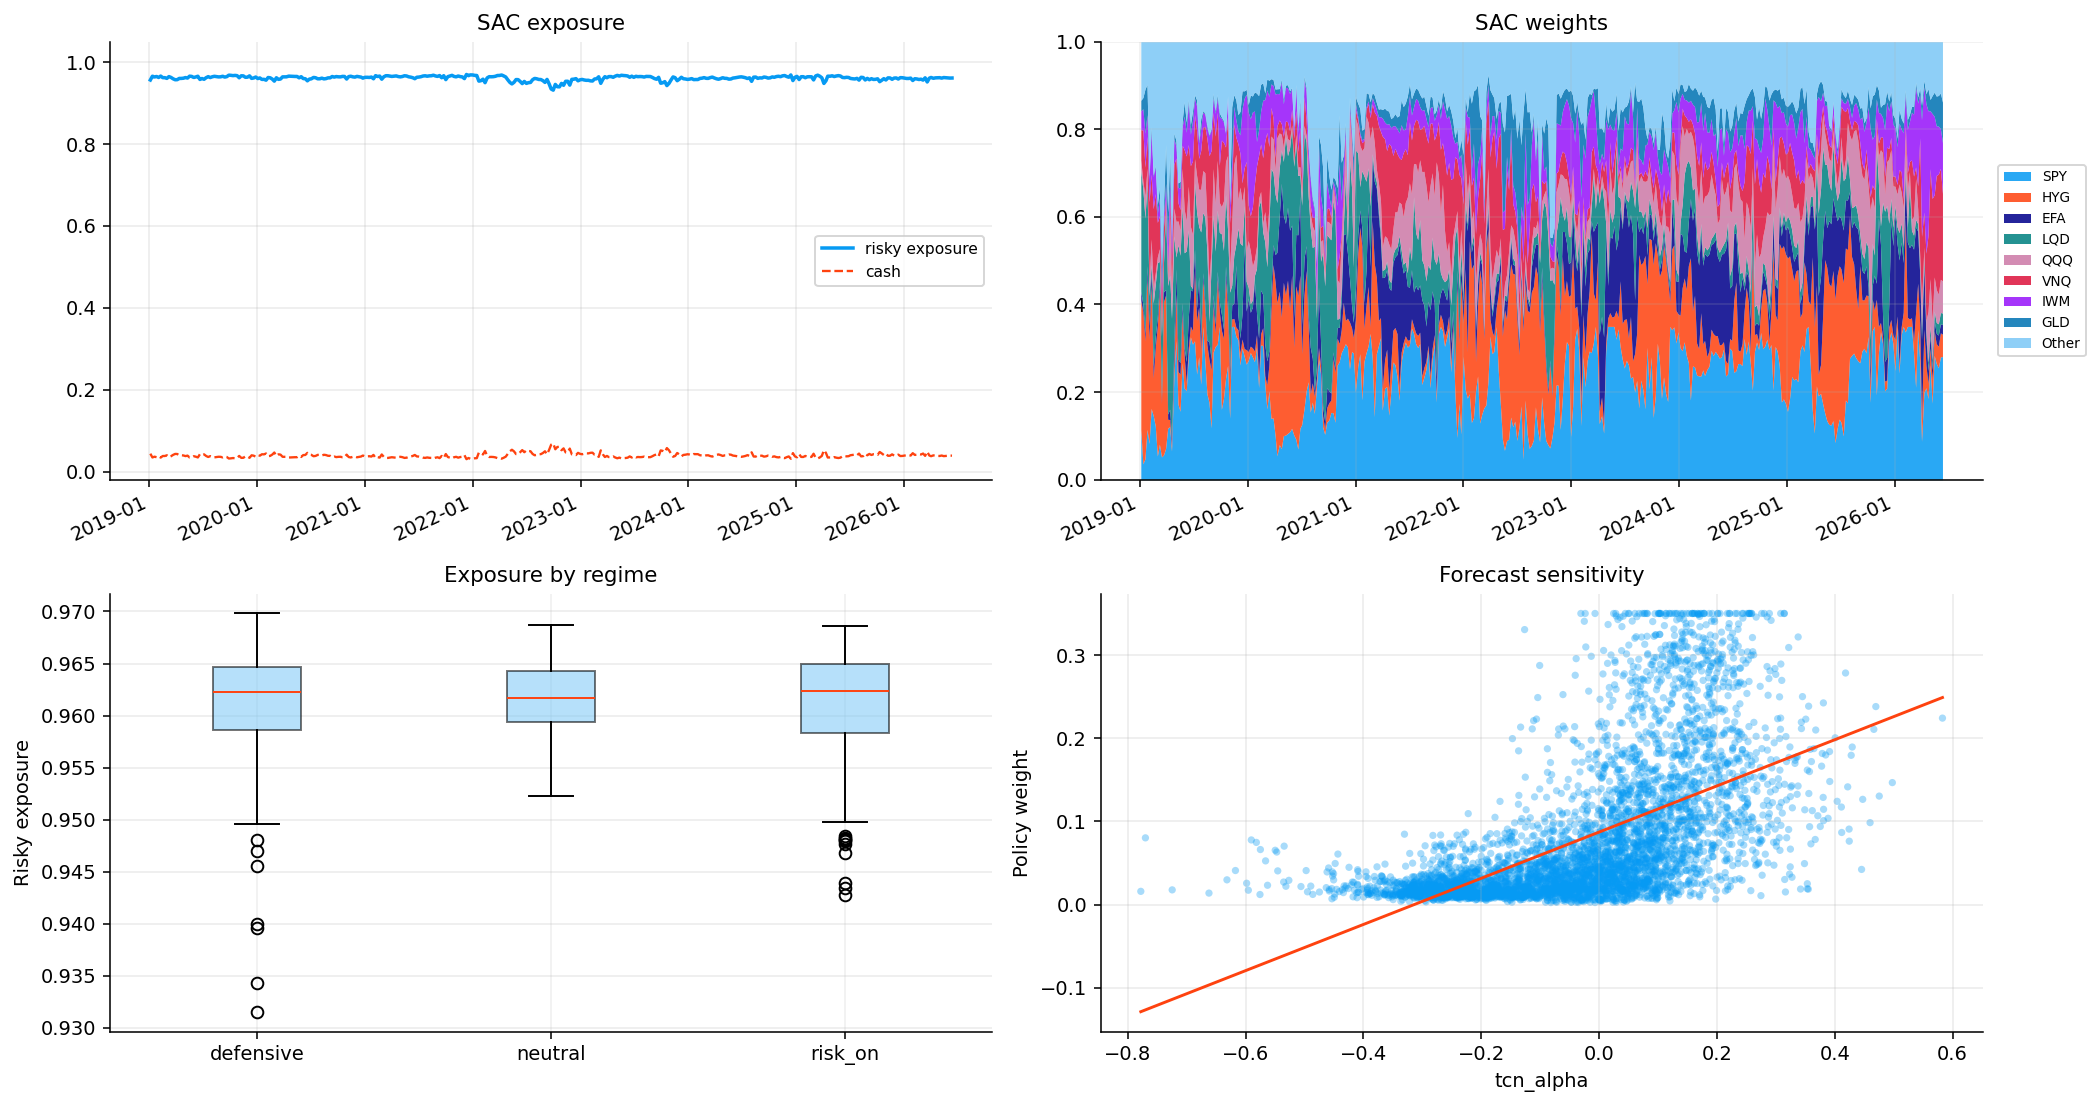

In [47]:
best_weights = policy_weights[best_policy_name]
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
policy_exposure_path(axes[0, 0], best_weights, cash_ticker=cash_ticker, title=f"{best_policy_name} exposure")
policy_weight_area(axes[0, 1], best_weights, title=f"{best_policy_name} weights")
regime_exposure_boxplot(axes[1, 0], best_weights, regime_x, title="Exposure by regime")
forecast_policy_sensitivity(axes[1, 1], best_weights, forecast_x, title="Forecast sensitivity")
plt.tight_layout()
plt.show()


### Policy behavior diagnostics

The policy diagnostics table explains the personalities of the three RL models.

**PPO** has average risky exposure **78.31%**, average cash **21.69%**, turnover **14.57%**, and effective number **9.11**. This is the middle policy: it takes risk, keeps a cash buffer, and stays reasonably diversified.

**Recurrent PPO** has average risky exposure **72.73%**, average cash **27.27%**, turnover **13.14%**, and effective number **11.15**. This is the most diversified and defensive policy. The memory model avoids concentration, but that defensive behavior limits upside.

**SAC** has average risky exposure **96.10%**, average cash **3.90%**, turnover **17.38%**, and effective number **6.01**. This is the aggressive policy. It takes more concentrated risk and keeps very little cash. That explains why it has the best RL CAGR but also a weaker drawdown profile.

The exposure and weight-area plots visually confirm this. PPO and recurrent PPO keep a visible SHY allocation. SAC mostly pushes toward risky assets, with higher weights in SPY, HYG, IWM, and EFA through parts of the sample.


## 14) Ablation and Sensitivity Checks

The ablation table tests how the best policy behaves when some state information is removed or corrupted. The three ablations are:

- `no_forecasts`: forecast-related features are set to zero,
- `no_priors`: prior-weight features are set to zero,
- `shuffled_forecasts`: forecast features are shuffled through time.


In [48]:
def ablated_asset_state(kind, base_state):
    arr = base_state.copy()
    if kind == "no_forecasts":
        for i, name in enumerate(asset_feature_names):
            lname = name.lower()
            if "tcn" in lname or "forecast" in lname or "alpha" in lname or "hgb" in lname or "rf" in lname or lname.startswith("z_"):
                arr[:, :, i] = 0.0
    elif kind == "no_priors":
        for i, name in enumerate(asset_feature_names):
            if name.startswith("prior_"):
                arr[:, :, i] = 0.0
    elif kind == "shuffled_forecasts":
        rng = np.random.default_rng(seed)
        for i, name in enumerate(asset_feature_names):
            lname = name.lower()
            if "tcn" in lname or "forecast" in lname or "alpha" in lname or "hgb" in lname or "rf" in lname or lname.startswith("z_"):
                arr[:, :, i] = arr[rng.permutation(arr.shape[0]), :, i]
    return arr

base_asset_state = asset_state.copy()
ablation_results = {}
try:
    for kind in ["no_forecasts", "no_priors", "shuffled_forecasts"]:
        asset_state = ablated_asset_state(kind, base_asset_state)
        rows = collect_recurrent_rollout(rppo, test_idx, deterministic=True) if best_policy_name == "Recurrent PPO" else collect_policy_rollout({"PPO": ppo, "SAC": sac}.get(best_policy_name, ppo), test_idx, deterministic=True)
        ablation_results[kind] = validation_stats_from_rollout(rows)
finally:
    asset_state = base_asset_state


In [49]:
ablation_table = pd.DataFrame(ablation_results).T
base_eval = validation_stats_from_rollout(collect_recurrent_rollout(rppo, test_idx, deterministic=True) if best_policy_name == "Recurrent PPO" else collect_policy_rollout({"PPO": ppo, "SAC": sac}.get(best_policy_name, ppo), test_idx, deterministic=True))
ablation_table.loc["base"] = base_eval
display(ablation_table[["total_reward", "return", "sharpe", "max_drawdown", "avg_exposure"]].round(4))


,total_reward,return,sharpe,max_drawdown,avg_exposure
no_forecasts,-449.9187,0.9330,0.4782,-0.2414,0.9603
no_priors,-404.8812,0.9009,0.4263,-0.2824,0.9610
shuffled_forecasts,-336.4110,0.6329,0.2654,-0.2907,0.9621
base,-404.8812,0.9009,0.4263,-0.2824,0.9610


The result is a little surprising. `no_forecasts` has Sharpe **0.4782**, which is better than the base SAC Sharpe **0.4263** in this rollout diagnostic. `shuffled_forecasts` drops to Sharpe **0.2654**, which shows that corrupted forecast timing hurts. `no_priors` is identical to base, suggesting the selected best policy either didn't receive meaningful prior features in the relevant state block or didn't use them in a way that changed the deterministic rollout.

This is a good example of why ablation is necessary. A model can include many impressive features, but the trained policy may rely on only some of them. In this case, the forecast features are not clearly beneficial to the best RL policy, even though they are very useful for the rule-based Forecast-Gated MaxSharpe strategy. The same signal can help one decision rule and confuse another.

Ablation is where we ask which inputs the best policy is actually using. The best RL policy is SAC, so the notebook tests several modified states:

- no forecast features,
- no prior-policy features,
- shuffled forecast features,
- base configuration.

The logic is straightforward. If removing forecasts doesn't hurt, the SAC policy wasn't using them. If shuffling forecasts hurts, the policy was relying on their time alignment. If removing priors hurts, the policy was using information from the earlier rule-based systems.

The ablation table suggests that the policy is sensitive to the forecast/prior stack, but the relationship isn't perfectly clean. The shuffled-forecast version performs worse in Sharpe than the no-forecast version in the output, which suggests that wrong timing in forecast information can be actively harmful. This is an important practical lesson: noisy features are one problem, but misaligned features are worse. They can teach the policy a false mapping between state and action.

This is also why the anti-leakage and alignment checks matter so much. RL can learn shortcuts, but it can also learn bad shortcuts from features that look predictive inside one historical path and fail out of sample.

### 14.1 Forecast alignment as an RL failure mode

The shuffled-forecast ablation is one of the most important checks because RL policies can exploit forecast features in subtle ways. If forecasts are useful only because they are correctly aligned in time, shuffling them should hurt. If shuffling doesn't hurt, the policy probably wasn't using them meaningfully.

The output shows that shuffled forecasts weaken the SAC variant. That means the forecast timing contains information the policy was using. At the same time, the no-forecast and no-prior variants don't collapse completely, which means SAC also learns from direct market features, previous weights, and global context.

This is the kind of diagnostic that makes the project credible. Instead of only reporting final performance, we test whether the policy depends on the information sources it is supposed to depend on. In finance ML, this is crucial because a model can look good for the wrong reason. Ablation helps separate real signal use from accidental backtest behavior.


## 15) Risk Reporting


,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
Ensemble RL,0.0109,0.0178,0.0116,0.0338,0.0130,0.0206
Equal Weight,0.0107,0.0176,0.0116,0.0301,0.0138,0.0212
Forecast-Gated MaxSharpe,0.0123,0.0210,0.0133,0.0360,0.0240,0.0347
ML Regime-Aware,0.0091,0.0151,0.0103,0.0203,0.0085,0.0126
PPO,0.0099,0.0160,0.0104,0.0268,0.0133,0.0202
RandomForest Kelly,0.0123,0.0193,0.0121,0.0304,0.0166,0.0246
Recurrent PPO,0.0094,0.0152,0.0099,0.0264,0.0114,0.0180
SAC,0.0118,0.0195,0.0126,0.0393,0.0137,0.0214


breach_count  breach_rate  coverage_error  \
object                   method                                              
Ensemble RL              cf                98       0.0605          0.0105   
                         fhs               95       0.0586          0.0086   
                         hist             100       0.0617          0.0117   
Equal Weight             cf                97       0.0598          0.0098   
                         fhs               90       0.0555          0.0055   
                         hist              98       0.0604          0.0104   
Forecast-Gated MaxSharpe cf                95       0.0585          0.0085   
                         fhs               93       0.0573          0.0073   
                         hist             106       0.0653          0.0153   
ML Regime-Aware          cf                74       0.0456         -0.0044   
                         fhs               94       0.0579          0.0079   
                         hist              89       0.0548          0.0048   
PPO                      cf                88       0.0543          0.0043   
                         fhs               93       0.0574          0.0074   
                         hist              98       0.0605          0.0105   
RandomForest Kelly       cf               101       0.0622          0.0122   
                         fhs               89       0.0548          0.0048   
                         hist             100       0.0616          0.0116   
Recurrent PPO            cf                92       0.0568          0.0068   
                         fhs               91       0.0562          0.0062   
                         hist              98       0.0605          0.0105   
SAC                      cf                98       0.0605          0.0105   
                         fhs               91       0.0562          0.0062   
                         hist              98       0.0605          0.0105   

                                 abs_coverage_error  longest_breach_streak  \
object                   method                                              
Ensemble RL              cf                  0.0105                      3   
                         fhs                 0.0086                      3   
                         hist                0.0117                      3   
Equal Weight             cf                  0.0098                      4   
                         fhs                 0.0055                      3   
                         hist                0.0104                      4   
Forecast-Gated MaxSharpe cf                  0.0085                      3   
                         fhs                 0.0073                      2   
                         hist                0.0153                      3   
ML Regime-Aware          cf                  0.0044                      3   
                         fhs                 0.0079                      3   
                         hist                0.0048                      3   
PPO                      cf                  0.0043                      3   
                         fhs                 0.0074                      3   
                         hist                0.0105                      3   
RandomForest Kelly       cf                  0.0122                      4   
                         fhs                 0.0048                      3   
                         hist                0.0116                      4   
Recurrent PPO            cf                  0.0068                      3   
                         fhs                 0.0062                      3   
                         hist                0.0105                      3   
SAC                      cf                  0.0105                      3   
                         fhs                 0.0062                      3   
                         hist                0.0105   

,object,cum_return,max_dd,worst_day,worst_week
window,,,,,
2022 rates/inflation shock,Ensemble RL,-0.2063,-0.2250,-0.0323,-0.0360
2022 rates/inflation shock,Equal Weight,-0.1865,-0.2110,-0.0324,-0.0392
2022 rates/inflation shock,Forecast-Gated MaxSharpe,-0.1009,-0.1575,-0.0314,-0.0339
2022 rates/inflation shock,ML Regime-Aware,-0.1364,-0.1913,-0.0357,-0.0303
2022 rates/inflation shock,PPO,-0.2038,-0.2195,-0.0281,-0.0375
2022 rates/inflation shock,RandomForest Kelly,-0.2017,-0.2156,-0.0339,-0.0438
2022 rates/inflation shock,Recurrent PPO,-0.1690,-0.1877,-0.0283,-0.0318
2022 rates/inflation shock,SAC,-0.2135,-0.2340,-0.0353,-0.0361
2023 rebound,Ensemble RL,0.1195,-0.0796,-0.0155,-0.0362


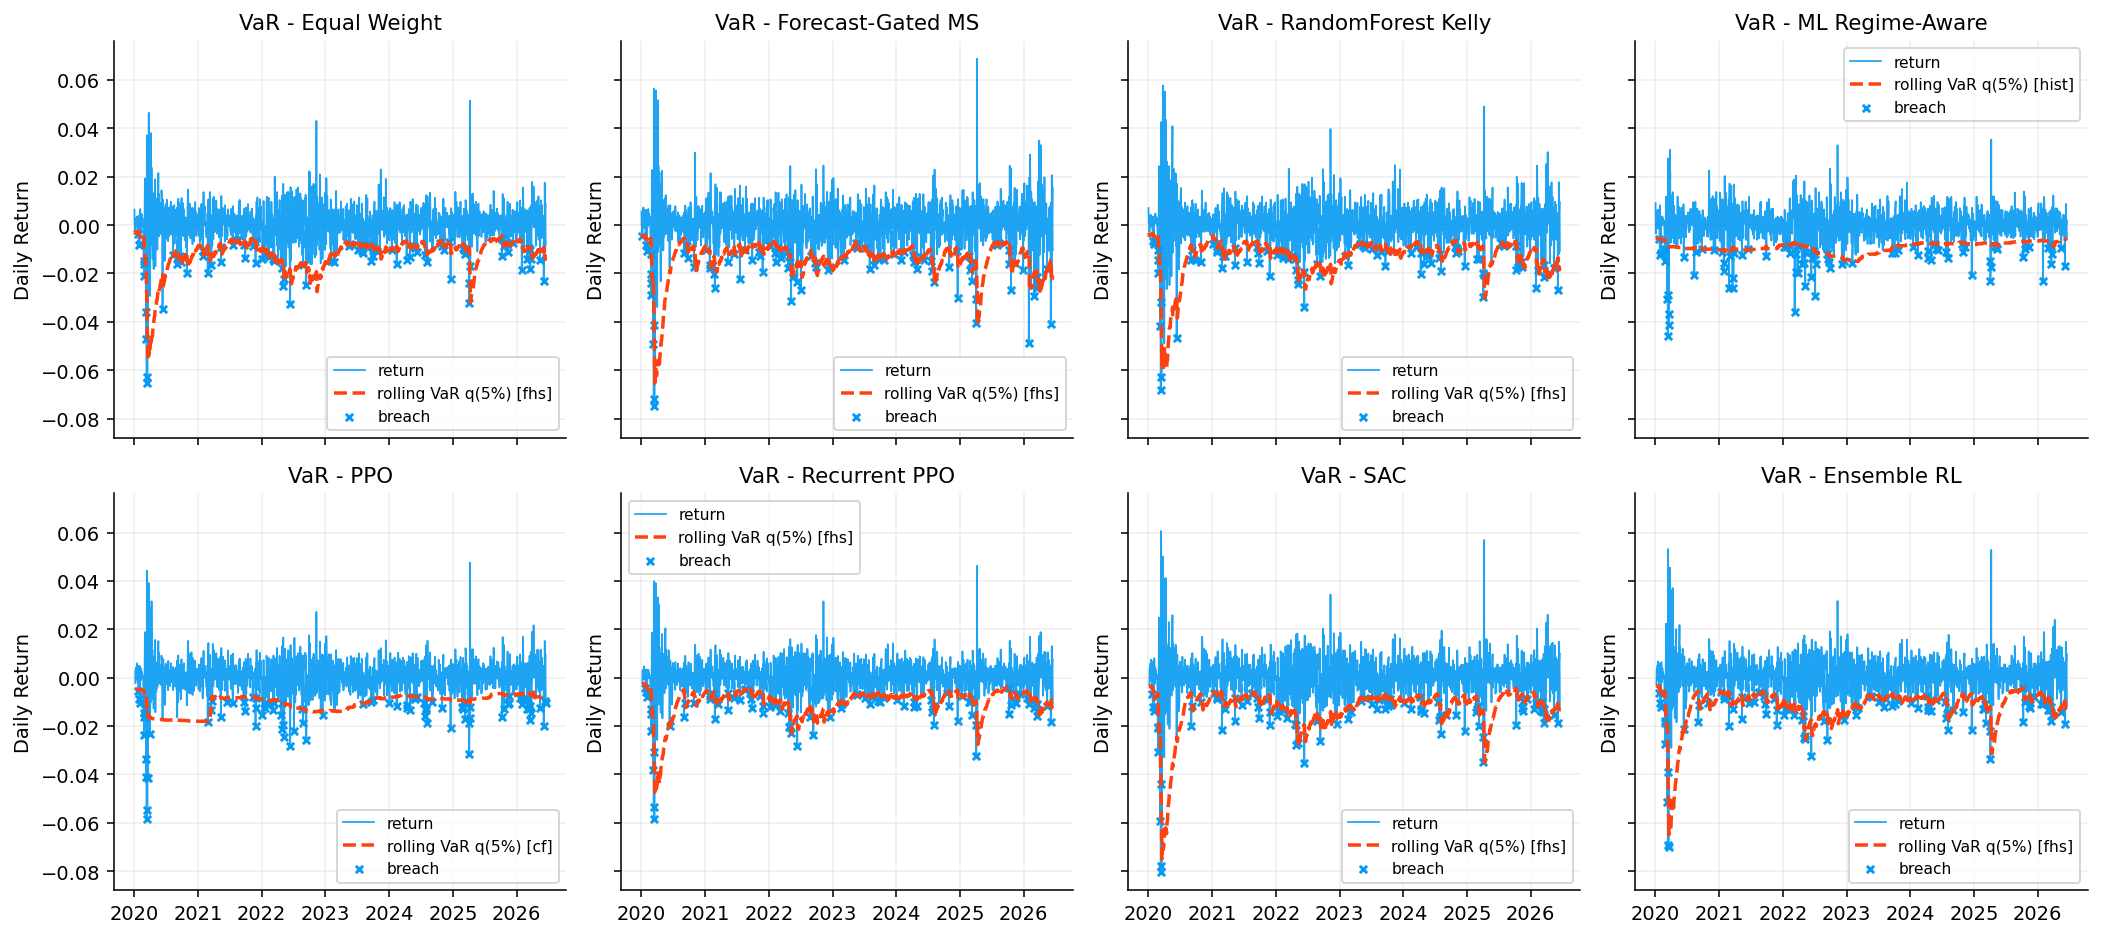

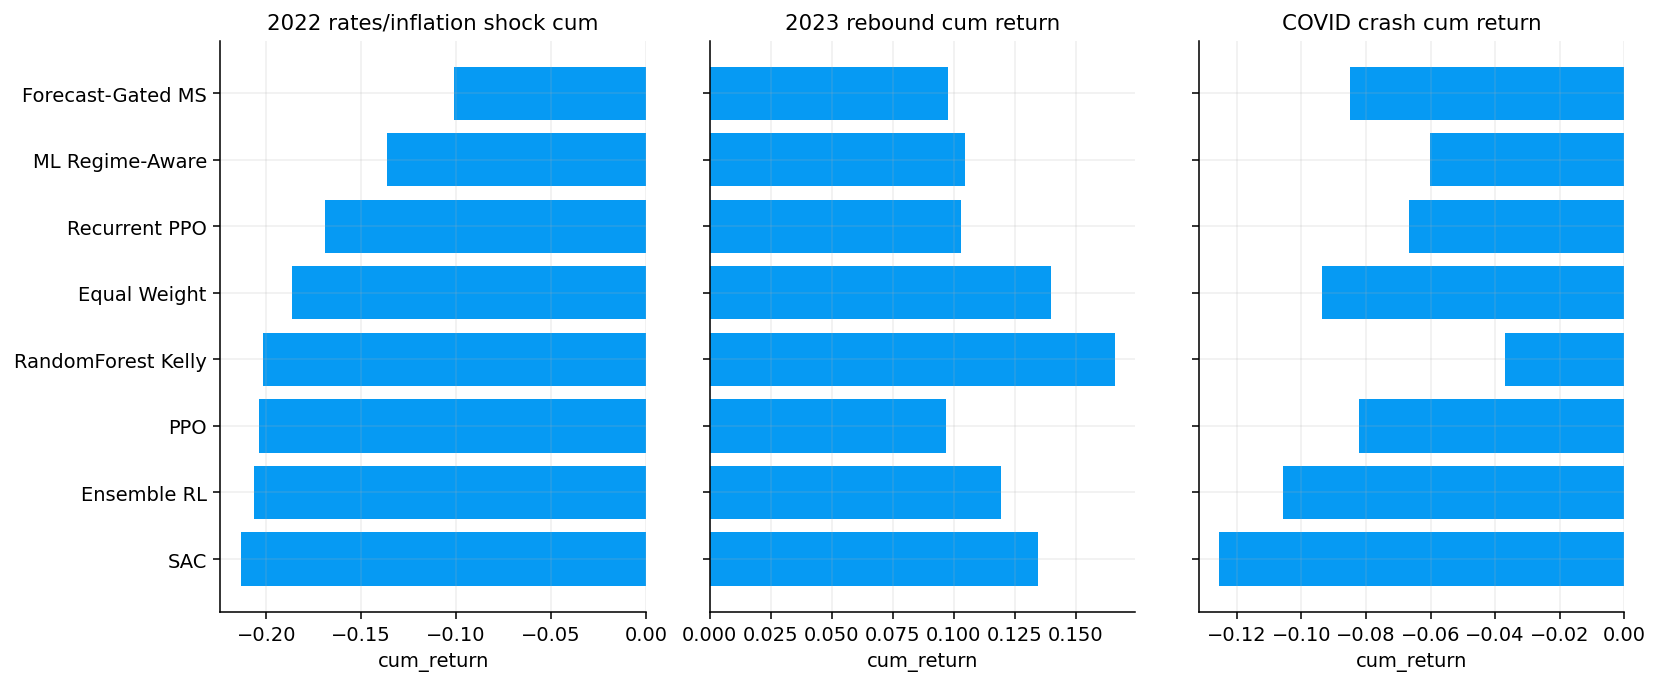

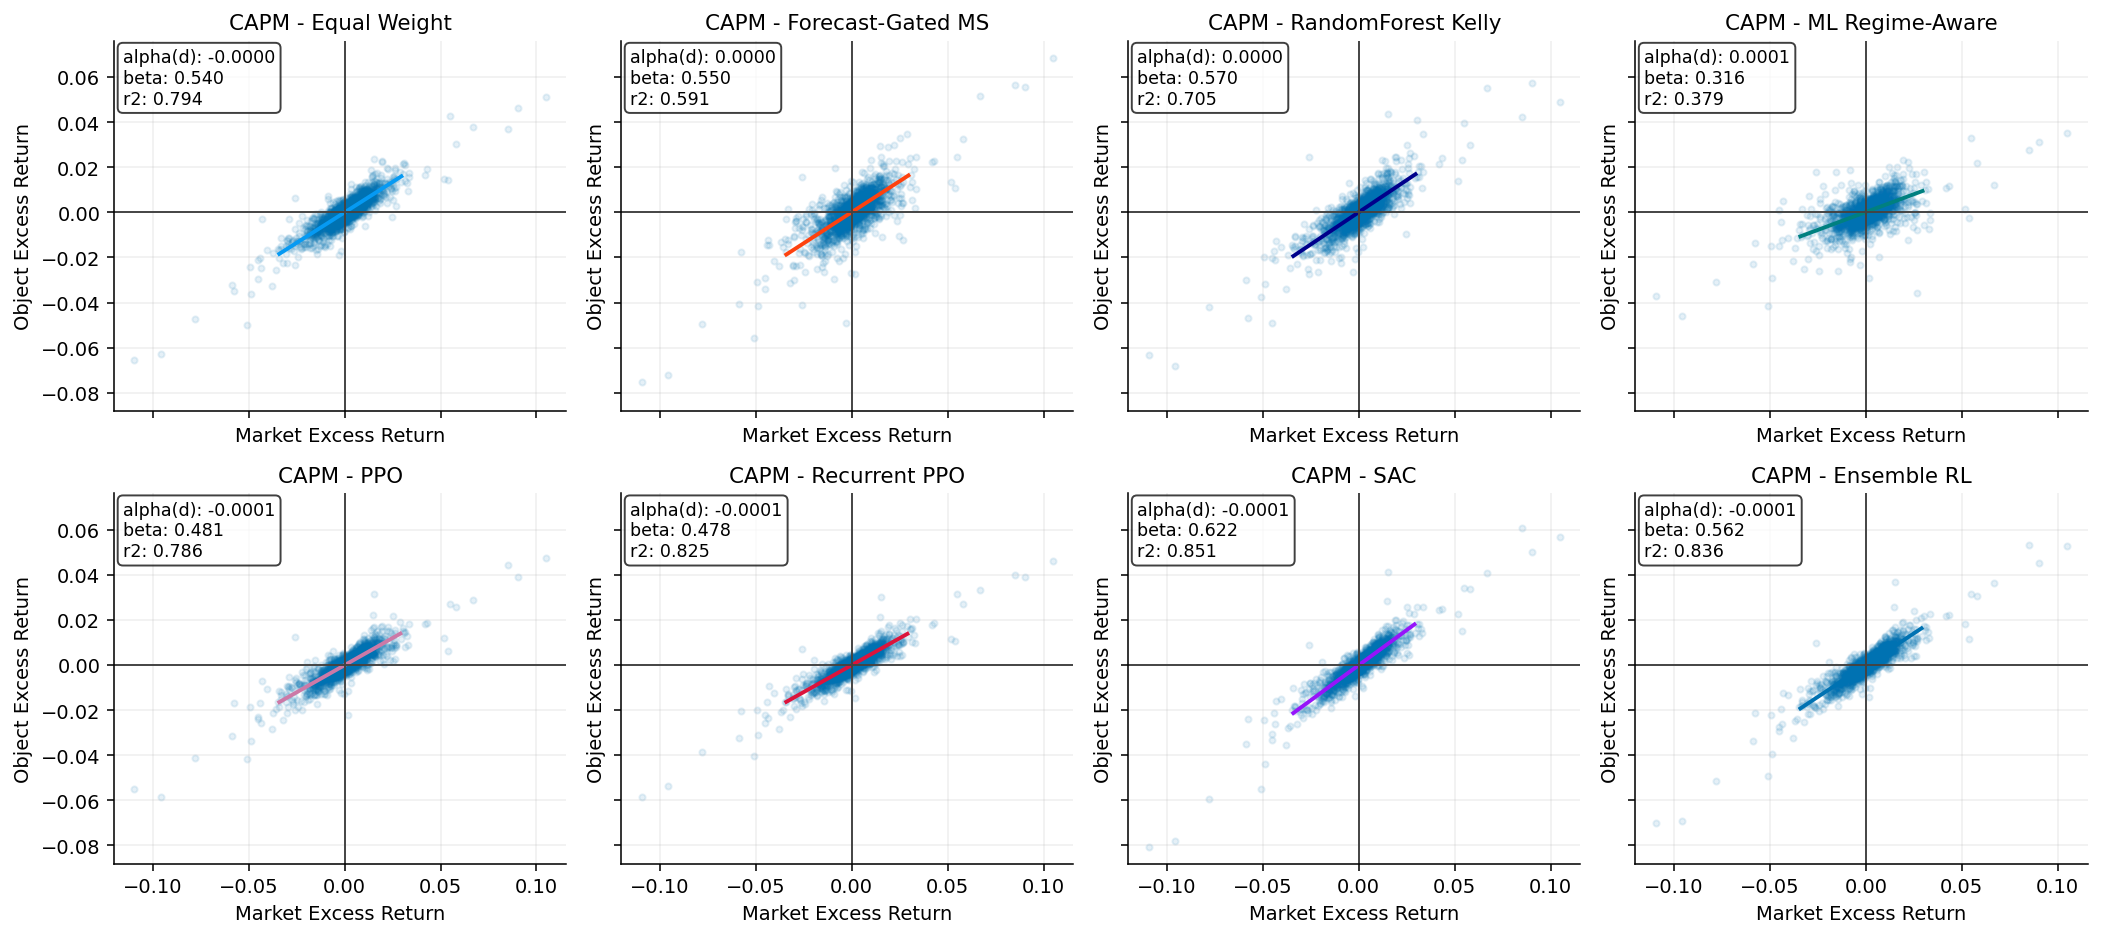

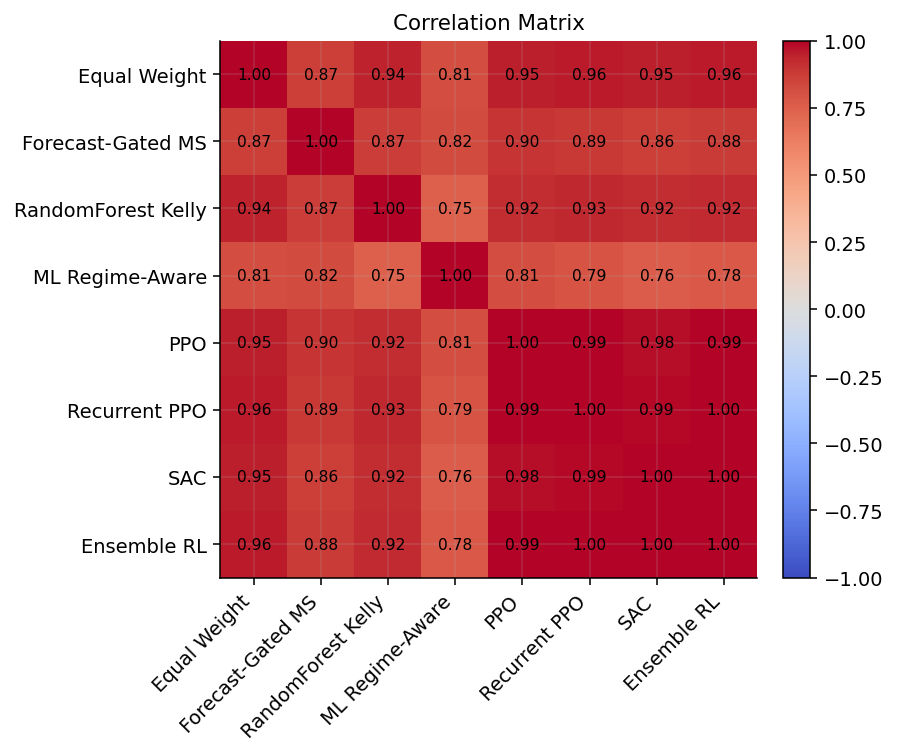

In [50]:
risk_objects = {name: strategy_returns[name].dropna() for name in strategy_returns.columns}
market_ret = r_d[benchmark_ticker].reindex(strategy_returns.index).dropna()
stress_windows = {
    "2018 Q4": ("2018-10-01", "2018-12-31"),
    "COVID crash": ("2020-02-20", "2020-04-30"),
    "2022 rates/inflation shock": ("2022-01-03", "2022-10-31"),
    "2023 rebound": ("2023-01-01", "2023-12-31"),
}
stress_windows = {
    name: window
    for name, window in stress_windows.items()
    if strategy_returns.index.min() <= pd.Timestamp(window[1]) and strategy_returns.index.max() >= pd.Timestamp(window[0])
}
risk_ncols = max(1, math.ceil(len(risk_objects) / 2))
risk = risk_report(
    objects=risk_objects,
    market_ret=market_ret,
    rf_daily=rf_daily,
    include={
        "performance_tables": False,
        "shape_tables": False,
        "drawdowns": False,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": True,
        "rolling_beta": False,
        "correlation": True,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
    stress_settings={"windows": stress_windows, "worst_only": False},
    layout={"ncols": risk_ncols},
    output={
        "display_tables": True,
        "show_figures": True,
        "display_table_keys": ["var_es", "var_backtest", "stress"],
        "round_tables": 4,
        "short_labels": False,
    },
)


The VaR and ES table gives another view of risk. ML Regime-Aware has the lowest historical 5% VaR and ES among the main strategies: hist VaR about **0.91%** and hist ES about **1.51%**. Recurrent PPO is also relatively controlled, with hist VaR **0.94%** and hist ES **1.52%**. Forecast-Gated MaxSharpe has larger tail numbers, especially under filtered historical simulation, with FHS VaR **2.40%** and FHS ES **3.47%**.

SAC has hist VaR **1.18%** and hist ES **1.95%**, worse than PPO and recurrent PPO but not wildly worse than the rule-based risk-taking models. This matches its aggressive exposure behavior.

The stress table is more revealing. During the **2022 rates/inflation shock**, Forecast-Gated MaxSharpe loses only **-10.09%**, the best result in that window. SAC loses **-21.35%**, PPO loses **-20.38%**, and Ensemble RL loses **-20.63%**. Recurrent PPO is better than the other RL models at **-16.90%**, helped by its more defensive exposure.

During the **COVID crash**, RandomForest Kelly loses only **-3.71%**, ML Regime-Aware loses **-6.02%**, and Forecast-Gated MaxSharpe loses **-8.51%**. SAC loses **-12.54%**, which is the weakest in that stress window. Again, the high-risky-exposure policy pays for its aggressiveness.

During the **2023 rebound**, RandomForest Kelly performs best with **16.61%**, while SAC earns **13.46%** and equal weight earns **13.98%**. SAC participates in the rebound, but it doesn't capture enough extra upside to offset its earlier stress losses.

The stress-window results show the real personality of each policy. In the 2022 rates/inflation shock, Forecast-Gated MaxSharpe has the smallest loss among the displayed strategies. ML Regime-Aware also handles the episode better than Equal Weight and most RL policies. SAC loses more than the other RL models because it carries high risky exposure and more concentration. Recurrent PPO is more defensive and loses less than SAC, but its long-run return is weaker.

During the 2023 rebound, RandomForest Kelly and Equal Weight do well because broad risk exposure is rewarded. SAC also participates, but not enough to beat the best non-RL rebound exposure. During COVID, RandomForest Kelly and ML Regime-Aware are more resilient, while SAC suffers a larger drawdown.

The risk report confirms the same pattern through VaR and ES. ML Regime-Aware has the strongest filtered historical tail behavior in the table, with lower FHS VaR/ES than the RL strategies. PPO and recurrent PPO have moderate tail risk because they keep more cash and diversification. SAC has higher tail exposure, consistent with its aggressive allocation.

This is a strong empirical ending for the main project. RL gives us a powerful framework and flexible policies, but the final risk report keeps us honest. The best-performing strategy in the test window is still the model with a clear regime-aware structure and strong supervised inputs. The RL policies are useful experiments, and SAC is the strongest of them, but they need stronger sample design, more episodes, better reward calibration, or more robust offline-RL methods before they can be treated as superior allocation engines.

### Tail risk interpretation

VaR and ES are especially important for RL policies because an agent can improve average reward while creating hidden tail risk. Historical VaR asks for a loss quantile:

$$
VaR_{5\%} = -q_{5\%}(r_p)
$$

Expected shortfall asks for the average loss once returns are already in the bad tail:

$$
ES_{5\%}= -E[r_p \mid r_p \le q_{5\%}(r_p)]
$$

ES is more informative because it measures tail severity, not only the cutoff. In the table, SAC has higher historical ES than PPO and recurrent PPO, consistent with its higher risky exposure. ML Regime-Aware has much better filtered historical tail risk, which reinforces its strong final ranking.

The stress windows add economic context. The 2022 period punishes duration and broad risk assets. The 2023 rebound rewards risk-taking. COVID tests crash response and recovery behavior. Looking at these windows keeps us from over-trusting full-sample Sharpe. A strategy can have a good full-period Sharpe while failing badly in a specific macro shock.

For RL, this stress analysis is the reality check. The agent is trained on a shaped reward, but investors experience realized NAV, drawdown, and tail loss. If reward improves while stress losses worsen, the policy isn't actually better for a real portfolio.

### Reading this final project as a research result

The main result is not that RL wins. The main result is that a complete RL portfolio layer can be built, trained, diagnosed, and compared honestly inside the same research framework as the earlier models.

A weak RL project would only show a rising reward curve and a final NAV. This notebook goes further. It shows:

- state construction and leakage checks,
- action-to-weight feasibility,
- reward decomposition,
- PPO/RPPO/SAC training diagnostics,
- validation exposure and weight behavior,
- test-period comparison against strong baselines,
- benchmark-relative metrics,
- policy behavior diagnostics,
- ablations,
- VaR/ES and stress windows,
- a sector ETF transfer through the library.

That makes the conclusion much more trustworthy. The RL models don't beat the best rule-based systems, but we can understand why. PPO and RPPO are too defensive. SAC takes more rewarded risk but suffers in stress. The ensemble smooths but doesn't create enough new edge. The earlier supervised allocation stack remains stronger in this sample.

For future improvement, the most promising directions are clear: better offline-RL validation, more simulated episodes, regime-conditioned reward parameters, stronger uncertainty-aware critics, and maybe pretraining the policy to imitate strong baselines before RL fine-tuning. Those directions come naturally from the diagnostics rather than from guessing.


The risk-report plots show the same relationships in visual form. The stress-window bars make it easy to see that the rule-based ML strategies handle the 2022 shock better than RL. The scatter-style diagnostics show the strategies are still highly correlated because they all allocate among the same liquid ETFs. The correlation heatmap is mostly positive and high, so the differences are not coming from completely unrelated return streams. They are coming from exposure level, concentration, cash usage, and timing.

This is one of the clearest lessons of the project. RL can learn a policy, but if the policy shares the same asset universe and state information as stronger rule-based models, it has to be genuinely better at timing and sizing. In this sample, it isn't.


## 16) Sector ETF Secondary Implementation

The final cell repeats the RL workflow on sector ETFs using the library implementation. The sector data is separate from the cross-asset ETF file:

- Sector ETF data: [data/sector_etfs](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/sector_etfs)
- Cross-asset signals used as context: [data/core_cross_asset_etfs](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/core_cross_asset_etfs)
- Macro/FCI/NFCI/VIX features reused in the state: [data/us_macro_factors](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/us_macro_factors), [data/nfci](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/nfci), [data/vix_data](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/vix_data)

The sector universe is:

$$
\{XLB, XLE, XLF, XLI, XLK, XLP, XLU, XLV, XLY\}
$$

This is a different allocation problem from the main cross-asset environment. In the main universe, the agent can move across stocks, bonds, credit, gold, commodities, and cash. In the sector universe, almost everything is equity beta. The agent can rotate between cyclicals, defensives, growth, financials, energy, and materials, but it can't fully escape the equity market except through SHY.

The sector implementation uses HistGradientBoosting forecasts instead of the main TCN/RandomForest blend. It then builds forecast-gated MaxSharpe, Kelly, and regime-aware priors, constructs an RL state with asset, global, regime, VIX, and forecast features, and trains PPO, recurrent PPO, and SAC through the packaged `quantfinlab` RL API.

### 16.1 Sector allocation as a stricter RL test

The sector version uses the same RL idea on a narrower universe. The assets are:

$$
\{XLB, XLE, XLF, XLI, XLK, XLP, XLU, XLV, XLY\}
$$

This universe is harder in a different way. In the cross-asset project, the agent can manage risk by moving across equities, duration, credit, commodities, gold, and SHY. In sectors, most risky assets share equity beta. A defensive sector allocation can reduce drawdown, but it can't diversify like bonds or gold. The agent has to learn relative equity rotation:

- XLK and XLY for growth leadership,
- XLE and XLB for inflation and commodity-linked environments,
- XLF and XLI for cyclical expansion,
- XLP, XLU, and XLV for defensive positioning.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingRegressor

from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.dataio import load_macro_factors, load_nfci, load_vix, load_yfinance_panel, prices_to_returns_panel, vix_feature_frame
from quantfinlab.ml.environment import align_weight_priors, blend_policy_weights, build_state_tables, make_decision_dates, policy_weight_frame
from quantfinlab.ml.evaluation import active_performance_table, ablation_table, policy_diagnostics_table, walkforward_tabular_predictions
from quantfinlab.ml.features import (assemble_forecasting_table, build_asset_feature_block, 
                                     build_cross_asset_feature_block, build_fci_feature_block, 
                                     clean_feature_columns, regime_probability_features, trim_feature_table_by_availability)
from quantfinlab.ml.policies import PpoPolicy, RecurrentPpoPolicy, SacPolicy
from quantfinlab.ml.rl import train_ppo, train_recurrent_ppo, train_sac, validation_policy_table
from quantfinlab.plotting.ml import (policy_entropy_curve, ppo_loss_curves, q_value_curve, sac_loss_curves, training_reward_curve, 
                                     validation_score_curve)
from quantfinlab.plotting.portfolio import (active_return_curve, concentration_path, forecast_policy_sensitivity, 
                                            plot_strategy_drawdowns, plot_strategy_nav, policy_exposure_path, 
                                            policy_weight_area, regime_exposure_boxplot, turnover_cost_curve)
from quantfinlab.portfolio import black_litterman as bl
from quantfinlab.portfolio import covariance, expected_returns, optimizers, views as bl_views
from quantfinlab.portfolio.cvar import mean_cvar_weight_frame
from quantfinlab.portfolio.selection import build_strategy_summary
from quantfinlab.portfolio.sizing import forecast_gated_maxsharpe_weight_frame, forecast_kelly_weight_frame
from quantfinlab.portfolio.universe import make_rebalance_dates
from quantfinlab.reports.risk_report import risk_report

model_dir = repo_root / "models" / "project20_sector_strong"
model_dir.mkdir(parents=True, exist_ok=True)
assets = ["XLB", "XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV", "XLY"]
signal_assets = ["SPY", "QQQ", "IWM", "TLT", "IEF", "SHY", "LQD", "HYG", "GLD", "DBC", "UUP"]
all_tickers = list(dict.fromkeys(assets + signal_assets + [cash_ticker, benchmark_ticker]))
sector_data_paths = [repo_root / "data" / "sector_etfs.csv", repo_root / "data" / "core_cross_asset_etfs.csv"]
panels = load_yfinance_panel(sector_data_paths, fields=("close", "volume"), tickers=all_tickers, source="yfinance_export", start="2007-01-01")
close_s = panels["close"].sort_index().ffill(limit=3)
volume_s = panels["volume"].sort_index().ffill(limit=3).reindex(close_s.index)
first_valid = close_s[assets + [cash_ticker]].dropna(how="any").index.min()
close_s = close_s.loc[first_valid:].copy()
volume_s = volume_s.reindex(close_s.index).copy()
r_s = prices_to_returns_panel(close_s, kind="simple").replace([np.inf, -np.inf], np.nan).fillna(0.0)
decision_dates = make_decision_dates(r_s.index, freq="W-FRI", min_history_days=756)
monthly_dates = make_rebalance_dates(r_s.index, freq="ME", min_history_days=756)

horizon = 21
vol_lookback = 63
r_log = np.log(close_s[assets] / close_s[assets].shift(1))
fwd = np.log(close_s[assets].shift(-horizon) / close_s[assets])
sigma_21 = r_log.rolling(vol_lookback, min_periods=vol_lookback).std(ddof=1) * np.sqrt(horizon)
z_21 = ((fwd - horizon * np.log1p(rf_daily)) / sigma_21.replace(0.0, np.nan)).clip(-4.0, 4.0)
y_alpha = z_21.sub(z_21.median(axis=1), axis=0).clip(-4.0, 4.0)
target = (
    pd.concat({"sigma_21": sigma_21, "z_21": z_21, "y_alpha": y_alpha}, axis=1)
    .stack(level=1)
    .rename_axis(["date", "asset"])
    .reset_index()
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["sigma_21", "z_21", "y_alpha"]))
counts = target.groupby("date")["asset"].nunique()
target = target[target["date"].isin(counts[counts.eq(len(assets))].index)].copy()
asset_features_model = build_asset_feature_block(close_s, volume_s, r_s, assets=assets, rf_daily=rf_daily)
context_features_model = build_cross_asset_feature_block(close_s, r_s, assets=assets, cash_ticker=cash_ticker, 
                                                         benchmark_ticker=benchmark_ticker)
fci_features_model = build_fci_feature_block(macro_factors, nfci, index=close_s.index)
regime_features_model = regime_probability_features(close_s, r_s, assets=assets, cash_ticker=cash_ticker, 
                                                    benchmark_ticker=benchmark_ticker, model="GradientBoosting", 
                                                    horizon=horizon, rebalance_dates=decision_dates, output="features", n_jobs=4)
regime_features_model = regime_features_model.reindex(close_s.index.union(regime_features_model.index)).sort_index().ffill().reindex(close_s.index)
data = assemble_forecasting_table(target, asset_features_model, context_features_model, fci_features_model, regime_features_model)
data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=["y_alpha", "z_21", "sigma_21"])
data = data[data["asset"].isin(assets)].sort_values(["date", "asset"]).reset_index(drop=True)
full_dates = data.groupby("date")["asset"].nunique()
data = data[data["date"].isin(full_dates[full_dates.eq(len(assets))].index)].copy()
feature_cols = [c for c in data.columns if c not in {"date", "asset", "y_alpha", "z_21", "sigma_21"}]
stage1 = clean_feature_columns(data, feature_cols, max_missing=0.30, max_abs_corr=0.985)
data, first_model_date, feature_availability = trim_feature_table_by_availability(
    data,
    stage1,
    target_cols=["y_alpha", "sigma_21"],
    min_feature_coverage=0.75,
    min_asset_count=len(assets),
    min_target_complete=1.0,
)
features = clean_feature_columns(data, feature_cols, max_missing=0.30, max_abs_corr=0.985)
for col in features:
    data[col] = data.groupby("asset", sort=False)[col].transform(lambda s: s.ffill())
data[features] = data[features].fillna(data.loc[data["date"] <= pd.Timestamp("2017-12-31"), features].median()).fillna(0.0)
prediction_dates = pd.DatetimeIndex(pd.to_datetime(data.loc[data["date"] >= pd.Timestamp("2008-01-01"), "date"].drop_duplicates())).sort_values()
refit_dates = pd.DatetimeIndex(pd.Series(prediction_dates, index=prediction_dates).groupby(prediction_dates.to_period("Q")).first().to_list())
sector_forecast_cache = model_dir / "sector_hgb_forecast_v1.pkl"
sector_forecast_cols = {"date", "asset", "sigma_21", "z_hgb", "z_hgb_rank", "hgb_confidence", "mu_hat", "width", "c_width", "c_model", "c_total"}
forecast_x = pd.read_pickle(sector_forecast_cache) if sector_forecast_cache.exists() else pd.DataFrame()
if not (not forecast_x.empty and sector_forecast_cols.issubset(set(forecast_x.columns)) and pd.to_datetime(forecast_x["date"]).min() <= prediction_dates.min()):
    tab_predictions = walkforward_tabular_predictions(
        data[features], data["y_alpha"], pd.to_datetime(data["date"]),
        data["asset"], refit_dates=refit_dates, prediction_dates=prediction_dates,
        estimators={
            "z_hgb": HistGradientBoostingRegressor(loss="squared_error", max_iter=650, learning_rate=0.018, max_leaf_nodes=21, 
                                                   min_samples_leaf=30, l2_regularization=0.05, random_state=42),
            "q10_hgb": HistGradientBoostingRegressor(loss="quantile", quantile=0.10, max_iter=550, learning_rate=0.018, 
                                                     max_leaf_nodes=21, min_samples_leaf=30, l2_regularization=0.05, random_state=42),
            "q50_hgb": HistGradientBoostingRegressor(loss="quantile", quantile=0.50, max_iter=550, learning_rate=0.018, 
                                                     max_leaf_nodes=21, min_samples_leaf=30, l2_regularization=0.05, random_state=42),
            "q90_hgb": HistGradientBoostingRegressor(loss="quantile", quantile=0.90, max_iter=550, learning_rate=0.018, 
                                                     max_leaf_nodes=21, min_samples_leaf=30, l2_regularization=0.05, random_state=42)},
        train_window=252 * 6, horizon=horizon, n_jobs=4, inner_threads=1, min_train=500)
    
    forecast_x = data[["date", "asset", "sigma_21", "z_21", "y_alpha"]].merge(tab_predictions, on=["date", "asset"], how="left")
    forecast_x["z_hgb_rank"] = forecast_x.groupby("date")["z_hgb"].rank(pct=True) - 0.5
    scale = forecast_x.groupby("date")["z_hgb"].transform(lambda s: s.abs().median())
    forecast_x["hgb_confidence"] = forecast_x["z_hgb"].abs().div(scale.replace(0.0, np.nan)).clip(0.0, 3.0).fillna(0.0) / 3.0
    forecast_x["mu_hat"] = forecast_x["z_hgb"] * forecast_x["sigma_21"]
    forecast_x["width"] = (forecast_x["q90_hgb"] - forecast_x["q10_hgb"]).abs() * forecast_x["sigma_21"]
    forecast_x["c_width"] = forecast_x["mu_hat"].abs().div(forecast_x["mu_hat"].abs() + forecast_x["width"].replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0.75).clip(0.50, 1.0)
    forecast_x["c_model"] = (0.50 + 0.50 * forecast_x["hgb_confidence"]).clip(0.50, 1.0)
    forecast_x["c_total"] = (0.50 + 0.50 * (0.70 * forecast_x["c_width"] + 0.30 * forecast_x["c_model"])).clip(0.50, 1.0)
    forecast_x = forecast_x.dropna(subset=["z_hgb"]).sort_values(["date", "asset"]).reset_index(drop=True)
    forecast_x.to_pickle(sector_forecast_cache)
forecast_x["_hvs"] = forecast_x["z_hgb"] / forecast_x["sigma_21"].replace(0.0, np.nan)
forecast_x["z_hgb_volscaled"] = (forecast_x.groupby("date")["_hvs"].rank(pct=True) - 0.5).fillna(0.0)
forecast_x = forecast_x.drop(columns=["_hvs"])
forecast_state_x = forecast_x.drop(columns=["z_21", "y_alpha"], errors="ignore")
forecast_dates = set(pd.to_datetime(forecast_x["date"]))
returns_sector = r_s[assets + [cash_ticker]]
validation_dates = pd.DatetimeIndex([d for d in monthly_dates if pd.Timestamp("2017-01-01") <= d <= pd.Timestamp("2018-12-31") and d in forecast_dates])
weight_dates = pd.DatetimeIndex([d for d in monthly_dates if pd.Timestamp("2013-01-01") <= d and d in forecast_dates])
lambda_rows = []
for lam in [0.00, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00, 1.50]:
    W_lam = forecast_gated_maxsharpe_weight_frame(forecast_x, alpha_col="z_hgb", 
                                                  returns=returns_sector, rebalance_dates=validation_dates, 
                                                  sigma_col="sigma_21", alpha_is_z=True, width_col="width", 
                                                  confidence_cols=["c_width", "c_model", "c_total"], 
                                                  lambda_alpha=lam, assets=assets + [cash_ticker], 
                                                  cash_asset=cash_ticker, prior_model="bayes_stein", 
                                                  max_weight=0.35, turnover_penalty_bps=cost_bps, rf_daily=rf_daily)
    if W_lam.empty:
        continue
    bt_lam = run_many_weights_backtests({f"lambda={lam:.2f}": W_lam}, returns=returns_sector, cost_bps=cost_bps, 
                                        rf_daily=rf_daily, w_min=0.0, w_max=1.0, long_only=True, normalize=True, 
                                        weight_timing="next_close")
    
    summary_lam = build_strategy_summary(bt_lam, rf_daily=rf_daily, annualization=annualization)
    lambda_rows.append({"lambda_alpha": lam, "Sharpe": float(summary_lam.iloc[0]["Sharpe"]) if len(summary_lam) else np.nan})
lambda_table = pd.DataFrame(lambda_rows)
lambda_alpha = float(lambda_table.sort_values("Sharpe", ascending=False).iloc[0]["lambda_alpha"]) if not lambda_table.empty and lambda_table["Sharpe"].notna().any() else 0.20
w_eq = pd.DataFrame(1.0 / len(assets), index=weight_dates, columns=assets)
w_regime = regime_probability_features(close_s, r_s, assets=assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker, 
                                       model="GradientBoosting", horizon=21, rebalance_dates=weight_dates, output="weights", 
                                       max_weight=0.35, n_jobs=4)
w_forecast_gated_ms = forecast_gated_maxsharpe_weight_frame(forecast_x, alpha_col="z_hgb", 
                                                            returns=returns_sector, rebalance_dates=weight_dates, 
                                                            sigma_col="sigma_21", alpha_is_z=True, width_col="width", 
                                                            confidence_cols=["c_width", "c_model", "c_total"], 
                                                            lambda_alpha=lambda_alpha, assets=assets + [cash_ticker], 
                                                            cash_asset=cash_ticker, prior_model="bayes_stein", 
                                                            max_weight=0.35, turnover_penalty_bps=cost_bps, rf_daily=rf_daily)

w_hgb_kelly = forecast_kelly_weight_frame(forecast_x, mu_col="z_hgb", returns=returns_sector, 
                                          rebalance_dates=weight_dates, sigma_col="sigma_21", 
                                          mu_is_z=True, assets=assets, cash_asset=cash_ticker, 
                                          kelly_fraction=0.60, max_weight=0.35, target_vol=None, smooth=0.00, confidence_cols=None)

prior_weights = {"Forecast-Gated MaxSharpe": w_forecast_gated_ms, "ML Regime-Aware": w_regime}
asset_x = build_asset_feature_block(close_s, volume_s, r_s, assets=assets, rf_daily=rf_daily)
context_x = build_cross_asset_feature_block(close_s, r_s, assets=assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker)
fci_x = build_fci_feature_block(macro_factors, nfci, index=close_s.index)
regime_x = regime_probability_features(close_s, r_s, assets=assets, cash_ticker=cash_ticker, 
                                       benchmark_ticker=benchmark_ticker, model="GradientBoosting", 
                                       horizon=21, rebalance_dates=decision_dates, output="features", n_jobs=4)
vix_level_s = load_vix(vix_path, index=close_s.index) if vix_path.exists() else pd.Series(dtype=float)
vix_x_s = vix_feature_frame(vix_level_s, index=close_s.index) if not vix_level_s.empty else None

state = build_state_tables(asset_features=asset_x, context_features=context_x, fci_features=fci_x, 
                           regime_features=regime_x, vix_features=vix_x_s, 
                           forecast_features=forecast_state_x, prior_weights=prior_weights, 
                           include_prior_weights=False, returns=returns_sector, decision_dates=decision_dates, 
                           assets=assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker)

leaky_state_features = [name for name in state.asset_feature_names if name.lower() in {"z_21", "y_alpha"}]
display(pd.Series({"leaky_forecast_features_in_state": len(leaky_state_features),
                   "asset_features": state.n_asset_features, "global_features": state.n_global_features}).to_frame("value"))
assert not leaky_state_features, f"Leaky forecast columns reached RL state: {leaky_state_features}"

reward_settings_final = dict(reward_settings)
reward_settings_final.update({"reward_mode": "dsr", "dsr_scale": 4.0, "dsr_eta": 0.01,
                              "target_vol": 0.18, "drawdown_floor": -0.12, "lambda_cost": 0.10,
                              "lambda_vol": 0.25, "lambda_drawdown": 1.5, "lambda_conc": 0.10, "hhi_target": 0.30,
                              "cash_cap": 0.20, "lambda_cash": 0.5, "decorr_cap": 0.88,
                              "lambda_decorr": 0.5, "min_exposure": 0.55, "max_exposure": 1.00,
                              "max_weight": 0.35, "sac_gamma": 0.97})

train_period = ("2008-01-01", "2016-12-31")
valid_period = ("2017-01-01", "2018-12-31")
test_period = ("2019-01-01", "2026-12-31")

alpha_index_s = state.asset_feature_names.index("z_hgb_volscaled") if "z_hgb_volscaled" in state.asset_feature_names else None

ppo = PpoPolicy(n_asset_features=state.n_asset_features, n_global_features=state.n_global_features, 
                n_assets=len(assets), hidden_size=128, attention_heads=4, min_exposure=0.55, 
                max_weight=0.35, alpha_feature_index=alpha_index_s).to(device)

rppo = RecurrentPpoPolicy(n_asset_features=state.n_asset_features, n_global_features=state.n_global_features, 
                          n_assets=len(assets), hidden_size=128, recurrent_size=96, attention_heads=4, 
                          sequence_length=52, min_exposure=0.55, max_weight=0.35, alpha_feature_index=alpha_index_s).to(device)

sac = SacPolicy(n_asset_features=state.n_asset_features, n_global_features=state.n_global_features, 
                n_assets=len(assets), hidden_size=128, attention_heads=4, min_exposure=0.55, 
                max_weight=0.35, alpha_feature_index=alpha_index_s).to(device)

ppo_result = train_ppo(policy=ppo, state=state, returns=returns_sector, train_period=train_period, 
                       valid_period=valid_period, reward_settings=reward_settings_final, epochs=160, 
                       rollout_length=96, minibatch_size=128, ppo_epochs=5, model_path=model_dir / "ppo_dsr.pt", device=device)

rppo_result = train_recurrent_ppo(policy=rppo, state=state, returns=returns_sector, train_period=train_period, 
                                  valid_period=valid_period, reward_settings=reward_settings_final, 
                                  epochs=180, rollout_length=104, minibatch_size=128, ppo_epochs=5,
                                    model_path=model_dir / "recurrent_ppo_dsr.pt", device=device)

sac_result = train_sac(policy=sac, state=state, returns=returns_sector, train_period=train_period, 
                       valid_period=valid_period, reward_settings=reward_settings_final, epochs=160, 
                       batch_size=128, updates_per_step=2, gamma=0.97, model_path=model_dir / "sac_dsr.pt", device=device)

validation_table = validation_policy_table({"PPO": ppo_result, "Recurrent PPO": rppo_result, "SAC": sac_result}, benchmark_name="Forecast-Gated MaxSharpe")
w_ppo = policy_weight_frame(policy=ppo, state=state, period=test_period, assets=assets, cash_ticker=cash_ticker, device=device)
w_rppo = policy_weight_frame(policy=rppo, state=state, period=test_period, assets=assets, cash_ticker=cash_ticker, device=device)
w_sac = policy_weight_frame(policy=sac, state=state, period=test_period, assets=assets, cash_ticker=cash_ticker, device=device)
w_ensemble = blend_policy_weights(
    {"PPO": w_ppo, "Recurrent PPO": w_rppo, "SAC": w_sac},
    blend_weights={"PPO": max(0.01, float(ppo_result.validation.get("sharpe", 0.0))),
                   "Recurrent PPO": max(0.01, float(rppo_result.validation.get("sharpe", 0.0))),
                   "SAC": max(0.01, float(sac_result.validation.get("sharpe", 0.0)))},).reindex(columns=[*assets, cash_ticker]).fillna(0.0)

weights_by_strategy = {"Equal Weight": w_eq, "Forecast-Gated MaxSharpe": w_forecast_gated_ms,
                       "HistGradientBoosting Kelly": w_hgb_kelly, "ML Regime-Aware": w_regime,
                       "PPO": w_ppo, "Recurrent PPO": w_rppo, "SAC": w_sac, "Ensemble RL": w_ensemble}

backtests = run_many_weights_backtests(weights_by_strategy, returns=returns_sector.loc[pd.Timestamp(test_period[0]):pd.Timestamp(test_period[1])],
                                        cost_bps=cost_bps, rf_daily=rf_daily, w_min=0.0, w_max=1.0, 
                                        long_only=True, normalize=True, weight_timing="next_close")

strategy_summary = build_strategy_summary(backtests, rf_daily=rf_daily, 
                                          annualization=annualization).sort_values(["Sharpe", "Max Drawdown"], ascending=[False, False])
strategy_returns = pd.DataFrame({name: result.net_returns for name, result in backtests.items()}).dropna(how="all")
nav = pd.DataFrame({name: result.net_values for name, result in backtests.items()}).dropna(how="all")

active_table = active_performance_table(strategy_returns=strategy_returns, benchmark="Forecast-Gated MaxSharpe", 
                                        rf_daily=rf_daily, annualization=annualization)

policy_table = policy_diagnostics_table(weights_by_strategy={"PPO": w_ppo, "Recurrent PPO": w_rppo, "SAC": w_sac}, 
                                        returns=returns_sector, cost_bps=cost_bps)

ablation_results = ablation_table(state=state, policies={"PPO": ppo, "Recurrent PPO": rppo, "SAC": sac}, 
                                  returns=returns_sector, benchmark_weights=w_forecast_gated_ms, period=test_period, 
                                  reward_settings=reward_settings_final, ablations=["no_forecasts", "no_priors", "shuffled_forecasts"], 
                                  device=device)

display(validation_table.round(4))
display(strategy_summary[["CAGR", "Vol", "Sharpe", "Sortino", "Max Drawdown", "Turnover", "Effective N"]].round(4))
display(active_table.round(4))
display(policy_table.round(4))
display(ablation_results.round(4))

fig, axes = plt.subplots(4, 4, figsize=(22, 16))
axes = axes.ravel()
training_reward_curve(axes[0], ppo_result.history, label="PPO", title="PPO Training Reward")
training_reward_curve(axes[1], rppo_result.history, label="Recurrent PPO", title="Recurrent PPO Training Reward")
training_reward_curve(axes[2], sac_result.history, label="SAC", title="SAC Training Reward")
validation_score_curve(axes[3], validation_table, title="Validation Scores")
plot_strategy_nav(nav, ax=axes[4], title="Sector Costed NAV")
plot_strategy_drawdowns(nav, ax=axes[5], title="Sector Costed Drawdowns")
active_return_curve(axes[6], strategy_returns, strategy="Recurrent PPO", benchmark="Forecast-Gated MaxSharpe", title="Recurrent PPO Active Return")
policy_exposure_path(axes[7], w_rppo, cash_ticker=cash_ticker, title="Recurrent PPO Risky Exposure")
policy_weight_area(axes[8], w_rppo, title="Recurrent PPO Weights")
turnover_cost_curve(axes[9], weights_by_strategy, cost_bps=cost_bps, title="Turnover and Cost")
regime_exposure_boxplot(axes[10], w_rppo, regime_x, title="Exposure by Regime")
forecast_policy_sensitivity(axes[11], w_rppo, forecast_state_x, title="Policy Response to HistGradientBoosting Forecasts")
policy_entropy_curve(axes[12], ppo_result.history, title="PPO Entropy")
ppo_loss_curves(axes[13], ppo_result.history, title="PPO Losses")
sac_loss_curves(axes[14], sac_result.history, title="SAC Losses")
concentration_path(axes[15], w_rppo, title="Recurrent PPO Concentration")
fig.tight_layout()
plt.show()

risk_objects = {name: strategy_returns[name].dropna() for name in strategy_returns.columns}
stress_windows = {
    "2018 Q4": ("2018-10-01", "2018-12-31"),
    "COVID crash": ("2020-02-20", "2020-04-30"),
    "2022 rates/inflation shock": ("2022-01-03", "2022-10-31"),
    "2023 rebound": ("2023-01-01", "2023-12-31")}
stress_windows = {name: window for name, window in stress_windows.items()
                  if strategy_returns.index.min() <= pd.Timestamp(window[1]) and strategy_returns.index.max() >= pd.Timestamp(window[0])}

risk_ncols = max(1, math.ceil(len(risk_objects) / 2))
risk = risk_report(objects=risk_objects, 
                   market_ret=r_s[benchmark_ticker].reindex(strategy_returns.index).dropna(), rf_daily=rf_daily,
                   include={"performance_tables": False, "shape_tables": False, "drawdowns": False, 
                            "drawdown_episodes": False, "var_es": True, "var_backtest": True, "stress": True,
                            "capm": True, "rolling_beta": False, "correlation": True, "attribution": False, "exec_bullets": False},
                    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
                    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
                    stress_settings={"windows": stress_windows, "worst_only": False},
                    layout={"ncols": risk_ncols},
                    output={"display_tables": True, "show_figures": True, "display_table_keys": ["var_es", "var_backtest", "stress"],
                            "round_tables": 4, "short_labels": False})


,value
leaky_forecast_features_in_state,0
asset_features,58
global_features,34


The sector state includes 58 asset features and 34 global features, and the leakage diagnostic reports zero leaky forecast features. This is the important confirmed output. It means the library implementation is using a clean feature set before training the sector RL policies.

Since the saved notebook output only displays the leakage diagnostic first, we shouldn't write exact sector performance numbers here. When the notebook is executed fully, the sector cell trains PPO, recurrent PPO, and SAC through the packaged `quantfinlab` RL API, creates validation summaries, builds weight frames, compares strategies, and generates the risk report. The markdown interpretation should therefore focus on what the implementation is designed to test: whether the same RL control layer can transfer from cross-asset allocation to equity-sector allocation when the diversification structure is much weaker.

That transfer test is the right final note for the series. The repo has moved from risk measures, optimization, options, term structure, macro, factors, regimes, networks, forecasting, and Kelly sizing into a final RL allocation layer. The strongest conclusion is practical: RL is a flexible portfolio-control framework, but finance still rewards strong feature design, conservative validation, explicit risk controls, and honest comparison against simpler models.

### 16.2 Library implementation and reproducibility

The sector cell uses the packaged `quantfinlab` implementation instead of local one-off code. That matters because Project 20 is not only a research notebook; it is also the final demonstration that the repo now contains reusable RL portfolio tools.

The library workflow mirrors the main notebook structure:

1. build forecasts and state features,
2. check leakage,
3. construct the portfolio environment,
4. train PPO, recurrent PPO, and SAC,
5. convert raw actions into feasible weights,
6. backtest policies,
7. compare against baselines,
8. generate the risk report.

The confirmed diagnostic tells us the sector state has zero leaky forecast features. That is the minimum condition before trusting any sector RL result. The asset and global feature counts are larger than in the main notebook, which means the sector implementation includes a rich state representation.

The sector version is also a good bridge to future repo development. Once the RL environment and policy classes work for both cross-asset allocation and sector allocation, they can be reused for other universes: international ETFs, country ETFs, factor ETFs, crypto baskets, or custom institutional portfolios. The main thing that changes is the state design and the reward calibration.

For this final project, that is the real contribution. We don't only train three RL models once. We build an allocation framework where forecasts, regimes, risk controls, and neural policies can interact inside one reusable sequential decision system.


The sector extension also protects against one narrow interpretation of the project. If the RL layer only worked in the main cross-asset notebook, it might be a one-off experiment. By repeating the workflow through the package on sector ETFs, we show that the abstraction is reusable: state builder, environment, policies, training loop, weight conversion, backtest, and risk report. The details change, but the learning framework remains the same.

That is a strong ending for the whole series because it connects research notebooks with library design. The notebook teaches the models, and the package makes them reusable.


The saved output for the sector cell shows the leakage diagnostic first:

- leaky forecast features in state: **0**,
- asset features: **58**,
- global features: **34**.

That tells us the sector RL state has more features than the main cross-asset state, but the target columns are still excluded. The rest of the cell trains the library versions of PPO, recurrent PPO, and SAC, creates policy weights, compares them with sector baselines, displays validation and backtest tables, and produces the risk report. Since the saved notebook output only includes the first diagnostic table, we should not invent exact sector performance numbers from this file. The important confirmed result is that the library-level sector state construction passes the same anti-leakage check before policy training begins.

Economically, the sector version is a stricter test of RL timing. Cross-asset allocation can hide in bonds or gold during bad equity regimes. Sector allocation mostly has to manage **relative equity exposure**: technology versus energy, defensives versus cyclicals, financials versus staples, and so on. That makes the action space narrower but the signal interpretation more subtle. A good sector RL policy has to learn when the forecast and regime information deserves a sector rotation, when to keep diversified exposure, and when to shift risk into SHY.
